In [54]:
#rename file
import os
import glob
from astropy.io import fits
import numpy as np
from astropy.visualization import simple_norm
import matplotlib.pyplot as plt
from scipy.optimize import leastsq
from scipy.optimize import fsolve
from scipy.optimize import minimize
import os
import re
from astropy.table import Table
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from photutils.aperture import SkyCircularAperture, SkyCircularAnnulus
from photutils.aperture import aperture_photometry
from photutils.centroids import centroid_com
from astropy.stats import sigma_clipped_stats
from astropy.visualization import simple_norm
from scipy.optimize import curve_fit
from scipy.stats import linregress
import extinction
from astropy import units as u, constants as const
from astropy.cosmology import Planck18 as cosmo

plt.style.use('/Users/zijianzhang/Astro_Data/paper.mplstyle')

Duplicate key in file '/Users/zijianzhang/Astro_Data/paper.mplstyle', line 23 ('axes.linewidth : 1.5')


In [55]:
# tab_hst_phot = Table.read('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/code/hst_full.fits')
# tab_hst_upplim = Table.read('/Users/zijianzhang/Astro_Data/RXJ2211/code/hst_upper_limit.fits')
# tab_hst_jwst_combined = Table.read('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/catalog/venus_slice_hst_combine_lenslrd_sfw.fits')
tab_hst_jwst_combined = Table.read('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/catalog/venus_slice_hst_combine_lenslrd_phot.fits')
# tab_hst_jwst_combined = tab_hst_phot

def read_lens_data(filename):
    """
    读取 lensing 参数文件并解析为字典。
    每个系统像 (如 4.1, 16.2) 的数据结构：
        {'x': (value, +err, -err), 'y': (...), 'mu': (...), 'dt': (...)}
    """
    data = {}

    pattern = re.compile(
        r'(?P<param>[xy]|mu|dt)\((?P<id>[\d\.]+)\).*?([ \t]+)?(?P<value>[-\d\.]+)\^\{\+(?P<errp>[\d\.]+)\}_\{\-(?P<errm>[\d\.]+)\}'
    )

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            m = pattern.search(line)
            if m:
                param = m.group('param')
                if param == 'dt':  # 处理 dt(4.1)[day] 这种情况
                    param = 'dt'
                img_id = m.group('id')
                val = float(m.group('value'))
                errp = float(m.group('errp'))
                errm = float(m.group('errm'))

                if img_id not in data:
                    data[img_id] = {}
                data[img_id][param] = (val, errp, errm)
    return data

lens_data_file = '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/Oguri_model/rj2211_glafic_v0p9_summary_mu_td_lrds.dat'
lens_dict = read_lens_data(lens_data_file)


In [71]:
lens_dict 

{'9.1': {'x': (-44.83, 0.21, 0.21),
  'y': (-10.58, 0.17, 0.18),
  'mu': (3.68, 0.14, 0.16),
  'dt': (30055.27, 618.64, 687.48)},
 '9.2': {'x': (60.48, 0.26, 0.24),
  'y': (4.79, 0.19, 0.19),
  'mu': (2.23, 0.07, 0.08),
  'dt': (0.0, 0.0, 0.0)},
 '9.3': {'x': (2.62, 0.15, 0.15),
  'y': (-42.11, 0.23, 0.24),
  'mu': (-2.16, 0.09, 0.1),
  'dt': (43649.07, 909.92, 956.74)},
 '9.4': {'x': (-10.67, 0.17, 0.19),
  'y': (35.19, 0.23, 0.23),
  'mu': (-2.97, 0.13, 0.14),
  'dt': (47910.71, 970.12, 982.15)},
 '10.1': {'x': (2.91, 0.11, 0.1),
  'y': (-21.4, 0.19, 0.22),
  'mu': (-1.15, 0.05, 0.06),
  'dt': (57876.39, 1079.28, 1008.6)},
 '10.2': {'x': (1.53, 0.16, 0.15),
  'y': (-11.34, 0.28, 0.27),
  'mu': (1.02, 0.07, 0.07),
  'dt': (58332.43, 1079.98, 1020.51)},
 '10.3': {'x': (-48.36, 0.25, 0.23),
  'y': (22.74, 0.32, 0.25),
  'mu': (3.38, 0.17, 0.14),
  'dt': (8123.6, 382.7, 416.36)},
 '10.4': {'x': (49.89, 0.23, 0.25),
  'y': (32.11, 0.3, 0.26),
  'mu': (3.34, 0.14, 0.13),
  'dt': (0.0, 0.0,

In [56]:
bands = ['F125W', 'F140W', 'F105W', 'F606W', 'F435W', 'F814W', 'F160W']
for band in bands:
    band = band.lower()
    new_sigma = tab_hst_jwst_combined[f'{band}_fluxnJy'] / tab_hst_jwst_combined[f'{band}_fluxerr_njy']
    tab_hst_jwst_combined[f'{band}_sig_new'] = new_sigma

# tab_hst_jwst_combined.rename_column('ID_1_1', 'ID_2')
tab_hst_jwst_combined['ID_2'] = tab_hst_jwst_combined['ID_2'].astype(str)

1.1
[111.03610558 262.45940923  15.38380635   7.5194915    9.34110591
  22.79487442  25.47901961 113.37321911 215.67254709 243.67572493] nJy
1.2
[ 62.86110346 162.240261     9.95210846   7.35226239   8.20618357
  18.73047286  19.99563711  59.0443251  135.82379382 147.17491534] nJy
1.3
[ 87.65212723 214.76260945  15.38216633   8.10928542   9.09111524
  20.63872901  24.90230497  86.7469226  173.66032311 193.71065916] nJy
1.4
[ 95.07888251 242.50753453  13.6280427    5.52556734  11.947862
  21.98295749  26.83380659  95.10891638 190.88066608 208.98553074] nJy


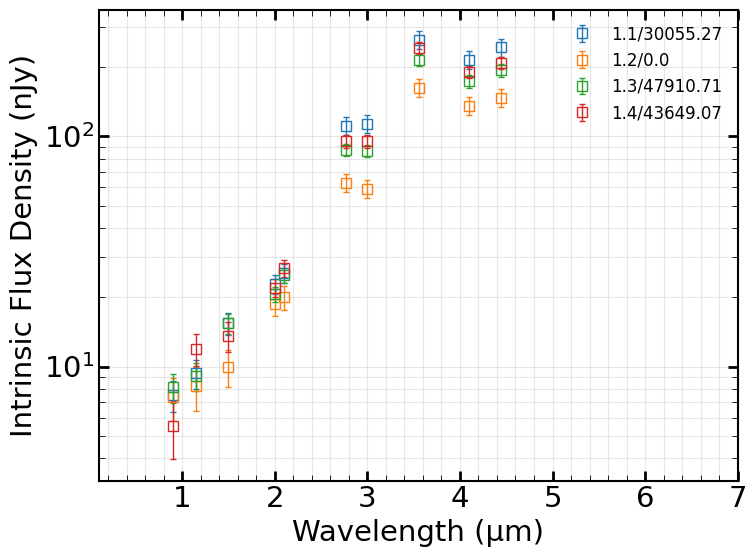

In [57]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

mask = np.array(['.' in i for i in tab_hst_jwst_combined['ID_2']])
sel_tab = tab_hst_jwst_combined[mask]

# 筛选 system-1
mask = np.array(['1.' in i for i in tab_hst_jwst_combined['ID_2']])
sel_tab = tab_hst_jwst_combined[mask]

hstbands = ['F435W', 'F606W', 'F814W']
# wave_hst = np.array([1.25, 1.4, 1.05, 0.606, 0.435, 0.814, 1.60])  # micron
wave_hst = np.array([ 0.435, 0.606, 0.814]) * u.um  # micron
jwstbands = [ 'F277W',  'F356W', 'F150W','F090W', 'F115W',  'F200W', 'F210M', 'F300M', 'F410M', 'F444W']
wave_jwst = np.array([ 2.77,  3.56, 1.50, 0.9, 1.15,  2.00, 2.10,3.00,4.10, 4.44]) * u.um
# jwstbands = ['F090W', 'F115W', 'F150W', 'F200W', 'F210M', 'F277W', 'F300M', 'F356W',  'F410M', 'F444W']
# wave_jwst = np.array([0.9, 1.15, 1.50, 2.00, 2.10,  2.77, 3.00, 3.56,  4.10, 4.44]) * u.um
# jwstbands = [ 'F200W', 'F210M', 'F277W',  'F300M', 'F356W','F410M', 'F444W']
# wave_jwst = np.array([ 2.00, 2.10,  2.77, 3.00, 3.56, 4.10, 4.44]) * u.um
# jwstbands = [ 'F200W', 'F210M',  'F300M', 'F410M', 'F444W']
# wave_jwst = np.array([ 2.00, 2.10,  3.00,  4.10, 4.44]) * u.um
# jwstbands = [ 'F200W', 'F210M',  'F300M', 'F410M', 'F444W']
# wave_jwst = np.array([ 2.00, 2.10,  3.00,  4.10, 4.44]) * u.um

magkey_hst = [band.lower() + '_mag' for band in hstbands] 
magerr_key_hst = [band.lower() + '_magerr_2' for band in hstbands] 
# magkey_jwst = ['MAG_KRON_' + band.upper()  for band in jwstbands] 
# magerr_key_jwst = ['MAGERR_KRON_' + band.upper()  for band in jwstbands] 
# fluxkey_jwst = ['f_' + band.upper()  for band in jwstbands] 
# fluxerr_key_jwst = ['e_' + band.upper()  for band in jwstbands] 
fluxkey_jwst = [band.upper() + '_CIRC1'   for band in jwstbands] 
fluxerr_key_jwst = [ band.upper() + '_CIRC1_en' for band in jwstbands] 
sigkey_hst = [band.lower() + '_sig_new' for band in hstbands] 


color_cycle = cycle(plt.cm.tab10.colors)  # 给不同像用不同颜色
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# AB mag 转 nJy
def mag_to_njy(mag):
    return 10**((31.4 - mag) / 2.5)
def njy_to_mag(flux):
    return 31.4 - 2.5 * np.log10(flux)
    

color_cycle = cycle(plt.cm.tab10.colors)

plotted_labels = set()  # 避免重复 legend
plt.figure(figsize=(8, 6))
color_cycle = cycle(plt.cm.tab10.colors)
plotted_labels = set()

ax = plt.gca()

jwstflux_list = []
jwstmag_list = []
jwstfluxerr_list = []
jwstmagerr_list = []
for col in sel_tab:
    name = col['ID_2']
    color = next(color_cycle)

    img_idx = int(name.split('.')[1])
    if(img_idx == 3):
        img_idx = 4
    elif(img_idx == 4):
        img_idx = 3
    # mu = systems_data["system-1 (z=6.07)"]["images"][img_idx]["mu"]
    # mu_err = mu_errs[img_idx]  # 放大率误差
    # td = systems_data["system-1 (z=6.07)"]["images"][img_idx]["tdelay"]

    mu = lens_dict[f'9.{img_idx}']["mu"][0]
    mu_err = np.max([np.abs(lens_dict[f'9.{img_idx}']["mu"][2]), np.abs(lens_dict[f'9.{img_idx}']["mu"][1])])
    mu_err = np.max([0.08*mu, mu_err])
    mu_abs = np.abs(mu)
    td = lens_dict[f'9.{img_idx}']["dt"][0]

    hst_mag      = np.array([col[k] for k in magkey_hst], dtype=float)
    hst_mag_err  = np.array([col[k] for k in magerr_key_hst], dtype=float)
    hst_sig      = np.array([col[k] for k in sigkey_hst], dtype=float)
    # jwst_mag     = np.array([systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F150W2'], systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F322W2']])#np.array([col[k] for k in magkey_jwst], dtype=float)
    # jwst_mag_err = np.array([systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F150W2_err'], systems_data["system-1 (z=6.07)"]["images"][img_idx]['mag_F322W2_err']])#np.array([col[k] for k in magerr_key_jwst], dtype=float)
    # jwst_mag      = np.array([col[k] for k in magkey_jwst], dtype=float)
    # jwst_mag_err  = np.array([col[k] for k in magerr_key_jwst], dtype=float)
    jwst_flux      = np.array([col[k] for k in fluxkey_jwst], dtype=float) / mu_abs * u.nJy
    jwst_flux_err  = np.array([col[k] for k in fluxerr_key_jwst], dtype=float) / mu_abs * u.nJy

    
    hst_mag_corr = hst_mag + 2.5 * np.log10(mu_abs)
    
    
    # jwst_flux_corr = jwst_flux 
    # jwst_flux_err = jwst_flux_err

    jwst_flux_corr = jwst_flux#.to(u.erg / u.s / u.cm**2 / u.AA, equivalencies=u.spectral_density(wave_jwst))
    jwst_flux_err = jwst_flux_err#.to(u.erg / u.s / u.cm**2 / u.AA, equivalencies=u.spectral_density(wave_jwst))
    # HST flux 误差：原始 + mu 传播
    jwst_flux_err = np.array([max(jwst_flux_err[i].value, 0.04 * jwst_flux_corr[i].value) for i in range(len(jwst_flux_err))])* u.nJy
    # jwst_flux_err = np.array([np.sqrt(jwst_flux_err[i].value**2 + (0.04 * jwst_flux_corr[i].value)**2) for i in range(len(jwst_flux_err))])* u.nJy

    factor = 1#245.78743366/jwst_flux_corr[-1]
    
    jwstflux_list.append(jwst_flux_corr*factor)
    jwstfluxerr_list.append(jwst_flux_err*factor)
    # jwstmag_list.append(jwst_mag_corr)
    # jwstmagerr_list.append(jwst_magerrs)
    print(name)
    print(jwst_flux)
    hst_flux_corr = mag_to_njy(hst_mag_corr)
    # jwst_flux = mag_to_njy(jwst_mag_corr)
    hst_flux = mag_to_njy(hst_mag)
    hst_flux_err = mag_to_njy(hst_mag_err)# hst_flux * (np.log(10)/2.5) * hst_mag_err

    hst_flux_err_corr = hst_flux_corr * np.sqrt((hst_flux_err/hst_flux)**2 + (mu_err/mu)**2)
    jwst_flux_err_corr = jwst_flux_corr * np.sqrt((jwst_flux_err.value/jwst_flux.value)**2 + (mu_err/mu)**2)


    jwst_mag_corr = njy_to_mag(jwst_flux.value)
    jwst_magerrs = (2.5 / np.log(10)) * (jwst_flux_err_corr.value / jwst_flux.value)
    # jwst_flux_err = jwst_flux * (np.log(10)/2.5) * jwst_mag_err

    det_mask = (hst_sig >= 2) & np.isfinite(hst_flux_corr)
    uplim_mask = (~det_mask) & np.isfinite(hst_flux_err)

    # jwst_mask = (jwst_mag_err > 0)*(jwst_mag < 40)*(jwst_mag > 20)
    # 检测点
    # if np.any(det_mask):
    #     ax.errorbar(
    #         wave_hst[det_mask], hst_flux_corr[det_mask]*factor,yerr=hst_flux_err[det_mask]*factor,fmt='o', ms=5, color=color, mfc='white', mew=1,elinewidth=1, capsize=2,   
    #     )
    # # 上限：横杠+箭头
    # if np.any(uplim_mask):
    #     x_uplim = wave_hst[uplim_mask]
    #     y_uplim = hst_flux_err[uplim_mask]
    #     ax.scatter(x_uplim, y_uplim, marker='_', color=color, s=40, linewidths=1.5)
    #     # 画箭头：短竖线+箭头头部
    #     for x, y in zip(x_uplim, y_uplim):
    #         ax.annotate(
    #             '', xy=(x, y*0.7), xytext=(x, y),  # 竖向移动 30%
    #             arrowprops=dict(arrowstyle='-|>', color=color, lw=1.2, shrinkA=0, shrinkB=0)
    #         )

    # JWST

    if np.all(np.isfinite(jwst_flux_corr)):
        ax.errorbar(
            wave_jwst, jwst_flux_corr*factor, yerr=jwst_flux_err_corr,
            fmt='s', ms=7, color=color, mfc='none', mew=1,
            elinewidth=1, capsize=2, 
            label=name + '/' + str(td) if name not in plotted_labels else None
        )
        plotted_labels.add(name)
# ax.set_ylim(1e-21, 1e-20)
ax.set_xlim(0.1, 7)
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Intrinsic Flux Density (nJy)")
# ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.3, which='both')
ax.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

jwstflux_list[2], jwstflux_list[3] = jwstflux_list[3], jwstflux_list[2]
jwstfluxerr_list[2], jwstfluxerr_list[3] = jwstfluxerr_list[3], jwstfluxerr_list[2]

In [58]:
import numpy as np

lambda_balmer = 3646e-4  # Å → µm

def balmer_step(wl_obs, z, sharpness=50):
    """
    平滑 Heaviside step
    wl_obs: observed wavelength (µm)
    """
    wl_rest = wl_obs / (1 + z)
    x = (lambda_balmer - wl_rest) / lambda_balmer
    return 1 - 1 / (1 + np.exp(-sharpness * x))

# x = np.linspace(0, 1, 100)
# plt.plot(x, balmer_step(x, 0))

def blackbody_Fnu(wavelengths_um, T, logLbol, z = 4.8):
    """
    返回观测到的黑体 Fν (单位: nJy)

    参数:
        wavelengths_um : array
            观测波长 (μm)
        T : float
            黑体温度 (K)
        z : float
            红移
        Lbol : float
            总光度 (erg/s)
    """
    # 常量
    h = const.h.cgs
    c = const.c.cgs
    kB = const.k_B.cgs
    sigma = const.sigma_sb.cgs

    # ---- 波长、频率 ----
    wave_obs = wavelengths_um * u.um
    wave_rest = wave_obs / (1 + z)
    nu_rest = (c / wave_rest).to(u.Hz)
    H = balmer_step(wave_rest.value, 0)
    # ---- 黑体比辐射强度 (erg s⁻¹ cm⁻² Hz⁻¹ sr⁻¹) ----
    Bnu = (2 * h * nu_rest**3 / c**2) / (np.expm1(h * nu_rest / (kB * T * u.K)))
    Bnu *= 4 * np.pi  # 各向同性积分立体角

    # ---- 由 Lbol 推出半径 ----
    Lbol = 10**logLbol * u.erg / u.s
    R = np.sqrt(Lbol / (4 * np.pi * sigma * (T * u.K)**4))

    # 本征光度谱 Lν = 4πR² Bν
    Lnu = 4 * np.pi * R**2 * Bnu  # erg/s/Hz

    # ---- 光度距离与红移衰减 ----
    DL = cosmo.luminosity_distance(z).to(u.cm)
    Fnu = Lnu / (4 * np.pi * DL**2) / (1 + z)  # erg/s/cm²/Hz

    return Fnu.to(u.nJy).value*H


# # ===== Example =====
# wavelengths_um = np.linspace(0.5, 5.0, 300)
# Fnu = blackbody_Fnu(wavelengths_um, T=5000,  logLbol=44.5)

# plt.figure(figsize=(8,5))
# plt.plot(wavelengths_um, Fnu, label="T=5000 K, Lbol=1e44 erg/s, z=4.8")
# plt.xscale("log")
# plt.yscale("log")
# plt.xlabel("Observed wavelength (μm)")
# plt.ylabel("Flux density (nJy)")
# plt.ylim(1, 300)
# plt.legend()
# plt.show()

## Note that the exact temperature depends on the adopted redshift

1.1: T=3756 ± 110 K, norm=44.46
1.2: T=3541 ± 164 K, norm=44.22
1.3: T=3888 ± 132 K, norm=44.37
1.4: T=3805 ± 132 K, norm=44.33
共用 power-law 振幅: A_PL = 8.632, 指数 alpha = 0.801, A_V = 0.00
chi2: 9.48771281978289
chi2: 6.48861108962219
chi2: 21.722558317016073
chi2: 4.109741499386667


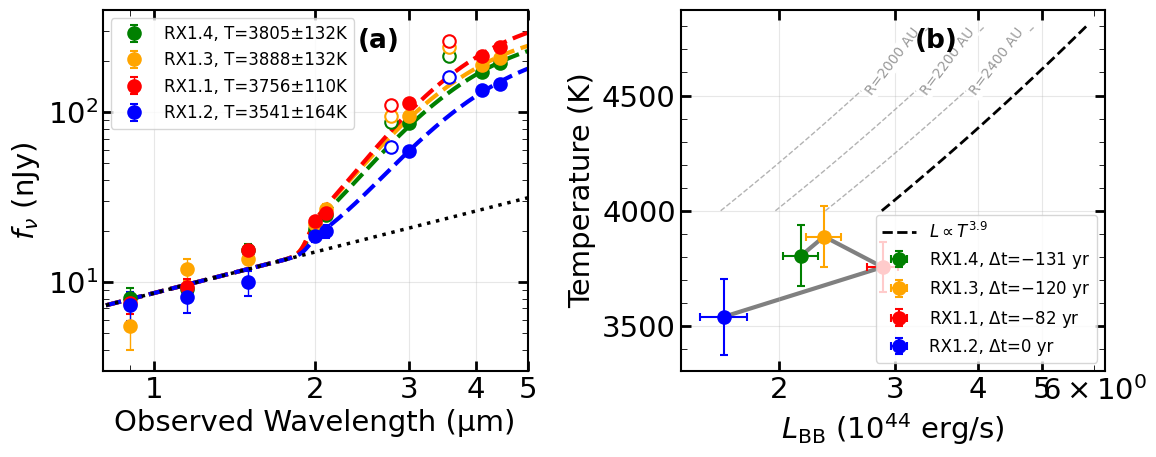

In [59]:
import extinction
# ===== 用户需提供的数据 =====
# wave_jwst: 波长数组，单位 µm
# jwstflux_list: 长度4列表，每个元素为 flux 数组 (nJy)
# jwstfluxerr_list: flux 不确定度
# lens_dict: 含时间延迟 td
# blackbody_Fnu(wavelength, T, norm) 已定义

colors = ['green','orange', 'red','blue'  ]
blue_cut = 1.0     # µm，仅用于标记蓝端
redshift = 4.3
AV_adopted = 0
# ===== 联合模型函数 =====
def joint_model_allbands(wavelengths_all, *params):
    """
    wavelengths_all: list of 4 arrays, 每个像的波长
    params: [T1,norm1, T2,norm2, T3,norm3, T4,norm4, A_PL, alpha, A_V]
    返回拼接后的 flux (已考虑统一的尘埃吸收)
    """
    flux_model_all = []
    # A_PL = params[-3]   # 共用 power-law 振幅
    # alpha = params[-2]  # 共用 power-law 指数
    # A_V = params[-1]    # 统一的消光参数
    A_PL = params[-2]   # 共用 power-law 振幅
    alpha = params[-1]  # 共用 power-law 指数
    A_V = AV_adopted

    for i, wl in enumerate(wavelengths_all):
        # wl 单位 µm → 转为 Å 供 extinction 使用
        wl_AA = wl * 1e4

        T = params[2*i]
        norm = params[2*i+1]

        # 本征黑体 + 功率律
        flux_bb = blackbody_Fnu(wl, T, norm, z=redshift)
        A_lambda = extinction.calzetti00(wl_AA/(1+redshift), A_V, r_v=4.05)
        flux_pl = A_PL * (wl/blue_cut)**alpha
        flux_int = flux_bb * 10**(-0.4 * A_lambda) + flux_pl

        # Calzetti extinction (A_lambda in mag)
        
        flux_obs = flux_int
        flux_model_all.append(flux_obs)

    return np.concatenate(flux_model_all)
# ===== 准备数据 =====
#1.3 与 1.4是相反的！
wavelengths_all = [wave_jwst[2:].value for _ in range(4)]
fluxes_all = np.concatenate([jwstflux_list[i][2:].value for i in range(4)])
fluxerrs_all = np.concatenate([jwstfluxerr_list[i][2:].value for i in range(4)])

# ===== 初始猜测和边界 =====
params0 = []
for _ in range(4):
    params0 += [4700, 44.5]  # T, norm
params0 += [0.5, -0.5]  # A_PL, alpha, A_V

lower_bounds = [3500, 44]*4 + [0.0, -3.0]
upper_bounds = [6000, 50]*4 + [100.0, 1.0]  # A_V 上限可根据需要调整

# ===== 联合拟合 =====
popt, pcov = curve_fit(joint_model_allbands, wavelengths_all, fluxes_all,
                       p0=params0, sigma=fluxerrs_all,
                       bounds=(lower_bounds, upper_bounds))

# ===== 提取结果 =====
fit_results = {}
# A_PL, alpha = popt[-2], popt[-1]
# print(f"共用 power-law 振幅: A_PL = {A_PL:.3f}, 指数 alpha = {alpha:.3f}")
for i in range(4):
    T = popt[2*i]
    norm = popt[2*i+1]
    T_err = np.sqrt(pcov[2*i, 2*i])
    norm_err = np.sqrt(pcov[2*i+1, 2*i+1])
    td = lens_dict[f'9.{i+1}']["dt"][0]
    fit_results[f'1.{i+1}'] = {'temperature': T, 'temperature_err': T_err, 'norm': norm, 'norm_err': norm_err, 'td': td}
    print(f'1.{i+1}: T={T:.0f} ± {T_err:.0f} K, norm={norm:.2f}')
# A_PL, alpha, A_V = popt[-3], popt[-2], popt[-1]
A_PL, alpha, A_V = popt[-2], popt[-1], AV_adopted
print(f"共用 power-law 振幅: A_PL = {A_PL:.3f}, 指数 alpha = {alpha:.3f}, A_V = {A_V:.2f}")

# ===== 绘图 =====
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))

fit_wave = np.linspace(0.3,5.0,300)
# --- 左图: SED + 拟合 + power-law ---
cori = 0
for i in np.array([4,3,1,2]) - 1:
    wl = wave_jwst.value
    flux = jwstflux_list[i].value
    fluxerr = jwstfluxerr_list[i].value
    T = fit_results[f'1.{i+1}']['temperature']
    T_err = fit_results[f'1.{i+1}']['temperature_err']
    norm = fit_results[f'1.{i+1}']['norm']
    norm_err = fit_results[f'1.{i+1}']['norm_err']
    color = colors[cori]
    cori +=1

    # flux_bb = blackbody_Fnu(fit_wave, T, norm, z = redshift)
    # flux_pl = A_PL * (fit_wave/blue_cut)**alpha
    # fit_flux = flux_bb + flux_pl
    A_lambda = extinction.calzetti00(fit_wave/(1+redshift) * 1e4, A_V, r_v=4.05)
    flux_bb = blackbody_Fnu(fit_wave, T, norm, z=redshift)
    flux_pl = A_PL * (fit_wave/blue_cut)**alpha
    flux_int = flux_bb * 10**(-0.4 * A_lambda) + flux_pl

    A_lambda_ = extinction.calzetti00(wl/(1+redshift) * 1e4, A_V, r_v=4.05)
    flux_bb_ = blackbody_Fnu(wl, T, norm, z=redshift)
    flux_pl_ = A_PL * (wl/blue_cut)**alpha
    flux_int_ = flux_bb_ * 10**(-0.4 * A_lambda_) + flux_pl_
    # flux_int = flux_bb + flux_pl

    # 加入消光（Calzetti曲线）
   
    fit_flux = flux_int 
    cutoff = -8
    ax1.errorbar(wl[:cutoff], flux[:cutoff], yerr=fluxerr[:cutoff],
                 fmt='o', ms=9, color=color, mfc='white', mew=1.5,
                 elinewidth=1, capsize=3)
    ax1.errorbar(wl[cutoff:], flux[cutoff:], yerr=fluxerr[cutoff:],
                 fmt='o', ms=9, color=color, mew=1.5,
                 elinewidth=1, capsize=3,
                 label=f'RX1.{i+1}, T={T:.0f}±{T_err:.0f}K')
    print('chi2:', np.sum(((flux[cutoff:] - flux_int_[cutoff:])/fluxerr[cutoff:])**2))

    # 总SED曲线（黑体+powerlaw）
    ax1.plot(fit_wave, fit_flux, '--', color=color, alpha=1.0, lw=3)
    # power-law单独虚线（可选）

ax1.plot(fit_wave, flux_pl, ':', color='k', alpha=1, lw=2.5)

# 左图设置
ax1.set_xlabel("Observed Wavelength (µm)")
ax1.set_ylabel(r"$f_{\nu}$ (nJy)")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(0.8, 5)
ax1.set_ylim(3, 4e2)
ax1.grid(True, alpha=0.3)
x_ticks = [ 1, 2, 3, 4,5]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(int(tick)) if tick < 10 else f"{int(tick)}" for tick in x_ticks])
ax1.legend(fontsize=12)

# ------------------------- 右图: T vs Lbol ------------------------- 
sorted_items = sorted(fit_results.items(), key=lambda x: -x[1]['td'])
names = [k for k,_ in sorted_items]
temps = np.array([v['temperature'] for _,v in sorted_items])
temp_errs = np.array([v['temperature_err'] for _,v in sorted_items])
logs_Lbol = np.array([v['norm'] for _,v in sorted_items])
logs_Lbol_errs = np.array([v['norm_err'] for _,v in sorted_items])
tds = np.array([v['td'] for _,v in sorted_items])

# 转换为线性 L 及误差
L = 10**logs_Lbol
L_err = np.log(10) * L * logs_Lbol_errs

for i, (Lval, Lerr, T, Terr, td, name) in enumerate(zip(L, L_err, temps, temp_errs, tds, names)):
    color = colors[i]
    if i!=3:
        sign = r'$-$' 
    else:
        sign = ''
    ax2.errorbar(Lval/1e44, T, 
                 xerr=Lerr/1e44, yerr=Terr,
                 fmt='o', color=color,
                 ms=9, mew=1.5, capsize=3,
                 label=f'RX{name}, Δt=' + sign + f'{td/365:.0f} yr')
# 指定连线顺序
order = [3, 2, 1, 0]  # Python索引，从0开始
L_ordered = np.array(10**logs_Lbol)[order] / 1e44
T_ordered = np.array(temps)[order]

# 连线
ax2.plot(L_ordered, T_ordered, '-', color='gray', lw=3, zorder=-1)  # zorder=-1 放在点的下方
# log-log 拟合
slope, intercept, r_value, p_value, stderr = linregress(np.log10(temps), logs_Lbol)
t_fit = np.linspace(4000,4800,100)
L_fit = 10**intercept * t_fit**slope
ax2.plot(L_fit/1e44, t_fit, 'k--', lw=2, label=r'$L \propto T^{%.1f}$' % slope)

# 理论半径

sigma = const.sigma_sb.cgs.value
for R_AU in [ 2000, 2200, 2400]:
    R_cm = (R_AU * u.AU).to(u.cm).value
    L_theory = 4 * np.pi * sigma * R_cm**2 * t_fit**4  # erg/s
    ax2.plot(L_theory/1e44, t_fit, '--', color='gray', lw=1.0, alpha=0.6, zorder=0)

    # 获取线的中间位置
    mid = len(t_fit) // 5 * 4
    x_mid = L_theory[mid]
    y_mid = t_fit[mid]

    # 沿着线的斜率旋转文字
    dx = np.log10(L_theory[mid+1]) - np.log10(L_theory[mid-1])
    dy = t_fit[mid+1] - t_fit[mid-1]
    angle = 53#np.degrees(np.arctan2(dy, dx * np.log(10)))
    
    ax2.text(
    x_mid/1e44, y_mid, f"R={R_AU} AU",
    color='gray', fontsize=10, alpha=0.8,
    rotation=angle, rotation_mode='anchor',
    ha='center', va='center',
    bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=1.5)
)

ax2.set_xscale('log')
ax2.set_xlabel(r"$L_{\rm BB}~ (10^{44}$ erg/s)")
ax2.set_ylabel("Temperature (K)")
# ax2.set_xlim(1.4,5)

ax2.grid(True, alpha=0.3)
x_ticks = [ 2,3,4,5]#,6,7
ax2.set_xticks(x_ticks)
ax2.set_xticklabels([str(t) for t in x_ticks])
ax2.legend(fontsize=12, loc=0)

ax1.text(0.6, 0.95, f'(a)', color='k', fontsize=19, transform=ax1.transAxes, ha='left', va='top', weight='bold')
ax2.text(0.55, 0.95, f'(b)', color='k', fontsize=19, transform=ax2.transAxes, ha='left', va='top', weight='bold')
plt.tight_layout()
# plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'RX1_BBfit.pdf', dpi=200, bbox_inches='tight')
# plt.show()

In [60]:
fluxerrs_all

array([1.20468567, 0.99449928, 1.09055254, 1.1123964 , 1.31076645,
       4.53492876, 8.62690188, 9.747029  , 1.66462288, 1.44690105,
       1.66294468, 1.4523397 , 1.7070923 , 2.361773  , 5.43295175,
       5.88699661, 1.93200016, 1.54901242, 1.77308138, 1.69259856,
       1.97096413, 3.80435666, 7.63522664, 8.35942123, 1.29766774,
       1.09090144, 1.21419152, 1.16486616, 1.45308453, 3.4698769 ,
       6.94641292, 7.74842637])

In [61]:
fluxerrs_all/fluxes_all

array([0.07830869, 0.13225619, 0.11674769, 0.04880029, 0.05144493,
       0.04      , 0.04      , 0.04      , 0.16726334, 0.19679671,
       0.20264532, 0.07753887, 0.08537324, 0.04      , 0.04      ,
       0.04      , 0.14176652, 0.28033545, 0.14840156, 0.07699594,
       0.07345078, 0.04      , 0.04      , 0.04      , 0.08436183,
       0.13452498, 0.13355804, 0.05644079, 0.05835141, 0.04      ,
       0.04      , 0.04      ])

In [62]:
Av = [0, 0.5, 1, 1.5]
logMBH = np.array([6.27565864, 6.34678749, 6.50168945, 6.6156328 ])
Teff = np.array([3750, 4050, 4450, 4800])
Lbol = np.array([2.377e+44, 2.8e+44, 4e+44, 5.2e+44]) * u.erg/u.s

# ==== 爱丁顿质量 ====
Ledd_per_Msun = 1.26e38 * u.erg/u.s
MBH = (Lbol / Ledd_per_Msun) * u.Msun
np.log10(MBH.value)

array([6.27565864, 6.34678749, 6.50168945, 6.6156328 ])

In [63]:
r_value, p_value

(0.6853158717028816, 0.31468412829711845)

In [64]:
# from astropy.cosmology import FlatLambdaCDM
# z = 4.3
# fit_flux_ = fit_flux * u.nJy
# fit_wave_ = fit_wave * 1e4 *u.AA /(1+z)
# bolometric_correction = 5.4
# # ==== 宇宙学 ====
# cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
# DL = cosmo.luminosity_distance(z)  # Mpc

# L_nu = (4 * np.pi * DL**2 * fit_flux_ / (1 + z)).cgs
# nu = (const.c / fit_wave_).to(u.Hz)
# nu_Lnu = L_nu * nu

# plt.plot(fit_wave_, nu_Lnu, '--', color=color, alpha=1.0, lw=3)
# plt.axvline(x = 5100)

In [65]:
# import numpy as np
# import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import scipy.stats as stats

def getlensing_para(src, img_idx):
    mu = lens_dict[f'{src}.{img_idx}']["mu"][0]
    mu_err = np.max([np.abs(lens_dict[f'{src}.{img_idx}']["mu"][2]), np.abs(lens_dict[f'{src}.{img_idx}']["mu"][1])])
    # mu_err = 0.2 * mu
    td = lens_dict[f'{src}.{img_idx}']["dt"][0]
    td_err = np.max([np.abs(lens_dict[f'{src}.{img_idx}']["dt"][2]), np.abs(lens_dict[f'{src}.{img_idx}']["dt"][1])])
    return mu, mu_err, td, td_err
chi2_results = {}
z = 4.3
# 分组
bright_bands = ['F150W2','F200W', 'F210M',  'F277W', 'F300M', 'F322W2', 'F356W', 'F410M', 'F444W']
# faint_bands = ['F090W', 'F115W', 'F150W', 'F200W', 'F210M']
# faint_bands = ['F150W', 'F200W', 'F210M']
faint_bands = ['F090W', 'F115W', 'F150W']
bright_bands_shift = [2.1, 1.1,1.1, 0.3, 0.45,0,-0.1,0,0.2]
bright_flux_keys = ['f_' + b for b in bright_bands]
bright_err_keys = ['e_' + b for b in bright_bands]

faint_flux_keys = ['f_' + b for b in faint_bands]
faint_err_keys = ['e_' + b for b in faint_bands]

# plt.figure(figsize=(10,8))
# ax = plt.gca()

# 渐变色蓝->红
cmap = get_cmap('coolwarm')
colors_bright = [cmap(i/(len(bright_bands)-1)) for i in range(len(bright_bands))]

# ---- stack 暗 band ----
stack_flux = []
stack_err = []
stack_tdelay = []

for i, col in enumerate(sel_tab):

    img_idx = int(col['ID_2'].split('.')[1])
    if(img_idx == 3):
        img_idx = 4
    elif(img_idx == 4):
        img_idx = 3
    mu, mu_err, td, td_err = getlensing_para(9, img_idx)
    mu_err = np.max([0.08*np.abs(mu), mu_err])   # assign a floor of magnification 
    flux_list = []
    flux_err_list = []

    for b in range(len(faint_bands)):
        f_obs = float(col[faint_flux_keys[b]])
        f_err_obs = float(col[faint_err_keys[b]])
        f_err_obs = np.max([f_err_obs, 0.4*f_err_obs])
        flux_list.append(f_obs)
        flux_err_list.append(f_err_obs)

    flux_list = np.array(flux_list)
    flux_err_list = np.array(flux_err_list)

    # 先在 flux 空间做加权平均
    weights = 1.0 / flux_err_list**2
    flux_stack_obs = np.sum(flux_list * weights) / np.sum(weights)
    flux_stack_obs_err = np.sqrt(1.0 / np.sum(weights))
    
    flux_stack_corr = flux_stack_obs / np.abs(mu)
    # 误差传播，只考虑 flux 叠加的不确定性，不放大 mu_err
    # flux_stack_corr_err = flux_stack_obs_err / np.abs(mu)

    # 转回 mag
    mag_stack = 31.4 - 2.5 * np.log10(flux_stack_corr)
    # mag_stack_err = (2.5 / np.log(10)) * flux_stack_corr_err / flux_stack_corr
    # mag_err = np.sqrt((2.5/np.log(10)*f_err_obs/f_obs)**2 + (2.5/np.log(10)*mu_err/np.abs(mu))**2)
    mag_stack_err = 2.5/np.log(10)* np.sqrt((flux_stack_obs_err/flux_stack_obs)**2 + (mu_err/np.abs(mu))**2)

    stack_flux.append(mag_stack)
    stack_err.append(mag_stack_err)
    stack_tdelay.append(td)

shift = bright_bands_shift[0]
stack_flux = np.array(stack_flux) - shift
stack_err = np.array(stack_err)
stack_tdelay = np.array(stack_tdelay)/365/(1+z)
idx_sort = np.argsort(stack_tdelay)
ax.errorbar(stack_tdelay[idx_sort], stack_flux[idx_sort], yerr=stack_err[idx_sort],
            fmt='o--', color='gray', label = f'F090W-F210M stacked (-{shift} mag)', capsize=2)

# ---- stack faint bands ----
weights = 1 / stack_err**2
mean_mag = np.sum(stack_flux * weights) / np.sum(weights)
chi2 = np.sum(((stack_flux - mean_mag)**2) / stack_err**2)
dof = len(stack_flux) - 1
chi2_red = chi2 / dof
p_value = 1 - stats.chi2.cdf(chi2, dof)
chi2_results['SW stack'] = dict(
    N=len(stack_flux),
    chi2=chi2,
    chi2_red=chi2_red,
    p_value=p_value
)

# # ---- 先画亮的 band ----
# for b, band in enumerate(bright_bands):
#     flux_band = []
#     flux_err_band = []
#     tdelay_band = []
#     shift = bright_bands_shift[b]
#     for i, col in enumerate(sel_tab):
#         img_idx = int(col['ID_2'].split('.')[1]) 
#         if(img_idx == 3):
#             img_idx = 4
#         elif(img_idx == 4):
#             img_idx = 3
    
#         mu, mu_err, td, td_err = getlensing_para(9, img_idx)
#         mu_err = np.max([0.2*mu, mu_err])
        
#         f_obs = float(col[bright_flux_keys[b]])
#         f_err_obs = float(col[bright_err_keys[b]])

#         f_corr = f_obs / np.abs(mu)
#         mag_corr = 31.4 - 2.5*np.log10(f_corr)
#         mag_err = np.sqrt((2.5/np.log(10)*f_err_obs/f_obs)**2 + (2.5/np.log(10)*mu_err/np.abs(mu))**2)

#         flux_band.append(mag_corr)
#         flux_err_band.append(mag_err)
#         tdelay_band.append(td)

#     flux_band = np.array(flux_band)
#     flux_err_band = np.array(flux_err_band)
#     tdelay_band = np.array(tdelay_band)/365/(1+z)

#     idx_sort = np.argsort(tdelay_band)
#     if(shift != 0):
#         if(shift > 0):
#             text = band + (r'($-$' + f'{np.abs(shift)} mag)')
#         else:
#             text = band + (r'($+$' + f'{np.abs(shift)} mag)')
#         ax.errorbar(tdelay_band[idx_sort], flux_band[idx_sort] - shift,
#                     yerr=flux_err_band[idx_sort],
#                     fmt='o-', color=colors_bright[b], label=text, capsize=5)
#     else:
#         ax.errorbar(tdelay_band[idx_sort], flux_band[idx_sort],
#                     yerr=flux_err_band[idx_sort],
#                     fmt='o-', color=colors_bright[b], label=band, capsize=5)

#     # 加权平均作为恒定模型
#     weights = 1 / flux_err_band**2
#     mean_mag = np.sum(flux_band * weights) / np.sum(weights)

#     chi2 = np.sum(((flux_band - mean_mag)**2) / flux_err_band**2)
#     dof = len(flux_band) - 1
#     chi2_red = chi2 / dof
#     p_value = 1 - stats.chi2.cdf(chi2, dof)

#     chi2_results[band] = dict(
#         N=len(flux_band),
#         chi2=chi2,
#         chi2_red=chi2_red,
#         p_value=p_value
#     )


# # ---- 画图美化 ----
# ax.set_xlabel("Time Delay (years)")
# ax.set_ylabel("Magnitude (AB)")
# ax.invert_yaxis()
# # ax.set_title("System-1 JWST Light Curves (Bright bands + stacked faint bands)")
# ax.grid(alpha=0.3)

# # 横向 legend
# ax.legend(frameon=False, fontsize=10, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.35))

# # ---- 添加rest-frame时间轴 ----
# z = 4.8
# def obs_to_rest(t_obs):
#     return t_obs / (1 + z)

# def rest_to_obs(t_rest):
#     return t_rest * (1 + z)

# secax = ax.secondary_xaxis('top', functions=(obs_to_rest, rest_to_obs))
# secax.set_xlabel(f"Rest-frame Time (years, z={z})")
# secax.xaxis.labelpad = 8  # 轴标签与图的间距
# # ---- 去掉上轴多余的刻度 ----
# secax.tick_params(which='both', direction='out', top=True, labeltop=True)
# # secax.set_ticks_position('top')  # 确保只在上方显示
# # secax.xaxis.set_tick_params(bottom=False)  # 不在下方重复显示
# # # 若想让刻度更稀疏（只显示几个）
# # secax.set_xticks(np.linspace(*ax.get_xlim(), 5))  # 5个主刻度，可调整数量

# plt.tight_layout()
# plt.show()

# # ---- 输出结果 ----
# print(f"{'Band':<15} {'N':<4} {'chi2':<10} {'chi2_red':<10} {'p-value':<10}")
# for band, res in chi2_results.items():
#     print(f"{band:<15} {res['N']:<4d} {res['chi2']:<10.3f} {res['chi2_red']:<10.3f} {res['p_value']:<10.3f}")

# # ---- 计算每个band的最大光变幅度（含误差） ----
# print("\nMaximum variability amplitude (Δmag ± err):")
# for band, res in chi2_results.items():
#     if band == 'SW stack':
#         continue  # 跳过stack结果
#     flux_band = []
#     flux_err_band = []
#     for col in sel_tab:
#         img_idx = int(col['ID_2'].split('.')[1])
#         if(img_idx == 3):
#             img_idx = 4
#         elif(img_idx == 4):
#             img_idx = 3
#         mu, mu_err, td, td_err = getlensing_para(9, img_idx)
#         f_obs = float(col['f_' + band])
#         f_err_obs = float(col['e_' + band])
#         f_corr = f_obs / np.abs(mu)
#         mag_corr = 31.4 - 2.5 * np.log10(f_corr)
#         mag_err = np.sqrt(
#             (2.5 / np.log(10) * f_err_obs / f_obs) ** 2 +
#             (2.5 / np.log(10) * mu_err / np.abs(mu)) ** 2
#         )

#         flux_band.append(mag_corr)
#         flux_err_band.append(mag_err)

#     flux_band = np.array(flux_band)
#     flux_err_band = np.array(flux_err_band)

#     idx_max = np.argmax(flux_band)
#     idx_min = np.argmin(flux_band)
#     delta_mag = flux_band[idx_max] - flux_band[idx_min]
#     delta_mag_err = np.sqrt(flux_err_band[idx_max] ** 2 + flux_err_band[idx_min] ** 2)

#     print(f"{band:<15} Δmag = {delta_mag:.3f} ± {delta_mag_err:.3f}")`

In [66]:
import numpy as np
import emcee
from scipy.optimize import minimize

def estimate_intrinsic_variability(x, sig_i):
    """
    使用 MCMC 采样计算固有变率 sigma_0 的后验分布
    x: 观测星等数组
    sig_i: 观测误差数组
    返回: sigma_0 (中位数), sigma_0_err (1-sigma对称化), mean_sig_i
    """
    x = np.array(x)
    sig_i = np.array(sig_i)
    
    # 1. 定义对数似然函数 (Log-Likelihood)
    def log_likelihood(theta, x, sig_i):
        mu, s0 = theta
        if s0 < 0:  # 强加先验：sigma_0 必须大于0
            return -np.inf
        variance = s0**2 + sig_i**2
        return -0.5 * np.sum(((x - mu)**2 / variance) + np.log(variance))

    # 2. 寻找极大似然估计 (MLE) 作为 MCMC 的起点
    nll = lambda *args: -log_likelihood(*args)
    initial = np.array([np.mean(x), np.std(x)])
    soln = minimize(nll, initial, args=(x, sig_i), bounds=[(None, None), (1e-6, None)])
    
    # 3. MCMC 设置
    nwalkers = 32
    ndim = 2
    # 在 MLE 结果附近播种初始位置
    pos = soln.x + 1e-4 * np.random.randn(nwalkers, ndim)
    
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, args=(x, sig_i))
    
    # 运行 Burn-in 和正式采样
    sampler.run_mcmc(pos, 1500, progress=False)
    
    # 获取平稳后的样本 (去掉前 300 步 burn-in)
    flat_samples = sampler.get_chain(discard=300, thin=15, flat=True)
    
    # 4. 提取结果 (使用分位数提取 sigma_0)
    # sigma_0 是第 2 列 (index 1)
    s0_mcmc = np.percentile(flat_samples[:, 1], [16, 50, 84])
    s0_mcmc_3sigma = np.percentile(flat_samples[:, 1], [0.135, 50, 99.865])
    
    # sigma_0_med = s0_mcmc[1]
    # 使用 1-sigma 的平均值作为对称误差
    # sigma_0_err = (s0_mcmc[2] - s0_mcmc[0]) / 2.0
    
    mean_sig_i = np.mean(sig_i)
    
    # return sigma_0_med, sigma_0_err, mean_sig_i
    return s0_mcmc , s0_mcmc_3sigma , mean_sig_i

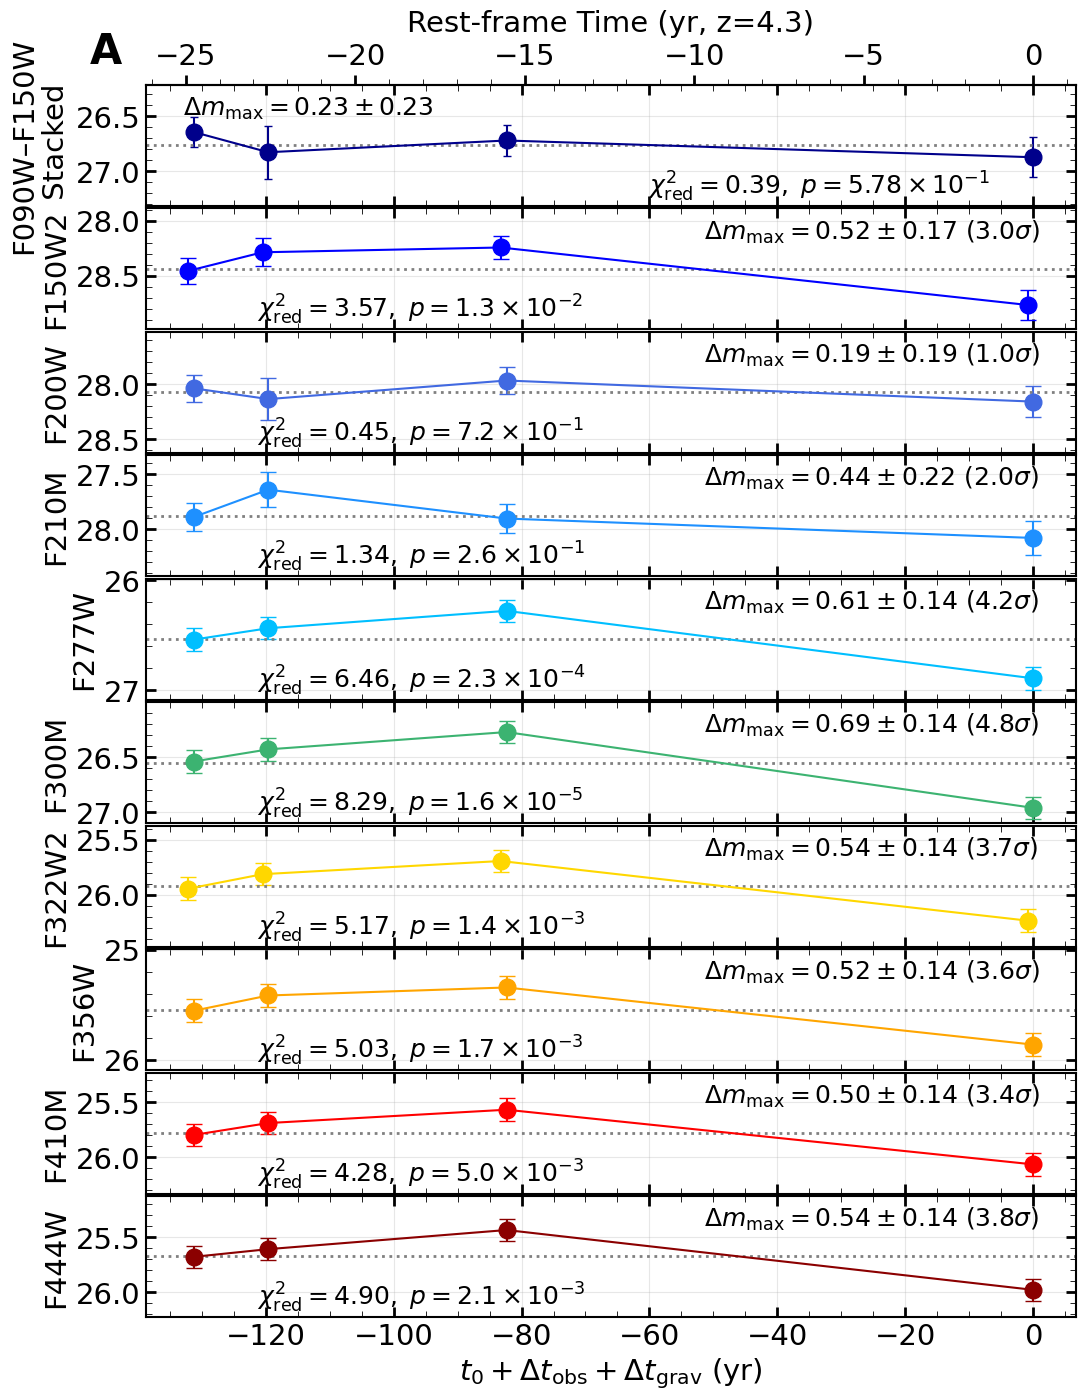

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import get_cmap
# from referee_check_z6magnification import chi2_2


# 初始化用于存储表格数据的列表
latex_rows = []

# ---- 配色 ----
cmap = get_cmap('RdBu')
# colors_bright = [cmap(i/(len(bright_bands)-1)) for i in range(len(bright_bands))]
colors_bright = [
        # 最短波
    'blue',        # 
    'royalblue',   # 
    'dodgerblue',  # 
    'deepskyblue', # 
    # 'cyan',        # 
    'mediumseagreen', # 中间波段用绿色区分
    'gold',        # 
    'orange',      # 
    'red',         # 
    'darkred'      # 最长波
]
symbolsize = 12
# ---- 创建子图 (stack + bright bands) ----
n_panels = len(bright_bands) + 1
fig, axes = plt.subplots(n_panels, 1, figsize=(12, 1.6 * n_panels), sharex=True)
if n_panels == 1:
    axes = [axes]

# ===============================================================
# (1) 绘制 stacked faint bands
# ===============================================================
ax = axes[0]
idx_sort = np.argsort(stack_tdelay)
idx_max = np.argmax(stack_flux)
idx_min = np.argmin(stack_flux)
delta_mag = stack_flux[idx_max] - stack_flux[idx_min]
delta_mag_err = np.sqrt(stack_err[idx_max] ** 2 + stack_err[idx_min] ** 2)
mask = ~np.isnan(stack_flux) & ~np.isnan(stack_err)
clean_flux = stack_flux[mask]
clean_err = stack_err[mask]
    
(sigma_0_down, sigma_0, sigma_0_up), _ ,avg_sig_i = estimate_intrinsic_variability(clean_flux, clean_err)

   
ml_text = (r"$\sigma_0 = %.2f^{+%.2f}_{-%.2f}$" % (sigma_0, sigma_0_up - sigma_0, sigma_0 - sigma_0_down) + #"\n" +
           r", $\langle \sigma_i \rangle = %.2f$" % (avg_sig_i))
# ax.text(0.54, 0.7, ml_text, fontsize=14, transform=ax.transAxes, 
#             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.text(0.04, 0.75, r'$\Delta m_{\rm max} = %.2f \pm %.2f$' % (delta_mag, delta_mag_err), fontsize = 18, transform=ax.transAxes)
ax.errorbar(
    -stack_tdelay[idx_sort]*(1+z), stack_flux[idx_sort], yerr=stack_err[idx_sort], markersize = symbolsize,
    fmt='o-', color='darkblue', capsize=3
)
chi = chi2_results['SW stack']['chi2_red']
stack_row = (
    f"F090W--F150W Stack & "
    f"${sigma_0:.2f}^{{+{sigma_0_up - sigma_0:.2f}}}_{{-{sigma_0 - sigma_0_down:.2f}}}$ & "
    f"${avg_sig_i:.2f}$ & "
    f"${delta_mag:.2f} \\pm {delta_mag_err:.2f}$ & "
    f"${chi:.2f}$ \\\\"
)
latex_rows.append(stack_row)
N = 4
pvalue = 1 - stats.chi2.cdf(chi * (1 + N), df=N-1)
mantissa, exponent = f"{pvalue:.2e}".split("e")
exponent = int(exponent)
p_latex = r"%s\times10^{%d}" % (mantissa, exponent)

ax.text(0.54, 0.1, r'$\chi^2_{\rm red} = %.2f,\ p = %s$' % (chi, p_latex), fontsize = 18, transform=ax.transAxes)

ax.invert_yaxis()
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=9, loc='best')
ax.set_ylabel('F090W–F150W\n Stacked')
# ax.set_title("System-1 JWST Light Curves")

# 围绕该stack的平均值 ±0.4 mag
mean_stack = np.nanmean(stack_flux)
y_half_range = 0.55
ax.set_ylim(mean_stack + y_half_range, mean_stack - y_half_range)

# 灰色基线（平均值）
ax.axhline(mean_stack, color='gray', ls=':', lw=2)

# ===============================================================
# (2) 绘制每个 bright band
# ===============================================================
for b, band in enumerate(bright_bands):
    ax = axes[b+1]
    shift = bright_bands_shift[b]
    color = colors_bright[b]

    flux_band = []
    flux_err_band = []
    tdelay_band = []

    for i, col in enumerate(sel_tab):
        img_idx = int(col['ID_2'].split('.')[1])
        if(img_idx == 3):
            img_idx = 4
        elif(img_idx == 4):
            img_idx = 3 
        mu, mu_err, td, td_err = getlensing_para(9, img_idx)
        mu_err = np.max([0.08*np.abs(mu), mu_err])
        # print(mu_err, mu)
        f_obs = float(col['f_' + band])
        f_err_obs = float(col['e_' + band])
        f_err_obs = max(f_err_obs, 0.04 * f_obs)

        f_corr = f_obs / np.abs(mu)
        mag_corr = 31.4 - 2.5 * np.log10(f_corr)
        mag_err = np.sqrt((2.5/np.log(10)*f_err_obs/f_obs)**2 +
                          (2.5/np.log(10)*mu_err/np.abs(mu))**2)

        flux_band.append(mag_corr)
        flux_err_band.append(mag_err)
        tdelay_band.append(td)

    flux_band = np.array(flux_band)
    flux_err_band = np.array(flux_err_band)
    tdelay_band = np.array(tdelay_band)/365
    idx_sort = np.argsort(tdelay_band)
    idx_max = np.argmax(flux_band)
    idx_min = np.argmin(flux_band)
    delta_mag = flux_band[idx_max] - flux_band[idx_min]
    delta_mag_err = np.sqrt(flux_err_band[idx_max] ** 2 + flux_err_band[idx_min] ** 2)

    # --- 使用 ML 方法计算变率 ---
    # 去除可能存在的 NaN
    mask = ~np.isnan(flux_band) & ~np.isnan(flux_err_band)
    clean_flux = flux_band[mask]
    clean_err = flux_err_band[mask]
    
    # sigma_0, sigma_0_err, avg_sig_i = estimate_intrinsic_variability(clean_flux, clean_err)
    (sigma_0_down, sigma_0, sigma_0_up),_, avg_sig_i = estimate_intrinsic_variability(clean_flux, clean_err)

    # --- 绘图标注 ---
    # 替换原来的 chi2 标注，或者在其下方添加
    # ml_text = (r"$\sigma_0 = %.2f \pm %.2f$" % (sigma_0, sigma_0_err) + "\n" +
            #    r"$\langle \sigma_i \rangle = %.2f$" % (avg_sig_i))
    ml_text = (r"$\sigma_0 = %.2f^{+%.2f}_{-%.2f}$" % (sigma_0, sigma_0_up - sigma_0, sigma_0 - sigma_0_down) + #"\n" +
           r", $\langle \sigma_i \rangle = %.2f$" % (avg_sig_i))
    
    # ax.text(0.52, 0.15, ml_text, fontsize=14, transform=ax.transAxes, 
    #         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # 绘制该band光变曲线
    if('W2' in band):
        tdelay_band += 0.9
    ax.errorbar(
        -tdelay_band[idx_sort],
        flux_band[idx_sort], #- shift,
        yerr=flux_err_band[idx_sort],
        fmt='o-',
        color=color,
        capsize=6,
        markersize = symbolsize
        # label=band #if shift == 0 else f"{band} ({'-' if shift>0 else '+'}{abs(shift)} mag)"
    )
    # print(f"{band}:", flux_err_band[idx_sort])
    ax.text(0.6, 0.75, r'$\Delta m_{\rm max} = %.2f \pm %.2f~(%.1f \sigma)$' % (delta_mag, delta_mag_err, delta_mag/delta_mag_err), fontsize = 18, transform=ax.transAxes)
    # chi = chi2_results[band]['chi2_red']
    chi2 = np.sum(((flux_band - np.nanmean(flux_band))**2) / flux_err_band**2) 
    chi2_red = chi2 / (len(flux_band)-1)
    band_row = (
        f"{band} & "
        f"${sigma_0:.2f}^{{+{sigma_0_up - sigma_0:.2f}}}_{{-{sigma_0 - sigma_0_down:.2f}}}$ & "
        f"${avg_sig_i:.2f}$ & "
        f"${delta_mag:.2f} \\pm {delta_mag_err:.2f}$ & "
        f"${chi2_red:.2f}$ \\\\"
    )
    latex_rows.append(band_row)
    
    N = 4
    pvalue = 1 - stats.chi2.cdf(chi2, df=N-1)
    mantissa, exponent = f"{pvalue:.1e}".split("e")
    exponent = int(exponent)
    p_latex = r"%s\times10^{%d}" % (mantissa, exponent)

    ax.text(
        0.12, 0.1,
        r'$\chi^2_{\rm red} = %.2f,\ p = %s$' % (chi2_red, p_latex),
        fontsize=18,
        transform=ax.transAxes
    )

    ax.invert_yaxis()
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=9, loc='best')
    ax.set_ylabel(band)

    # ---- 每个band围绕自身平均值设定y轴范围 ----
    mean_mag = np.nanmean(flux_band )
    ax.set_ylim(mean_mag + y_half_range, mean_mag - y_half_range)
    ax.axhline(mean_mag, color='gray', ls=':', lw=2)  # 平均值基线

# ===============================================================
# (3) 共用x轴 + rest-frame secondary axis
# ===============================================================
axes[-1].set_xlabel(r"$t_0 + \Delta t_{\rm obs} + \Delta t_{\rm grav}$" + " (yr)")

def obs_to_rest(t_obs):
    return t_obs / (1 + z)
def rest_to_obs(t_rest):
    return t_rest * (1 + z)

secax = axes[0].secondary_xaxis('top', functions=(obs_to_rest, rest_to_obs))
secax.set_xlabel(f"Rest-frame Time (yr, z={z})")
secax.xaxis.labelpad = 8
secax.tick_params(which='both', direction='out', top=True, labeltop=True)

plt.text(-0.06, 1.45, 'A', color='k', fontsize=30, ha='left', va='top', weight='bold', transform=axes[0].transAxes)
# plt.tight_layout()
plt.subplots_adjust(hspace=0.02)  # 调小子图间距，原默认≈0.2–0.3
plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'RX1_lc.pdf', dpi=200, bbox_inches='tight',pad_inches=0.2)
plt.show()

In [68]:
# ==============================================================================
# (3) 循环结束后，自动生成并打印完整的 LaTeX 源代码
# ==============================================================================
print("\n" + "="*20 + " 生成的 LaTeX 表格代码 " + "="*20)
print(r"\begin{table}[htbp]")
print(r"\centering")
print(r"\caption{Summary of intrinsic variability, observational errors, and light curve statistics.}")
print(r"\label{tab:variability_results}")
print(r"\begin{tabular}{lcccc}")
print(r"\toprule")
print(r"\textbf{Band / Filter} & \textbf{Intrinsic Variability ($\sigma_0$)} & \textbf{Mean Error ($\langle \sigma_i \rangle$)} & \textbf{Max Variation ($\Delta m_{\rm max}$)} & $\chi^2_{\rm red}$ \\")
print(r"\midrule")
# 先打印 Stacked 行
print(" " * 4 + latex_rows[0])
print(r"\midrule")
# 再循环打印各独立 Band 行
for row in latex_rows[1:]:
    print(" " * 4 + row)
print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")
print("="*60)


==================== 生成的 LaTeX 表格代码 ====================
\begin{table}[htbp]
\centering
\caption{Summary of intrinsic variability, observational errors, and light curve statistics.}
\label{tab:variability_results}
\begin{tabular}{lcccc}
\toprule
\textbf{Band / Filter} & \textbf{Intrinsic Variability ($\sigma_0$)} & \textbf{Mean Error ($\langle \sigma_i \rangle$)} & \textbf{Max Variation ($\Delta m_{\rm max}$)} & $\chi^2_{\rm red}$ \\
\midrule
    F090W--F150W Stack & $0.12^{+0.18}_{-0.08}$ & $0.17$ & $0.23 \pm 0.23$ & $0.39$ \\
\midrule
    F150W2 & $0.28^{+0.33}_{-0.14}$ & $0.12$ & $0.52 \pm 0.17$ & $3.57$ \\
    F200W & $0.11^{+0.17}_{-0.07}$ & $0.14$ & $0.19 \pm 0.19$ & $0.45$ \\
    F210M & $0.16^{+0.24}_{-0.11}$ & $0.14$ & $0.44 \pm 0.22$ & $1.34$ \\
    F277W & $0.34^{+0.35}_{-0.14}$ & $0.10$ & $0.61 \pm 0.14$ & $6.46$ \\
    F300M & $0.41^{+0.37}_{-0.17}$ & $0.10$ & $0.69 \pm 0.14$ & $8.29$ \\
    F322W2 & $0.31^{+0.32}_{-0.14}$ & $0.10$ & $0.54 \pm 0.14$ & $5.17$ \\
    F356W 

In [69]:
import numpy as np
import scipy.stats as stats

np.random.seed(42)

# ---------------------------
# 参数
# ---------------------------
N = 4
n_sim = 1000
sigma_meas = 0.05
sigma_int_true = 0.2   # intrinsic variability

# ---------------------------
# 存储结果
# ---------------------------
chi_detect_null = []
chi_detect_var  = []

rms_detect_null = []
rms_detect_var  = []
rms_detect_null3sigma = []
rms_detect_var3sigma  = []
# ---------------------------
# 主循环
# ---------------------------
from tqdm import tqdm
# for i in range(n_sim):
for i in tqdm(range(n_sim)):

    true_val = 25.0

    # ===== 无光变 =====
    noise = np.random.normal(0, sigma_meas, N)
    x_null = true_val + noise
    err_null = np.ones(N) * sigma_meas

    # ===== 有光变 =====
    intrinsic = np.random.normal(0, sigma_int_true, N)
    noise = np.random.normal(0, sigma_meas, N)
    x_var = true_val + intrinsic + noise
    err_var = np.ones(N) * sigma_meas

    # =========================
    # χ² 判据
    # =========================
    def chi2_detect(x, err):
        mean = np.mean(x)
        chi2 = np.sum((x - mean)**2 / err**2)
        p = 1 - stats.chi2.cdf(chi2, df=N-1)
        return p < 0.05

    chi_detect_null.append(chi2_detect(x_null, err_null))
    chi_detect_var.append(chi2_detect(x_var, err_var))

    # =========================
    # σ0 判据（你的方法）
    # =========================
    def rms_detect(x, err):
        # 调用你自己的函数
        (sigma_0_down, sigma_0, sigma_0_up), (sigma_0_down_3sigma, sigma_0, sigma_0_up), avg_sig_i = \
            estimate_intrinsic_variability(x, err)

        # 关键：3σ 下界是否 > 0
        return sigma_0_down > 0, sigma_0_down_3sigma > 0

    null_detect = rms_detect(x_null, err_null)
    var_detect = rms_detect(x_var, err_var)
    rms_detect_null.append(null_detect[0])
    rms_detect_var.append(var_detect[0])
    rms_detect_null3sigma.append(null_detect[1])
    rms_detect_var3sigma.append(var_detect[1])

# ---------------------------
# 统计结果
# ---------------------------
print("=== Detection Rate ===")
print(f"Chi2 (null): {np.mean(chi_detect_null):.3f}")
print(f"Chi2 (var ): {np.mean(chi_detect_var):.3f}")
print(f"σ0   (null): {np.mean(rms_detect_null):.3f}")
print(f"σ0   (var ): {np.mean(rms_detect_var):.3f}")

  1%|          | 8/1000 [00:06<13:39,  1.21it/s]Traceback (most recent call last):
  File "/Users/zijianzhang/miniconda3/envs/msaexp39/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_52499/1171086616.py", line 21, in log_likelihood
    return -0.5 * np.sum(((x - mu)**2 / variance) + np.log(variance))
KeyboardInterrupt
  1%|          | 8/1000 [00:07<15:20,  1.08it/s]

emcee: Exception while calling your likelihood function:
  params: [24.95936165  0.31314656]
  args: (array([25.32347939, 24.78716904, 25.07659495, 24.87024087]), array([0.05, 0.05, 0.05, 0.05]))
  kwargs: {}
  exception:


KeyboardInterrupt: 

In [ ]:
1 - stats.chi2.cdf(2.6 * (N-1), df=N-1)

0.050331097859853346

In [ ]:
from joblib import Parallel, delayed

N = 4
n_sim = 1000
sigma_meas = 0.1
sigma_int_true = 0.3   # intrinsic variability

def run_one_sim(_):
    true_val = 25.0

    # ===== 无光变 =====
    noise = np.random.normal(0, sigma_meas, N)
    x_null = true_val + noise
    err_null = np.ones(N) * sigma_meas

    # ===== 有光变 =====
    intrinsic = np.random.normal(0, sigma_int_true, N)
    noise = np.random.normal(0, sigma_meas, N)
    x_var = true_val + intrinsic + noise
    err_var = np.ones(N) * sigma_meas

    # =========================
    # χ² 判据
    # =========================
    def chi2_detect(x, err):
        mean = np.mean(x)
        chi2 = np.sum((x - mean)**2 / err**2)
        p = 1 - stats.chi2.cdf(chi2, df=N-1)
        return p < 0.05

    chi_null = chi2_detect(x_null, err_null)
    chi_var  = chi2_detect(x_var, err_var)

    # =========================
    # σ0 判据
    # =========================
    def rms_detect(x, err):
        (sigma_0_down, sigma_0, sigma_0_up), \
        (sigma_0_down_3sigma, sigma_0, sigma_0_up), \
        avg_sig_i = estimate_intrinsic_variability(x, err)

        return (sigma_0_down > 0.1,
                sigma_0_down_3sigma > 0.1)

    null_detect = rms_detect(x_null, err_null)
    var_detect  = rms_detect(x_var, err_var)

    return (
        chi_null,
        chi_var,
        null_detect[0],
        var_detect[0],
        null_detect[1],
        var_detect[1],
    )

results = Parallel(n_jobs=-1, verbose=5)(
    delayed(run_one_sim)(i) for i in range(n_sim)
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 240 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-1)]: Done 402 tasks      | elapsed:   28.1s
[Parallel(n_jobs=-1)]: Done 600 tasks      | elapsed:   41.7s
[Parallel(n_jobs=-1)]: Done 834 tasks      | elapsed:   57.4s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  1.1min finished


In [ ]:
results = np.array(results)

chi_detect_null = results[:, 0]
chi_detect_var  = results[:, 1]

rms_detect_null = results[:, 2]
rms_detect_var  = results[:, 3]

rms_detect_null3sigma = results[:, 4]
rms_detect_var3sigma  = results[:, 5]

print("=== Detection Rate ===")
print(f"Chi2 (null): {np.mean(chi_detect_null):.3f}")
print(f"Chi2 (var ): {np.mean(chi_detect_var):.3f}")
print(f"σ0   (null): {np.mean(rms_detect_null):.3f}")
print(f"σ0   (var ): {np.mean(rms_detect_var):.3f}")
print(f"σ0   (null): {np.mean(rms_detect_null3sigma):.3f}")
print(f"σ0   (var ): {np.mean(rms_detect_var3sigma):.3f}")

=== Detection Rate ===
Chi2 (null): 0.043
Chi2 (var ): 0.853
σ0   (null): 0.030
σ0   (var ): 0.828
σ0   (null): 0.000
σ0   (var ): 0.421


In [ ]:
sel_tab

ID_2,RA_1_1,DEC_1_1,id_2_1,RA_2_1,DEC_2_1,f_F090W,e_F090W,f_F115W,e_F115W,f_F150W2,e_F150W2,f_F150W,e_F150W,f_F200W,e_F200W,f_F210M,e_F210M,f_F277W,e_F277W,f_F300M,e_F300M,f_F322W2,e_F322W2,f_F356W,e_F356W,f_F410M,e_F410M,f_F444W,e_F444W,Separation_1,id_1_2,ra_1_2,dec_1_2,f435w_mag,f435w_magerr_1,f435w_flux,f435w_fluxerr,f435w_fluxnJy,f435w_fluxnJyerr,f435w_sig,f606w_mag,f606w_magerr_1,f606w_flux,f606w_fluxerr,f606w_fluxnJy,f606w_fluxnJyerr,f606w_sig,f814w_mag,f814w_magerr_1,f814w_flux,f814w_fluxerr,f814w_fluxnJy,f814w_fluxnJyerr,f814w_sig,f105w_mag,f105w_magerr_1,f105w_flux,f105w_fluxerr,f105w_fluxnJy,f105w_fluxnJyerr,f105w_sig,f125w_mag,f125w_magerr_1,f125w_flux,f125w_fluxerr,f125w_fluxnJy,f125w_fluxnJyerr,f125w_sig,f140w_mag,f140w_magerr_1,f140w_flux,f140w_fluxerr,f140w_fluxnJy,f140w_fluxnJyerr,f140w_sig,f160w_mag,f160w_magerr_1,f160w_flux,f160w_fluxerr,f160w_fluxnJy,f160w_fluxnJyerr,f160w_sig,ra_2_2,dec_2_2,f125w_fluxerr_njy,f125w_magerr_2,f140w_fluxerr_njy,f140w_magerr_2,f105w_fluxerr_njy,f105w_magerr_2,f606w_fluxerr_njy,f606w_magerr_2,f435w_fluxerr_njy,f435w_magerr_2,f814w_fluxerr_njy,f814w_magerr_2,f160w_fluxerr_njy,f160w_magerr_2,ID_2_2,Separation_2,Separation_1a,f125w_sig_new,f140w_sig_new,f105w_sig_new,f606w_sig_new,f435w_sig_new,f814w_sig_new,f160w_sig_new,F435W_CIRC1,F435W_CIRC1_e,F606W_CIRC1,F606W_CIRC1_e,F814W_CIRC1,F814W_CIRC1_e,ID,RA,DEC,X,Y,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,area,semimajor_sigma,semiminor_sigma,orientation,eccentricity,min_value,max_value,local_background,kron_radius,Gini,det_segment_flux,det_segment_fluxerr,det_kron_flux,det_kron_fluxerr,F090W_CIRC1,F090W_CIRC1_e,F090W_CIRC1_en,F090W_CIRC2,F090W_CIRC2_e,F090W_CIRC2_en,F090W_CIRC3,F090W_CIRC3_e,F090W_CIRC3_en,F090W_CIRC4,F090W_CIRC4_e,F090W_CIRC4_en,F090W_CIRC5,F090W_CIRC5_e,F090W_CIRC5_en,F090W_CIRC6,F090W_CIRC6_e,F090W_CIRC6_en,F090W_KRON,F090W_KRON_S,F090W_KRON_S_e,F090W_KRON_S_en,F090W_KRON_e,F090W_KRON_en,F090W_local_background,F090W_segment_flux,F090W_segment_flux_err,F115W_CIRC1,F115W_CIRC1_e,F115W_CIRC1_en,F115W_CIRC2,F115W_CIRC2_e,F115W_CIRC2_en,F115W_CIRC3,F115W_CIRC3_e,F115W_CIRC3_en,F115W_CIRC4,F115W_CIRC4_e,F115W_CIRC4_en,F115W_CIRC5,F115W_CIRC5_e,F115W_CIRC5_en,F115W_CIRC6,F115W_CIRC6_e,F115W_CIRC6_en,F115W_KRON,F115W_KRON_S,F115W_KRON_S_e,F115W_KRON_S_en,F115W_KRON_e,F115W_KRON_en,F115W_local_background,F115W_segment_flux,F115W_segment_flux_err,F150W2_CIRC1,F150W2_CIRC1_e,F150W2_CIRC1_en,F150W2_CIRC2,F150W2_CIRC2_e,F150W2_CIRC2_en,F150W2_CIRC3,F150W2_CIRC3_e,F150W2_CIRC3_en,F150W2_CIRC4,F150W2_CIRC4_e,F150W2_CIRC4_en,F150W2_CIRC5,F150W2_CIRC5_e,F150W2_CIRC5_en,F150W2_CIRC6,F150W2_CIRC6_e,F150W2_CIRC6_en,F150W2_KRON,F150W2_KRON_S,F150W2_KRON_S_e,F150W2_KRON_S_en,F150W2_KRON_e,F150W2_KRON_en,F150W2_local_background,F150W2_segment_flux,F150W2_segment_flux_err,F150W_CIRC1,F150W_CIRC1_e,F150W_CIRC1_en,F150W_CIRC2,F150W_CIRC2_e,F150W_CIRC2_en,F150W_CIRC3,F150W_CIRC3_e,F150W_CIRC3_en,F150W_CIRC4,F150W_CIRC4_e,F150W_CIRC4_en,F150W_CIRC5,F150W_CIRC5_e,F150W_CIRC5_en,F150W_CIRC6,F150W_CIRC6_e,F150W_CIRC6_en,F150W_KRON,F150W_KRON_S,F150W_KRON_S_e,F150W_KRON_S_en,F150W_KRON_e,F150W_KRON_en,F150W_local_background,F150W_segment_flux,F150W_segment_flux_err,F200W_CIRC1,F200W_CIRC1_e,F200W_CIRC1_en,F200W_CIRC2,F200W_CIRC2_e,F200W_CIRC2_en,F200W_CIRC3,F200W_CIRC3_e,F200W_CIRC3_en,F200W_CIRC4,F200W_CIRC4_e,F200W_CIRC4_en,F200W_CIRC5,F200W_CIRC5_e,F200W_CIRC5_en,F200W_CIRC6,F200W_CIRC6_e,F200W_CIRC6_en,F200W_KRON,F200W_KRON_S,F200W_KRON_S_e,F200W_KRON_S_en,F200W_KRON_e,F200W_KRON_en,F200W_local_background,F200W_segment_flux,F200W_segment_flux_err,F210M_CIRC1,F210M_CIRC1_e,F210M_CIRC1_en,F210M_CIRC2,F210M_CIRC2_e,F210M_CIRC2_en,F210M_CIRC3,F210M_CIRC3_e,F210M_CIRC3_en,F210M_CIRC4,F210M_CIRC4_e,F210M_CIRC4_en,F210M_CIRC5,F210M_CIRC5_e,F210M_CIRC5_en,F210M_CIRC6,F210M_CIRC6_e,F210M_CIRC6_en,F210M_KRON,F210M_KRON_S,F210M_KRON_S_e,F210M_KRON_S_en,F210M_KRON_e,F210M_KRON_en,F210M_local_background,F210M_segment_flux,F210M_segment_flux_err,F277W_CIRC1

('F200W', 'F444W')
[0.         0.33422502 0.20686261 0.19296379]
2.7508772939307407
('F210M', 'F444W')
[0.         0.28432751 0.06133846 0.06003856]
2.117701457793466
('F277W', 'F444W')
[ 0.         -0.07025937 -0.06854911 -0.06265184]
0.878242146975694
('F300M', 'F444W')
[ 0.         -0.16088461 -0.13690162 -0.11939047]
2.011057599905719
('F356W', 'F444W')
[ 0.          0.0251874  -0.05571044 -0.00620078]
0.6963805077373042


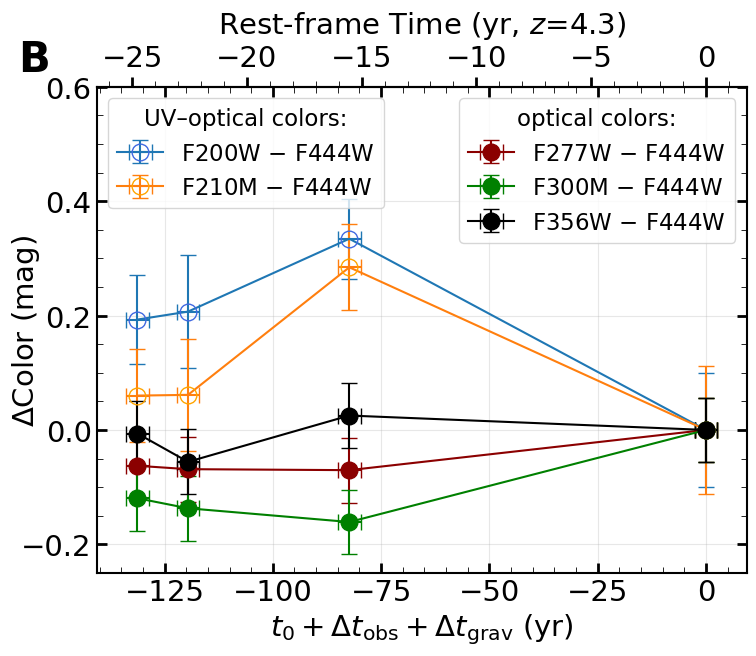

In [18]:
import matplotlib.pyplot as plt
import numpy as np
def nJy_to_ABmag(flux, flux_error):
    """
    将流量 (nJy) 转换为 AB 星等，并计算误差。
    
    参数:
        flux (float or np.ndarray): 流量值，单位为 nJy。
        flux_error (float or np.ndarray): 流量的误差，单位为 nJy。
    
    返回:
        tuple: 星等 (magnitude) 和星等误差 (magnitude_error)。
    """
    # 防止非正流量导致对数计算报错
    flux = np.array(flux)
    flux_error = np.array(flux_error)
    
    # 仅对 flux > 0 计算
    valid = flux > 0
    magnitude = np.full_like(flux, np.nan, dtype=np.float64)  # 默认 NaN
    magnitude_error = np.full_like(flux, np.nan, dtype=np.float64)  # 默认 NaN
    
    if np.any(valid):
        magnitude[valid] = -2.5 * np.log10(flux[valid]) + 31.4
        magnitude_error[valid] = 2.5 / np.log(10) * (flux_error[valid] / flux[valid])
    
    return magnitude, magnitude_error
color_pairs = [ ('F200W','F444W'), ('F210M','F444W'),('F277W','F444W'), ('F300M','F444W'), ('F356W','F444W')]
colors = ['royalblue', 'orange', 'darkred','green','black','blue']

shiftlist = [1., 1., 0, 0, 0, 0]
plt.figure(figsize=(8,7))

for (b1, b2), c, i in zip(color_pairs, colors, [0,1,2,3,4,5]):
    tdelay, tdelay_err, color_val, color_val_abs, color_err = [], [], [], [], []
    shift = shiftlist[i]
    for col in sel_tab:
        img_idx = int(col['ID_2'].split('.')[1]) 
        if(img_idx == 3):
            img_idx = 4
        elif(img_idx == 4):
            img_idx = 3 
        mu, mu_err, td, td_err = getlensing_para(9, img_idx)
        
        f1 = float(col[f'{b1}_CIRC1']) #/ abs(systems_data["system-1 (z=6.07)"]["images"][img_idx]["mu"])
        f2 = float(col[f'{b2}_CIRC1']) #/ abs(systems_data["system-1 (z=6.07)"]["images"][img_idx]["mu"])
        e1 = float(col[f'{b1}_CIRC1_e'])
        e2 = float(col[f'{b2}_CIRC1_e'])

        mag1, mag1err_arr = nJy_to_ABmag(f1, e1)
        mag2, mag2err_arr = nJy_to_ABmag(f2, e2)
        mag1err_arr = max(mag1err_arr, 0.04)
        mag2err_arr = max(mag2err_arr, 0.04)
        color = mag1 - mag2
        color_err_val = np.sqrt(mag1err_arr**2 + mag2err_arr**2)
        tdelay.append(td)
        tdelay_err.append(td_err)
        color_val.append(color)
        color_val_abs.append(np.abs(color))
        color_err.append(color_err_val)
    
    color_val_abs = np.array(color_val_abs)
    print((b1, b2))
    idmax = color_val_abs.argmax()

    # print(color_val_abs)
    
    # print(color_err)
    # print(max(color_val_abs / color_err))

    tdelay = np.array(tdelay)#/(1+z)
    tdelay_err = np.array(tdelay_err)#/(1+z)
    idx = np.argsort(tdelay)
    color_diff = np.array(color_val)[idx] - np.array(color_val)[idx][0]
    color_diff_err = np.sqrt(np.array(color_err)[idx]**2 + np.array(color_err)[idx][0]**2)
    # print(shift)
    val = max(np.abs(color_diff / color_diff_err))  # + rf'{val:.1f}$\sigma$',
    if(i >=2):
        plt.errorbar(-tdelay[idx]/365, color_diff , xerr = td_err/365, markersize = 12,
                 yerr=np.array(color_err)[idx],
                 fmt='o-', color=c, label=f'{b1} ' + r'$-$' + f' {b2}',  capsize=6)
    else:
        plt.errorbar(-tdelay[idx]/365, color_diff , xerr = td_err/365, markersize = 12, markerfacecolor='none', markeredgecolor=c,
                 yerr=np.array(color_err)[idx],
                 fmt='o-',  label=f'{b1} ' + r'$-$' + f' {b2}',  capsize=6)
    print(color_diff)
    print(max(np.abs(color_diff / color_diff_err)))
plt.xlabel(r"$t_0 + \Delta t_{\rm obs} + \Delta t_{\rm grav}$" + " (yr)")

def obs_to_rest(t_obs):
    return t_obs / (1 + z)
def rest_to_obs(t_rest):
    return t_rest * (1 + z)

secax = plt.gca().secondary_xaxis('top', functions=(obs_to_rest, rest_to_obs))
secax.set_xlabel(rf"Rest-frame Time (yr, $z$={z})")
secax.xaxis.labelpad = 8
secax.tick_params(which='both', direction='out', top=True, labeltop=True)
plt.text(-0.12, 1.1, 'B', color='k', fontsize=30, ha='left', va='top', weight='bold', transform=plt.gca().transAxes)

# plt.text(0.7, 0.05, r'R2211-RX1', fontsize = 18, transform=plt.gca().transAxes)
plt.ylabel(r'$\Delta$' + 'Color (mag)', labelpad = -15)
# plt.gca().invert_yaxis()
plt.ylim(-0.25,0.6)

# 获取当前图中的 handles 和 labels
handles, labels = plt.gca().get_legend_handles_labels()

uv_handles, uv_labels = [], []      # 空心（UV–optical）
opt_handles, opt_labels = [], []    # 实心（optical）

for h, l in zip(handles, labels):
    # errorbar 返回 ErrorbarContainer, 取 h.lines[0] 才是 marker 对象
    marker_obj = h.lines[0]

    # markerfacecolor == 'none' → hollow
    if marker_obj.get_markerfacecolor() == 'none':
        uv_handles.append(h)
        uv_labels.append(l)
    else:
        opt_handles.append(h)
        opt_labels.append(l)

# === Legend 1: UV–optical (hollow markers) ===
leg1 = plt.legend(uv_handles, uv_labels,
                  title="UV–optical colors:",
                  frameon=True, fontsize=16.5, title_fontsize=16.5,
                  loc="upper left")
plt.gca().add_artist(leg1)

# === Legend 2: Optical colors (solid markers) ===
plt.legend(opt_handles, opt_labels,
           title="optical colors:",
           frameon=True, fontsize=16.5, title_fontsize=16.5,
           loc="upper right")

# plt.legend(frameon=False, fontsize = 17, ncols = 1)
# plt.title('RX1 Color Variability')
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'RX1_colorvariability.pdf', dpi=200, bbox_inches='tight',pad_inches=0.2)
# plt.show()

F150W2-F322W2: chi2=0.34, dof=2, p=0.843
F200W-F356W: chi2=12.48, dof=2, p=0.002
F200W-F444W: chi2=12.09, dof=2, p=0.002
F277W-F444W: chi2=2.12, dof=2, p=0.347
F300M-F444W: chi2=9.20, dof=2, p=0.010
F356W-F444W: chi2=0.59, dof=2, p=0.745


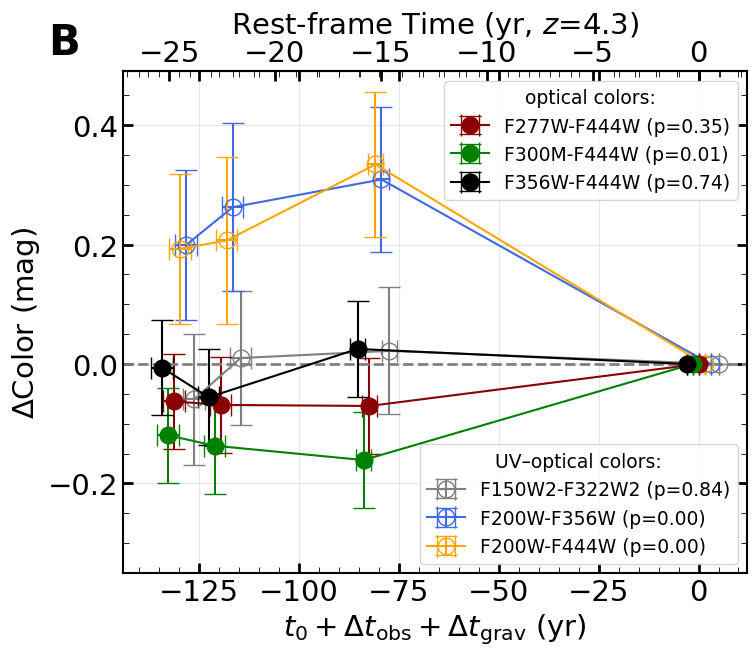

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2

def nJy_to_ABmag(flux, flux_error):
    flux = np.array(flux)
    flux_error = np.array(flux_error)

    valid = flux > 0
    magnitude = np.full_like(flux, np.nan, dtype=np.float64)
    magnitude_error = np.full_like(flux, np.nan, dtype=np.float64)

    if np.any(valid):
        magnitude[valid] = -2.5 * np.log10(flux[valid]) + 31.4
        magnitude_error[valid] = 2.5 / np.log(10) * (flux_error[valid] / flux[valid])

    return magnitude, magnitude_error


color_pairs = [
    ('F150W2','F322W2'),
    ('F200W','F356W'),
    ('F200W','F444W'),
    # ('F210M','F444W'),
    ('F277W','F444W'),
    ('F300M','F444W'),
    ('F356W','F444W')
]

colors = ['gray','royalblue', 'orange', 'darkred','green','black']
offsets = [5, 3, 1.5, 0, -1.5, -3]  # 可选：为不同颜色添加小的时间偏移，避免点重叠
plt.figure(figsize=(8,7))

for (b1, b2), c, offset, i in zip(color_pairs, colors, offsets, [0,1,2,3,4,5]):

    tdelay, tdelay_err = [], []
    color_val, color_err = [], []

    # ============================
    # 收集数据
    # ============================
    for col in sel_tab:
        img_idx = int(col['ID_2'].split('.')[1]) 

        if img_idx == 3:
            img_idx = 4
        elif img_idx == 4:
            img_idx = 3 

        mu, mu_err, td, td_err = getlensing_para(9, img_idx)

        # f1 = float(col[f'{b1}_CIRC1'])
        # f2 = float(col[f'{b2}_CIRC1'])
        # e1 = float(col[f'{b1}_CIRC1_e'])
        # e2 = float(col[f'{b2}_CIRC1_e'])
        f1 = float(col[f'{b1}_CIRC1'])
        f2 = float(col[f'{b2}_CIRC1'])
        e1 = float(col[f'{b1}_CIRC1_e'])
        e2 = float(col[f'{b2}_CIRC1_e'])        

        mag1, mag1err = nJy_to_ABmag(f1, e1)
        mag2, mag2err = nJy_to_ABmag(f2, e2)

        mag1err = max(mag1err, 0.04)
        mag2err = max(mag2err, 0.04)

        color = mag1 - mag2
        err = np.sqrt(mag1err**2 + mag2err**2)

        tdelay.append(td)
        tdelay_err.append(td_err)
        color_val.append(color)
        color_err.append(err)

    # 转 array
    tdelay = np.array(tdelay)
    tdelay_err = np.array(tdelay_err)
    color_val = np.array(color_val)
    color_err = np.array(color_err)

    # 排序（按时间）
    idx = np.argsort(tdelay)

    t = tdelay[idx]
    terr = tdelay_err[idx]
    cval = color_val[idx]
    cerr = color_err[idx]

    # ============================
    # 定义 reference（第一个点）
    # ============================
    ref_idx = 0
    ref_color = cval[ref_idx]
    ref_err = cerr[ref_idx]

    # ============================
    # color difference + 正确误差传播
    # ============================
    color_diff = cval - ref_color
    color_diff_err = np.sqrt(cerr**2 + ref_err**2)

    # 👉 关键：reference 点误差设为 0（只影响画图）
    color_diff_err_plot = color_diff_err.copy()
    color_diff_err_plot[ref_idx] = 0

    # ============================
    # ✅ χ²检验（排除 reference）
    # ============================
    chi2_val = np.sum((color_diff[1:] / color_diff_err[1:])**2)
    dof = len(color_diff) - 2
    p_value = 1 - chi2.cdf(chi2_val, dof)

    print(f"{b1}-{b2}: chi2={chi2_val:.2f}, dof={dof}, p={p_value:.3f}")

    # ============================
    # 画图
    # ============================
    if(i >=3):
        plt.errorbar(
        -t/365 + offset,
        color_diff,
        xerr=terr/365,
        yerr=color_diff_err_plot,   # ← 用 plot 用的误差
        fmt='o-',
        color=c,
        capsize=8, markersize = 12,
        label=f'{b1}-{b2} (p={p_value:.2f})'
    )
    else:
        plt.errorbar(
        -t/365 + offset,
        color_diff,
        xerr=terr/365,
        yerr=color_diff_err_plot,   # ← 用 plot 用的误差
        fmt='o-',
        color=c,
        capsize=8,  markersize = 12, markerfacecolor = 'none', markeredgecolor = c,
        label=f'{b1}-{b2} (p={p_value:.2f})')


# ============================
# 坐标轴
# ============================
plt.xlabel(r"$t_0 + \Delta t_{\rm obs} + \Delta t_{\rm grav}$ (yr)")

def obs_to_rest(t_obs):
    return t_obs / (1 + z)

def rest_to_obs(t_rest):
    return t_rest * (1 + z)

secax = plt.gca().secondary_xaxis('top', functions=(obs_to_rest, rest_to_obs))
secax.set_xlabel(rf"Rest-frame Time (yr, $z$={z})")


# 获取当前图中的 handles 和 labels
handles, labels = plt.gca().get_legend_handles_labels()

uv_handles, uv_labels = [], []      # 空心（UV–optical）
opt_handles, opt_labels = [], []    # 实心（optical）

for h, l in zip(handles, labels):
    # errorbar 返回 ErrorbarContainer, 取 h.lines[0] 才是 marker 对象
    marker_obj = h.lines[0]
    # markerfacecolor == 'none' → hollow
    if marker_obj.get_markerfacecolor() == 'none':
        uv_handles.append(h)
        uv_labels.append(l)
    else:
        opt_handles.append(h)
        opt_labels.append(l)

# === Legend 1: UV–optical (hollow markers) ===
leg1 = plt.legend(uv_handles, uv_labels,
                  title="UV–optical colors:",
                  frameon=True, fontsize=13.5, title_fontsize=13.5,ncols = 1,
                  loc="lower right")
plt.gca().add_artist(leg1)

# === Legend 2: Optical colors (solid markers) ===
plt.legend(opt_handles, opt_labels,
           title="optical colors:",
           frameon=True, fontsize=13.5, title_fontsize=13.5,
           loc="upper right")
plt.axhline(0, color='gray', ls='--', lw=2)
plt.ylabel(r'$\Delta$Color (mag)')
plt.ylim(-0.35,0.49)
# plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.text(-0.12, 1.1, 'B', color='k', fontsize=30, ha='left', va='top', weight='bold', transform=plt.gca().transAxes)
plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'RX1_colorvariability.pdf', dpi=200, bbox_inches='tight',pad_inches=0.2)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# -------------------------
# 配置（可修改）
# -------------------------
band_name = 'F300M'
fit_M = False          # 是否拟合 M
tie_phase = True      # ✅ 是否将三个相位绑在一起
n_components = 3      # ✅ 使用的正弦分量数（1, 2, 或 3）
M_fixed = 10**7.28

two_pi = 2.0 * np.pi

A_max_guess = 1.0
phase_guess = 0.0
M_guess = 4e6
# -------------------------
# 从 sel_tab 中提取 t (yr), mag, mag_err
# 注意：脚本假设 sel_tab 中列名有 'f_F300M' 和 'e_F300M' 或类似命名，
# 并且你之前计算 mag_corr 的方法与聊天中一致（使用 mu 校正并转成 mag）。
# 如果你已经有单独的 arrays（t_mag, mag, mag_err），可以直接跳到 "拟合" 部分。
# -------------------------
def extract_band_from_table(sel_tab, band_name):
    """返回 t_years, mag_corr_array, mag_err_array
    sel_tab: 可迭代，每个元素像 dict 或 astropy row，有 'ID_2', 'f_<band>', 'e_<band>' 等
    """
    mags = []
    errs = []
    tdelays = []
    for i, col in enumerate(sel_tab):
        # 兼容你的 ID_2 处理（把 'x.3' 和 'x.4' 互换）
        img_idx = int(col['ID_2'].split('.')[1])
        if img_idx == 3:
            img_idx = 4
        elif img_idx == 4:
            img_idx = 3
        mu, mu_err, td, td_err = getlensing_para(9, img_idx)  # 你原来使用的函数
        
        # 取观测 flux 和 error（根据你原来的代码）
        f_key = 'f_' + band_name
        e_key = 'e_' + band_name

        f_obs = float(col[f_key])
        f_err_obs = float(col[e_key])
        f_err_obs = max(f_err_obs, 0.04 * abs(f_obs)) / np.abs(mu)
        f_corr = f_obs / np.abs(mu)
        # mag_corr = 31.4 - 2.5 * np.log10(np.abs(f_corr))
        # # 误差传播：和你原来一致
        # mag_err = np.sqrt((2.5/np.log(10) * f_err_obs / f_obs)**2 +
        #                   (2.5/np.log(10) * mu_err / np.abs(mu))**2)
        # mags.append(mag_corr)
        # errs.append(mag_err)
        mags.append(f_corr)
        errs.append(f_err_obs)
        tdelays.append(td/365.0)  # 你脚本里把 td 除以 365 -> 年
    return np.array(tdelays), np.array(mags), np.array(errs)

# 如果你已手动准备好 arrays，可直接赋值 t_obs_years, mag, mag_err
t_obs_years, mag_obs, mag_err = extract_band_from_table(sel_tab, band_name)
# 使用 -tdelay（与你绘图一致）
t_data = -t_obs_years/(1+4.3)

# -------------------------
# 模型定义
# -------------------------
def periods_from_M(M, f_vals, T = 5000):
    return 38.0 * f_vals * (M / 1e6)**0.25 * (T/5000)**(-3)

def model_mag(params, t, fit_M, tie_phase):
    """
    根据 tie_phase 自动切换参数结构:
      tie_phase=False:
         [m0, A0, A1, A2, phi0, phi1, phi2, (log10M)]
      tie_phase=True:
         [m0, A0, A1, A2, phi, (log10M)]
    """
    m0 = params[0]
    A = np.array(params[1:4])

    if tie_phase:
        phi = np.array([params[4]] * 3)
        offset = 5
    else:
        phi = np.array(params[4:7])
        offset = 7

    if fit_M:
        log10M = params[offset]
        M = 10.0**log10M
    else:
        M = M_fixed

    T = periods_from_M(M, f_vals)
    print(T)
    model = m0 + np.sum([A[n] * np.sin(two_pi * t / T[n] + phi[n]) for n in range(3)], axis=0)
    return model



def residuals(params, t, y, yerr, fit_M, tie_phase):
    return (y - model_mag(params, t, fit_M, tie_phase)) / yerr

# -------------------------
# 初始猜测与边界
# -------------------------
m0_guess = np.nanmean(mag_obs)
A_guess = [2, 2, 2]
phi_guess = 0.0
log10M_guess = np.log10(M_guess)

if tie_phase:
    # 相位统一
    if fit_M:
        p0 = [m0_guess] + A_guess + [phi_guess, log10M_guess]
        lower = [m0_guess - 5] + [0]*3 + [-2*np.pi] + [3.0]
        upper = [m0_guess + 5] + [50]*3 + [2*np.pi] + [9.0]
    else:
        p0 = [m0_guess] + A_guess + [phi_guess]
        lower = [m0_guess - 5] + [0]*3 + [-2*np.pi]
        upper = [m0_guess + 5] + [50]*3 + [2*np.pi]
else:
    # 相位独立
    if fit_M:
        p0 = [m0_guess] + A_guess + [0.0, 0.0, 0.0] + [log10M_guess]
        lower = [m0_guess - 5] + [0]*3 + [-2*np.pi]*3 + [3.0]
        upper = [m0_guess + 5] + [50]*3 + [2*np.pi]*3 + [9.0]
    else:
        p0 = [m0_guess] + A_guess + [0.0, 0.0, 0.0]
        lower = [m0_guess - 5] + [0]*3 + [-2*np.pi]*3
        upper = [m0_guess + 5] + [50]*3 + [2*np.pi]*3

# -------------------------
# 拟合
# -------------------------
res = least_squares(
    residuals, p0, args=(t_data, mag_obs, mag_err, fit_M, tie_phase),
    bounds=(lower, upper), verbose=2
)

popt = res.x
dof = len(mag_obs) - len(popt)
chi2 = np.sum(((mag_obs - model_mag(popt, t_data, fit_M, tie_phase)) / mag_err)**2)
chi2_red = chi2 / max(1, dof)

# -------------------------
# 打印结果
# -------------------------
if tie_phase:
    param_names = ['m0','A0','A1','A2','phi'] + (['log10M'] if fit_M else [])
else:
    param_names = ['m0','A0','A1','A2','phi0','phi1','phi2'] + (['log10M'] if fit_M else [])

print("\nFit results:")
for name, val in zip(param_names, popt):
    print(f" {name:7s} = {val:10.5f}")

print(f"\nchi2_red = {chi2_red:.3f}")

if fit_M:
    M_fit = 10**popt[-1]
    print(f"Fitted M = {M_fit:.3e} M_sun")
else:
    M_fit = M_fixed

# -------------------------
# 绘图
# -------------------------
t_plot = np.linspace(np.min(t_data)-0.2, np.max(t_data)+0.2, 600)
y_model = model_mag(popt, t_plot, fit_M, tie_phase)

plt.figure(figsize=(9,5))
plt.errorbar(t_data, mag_obs, yerr=mag_err, fmt='o', capsize=3, label='data')
plt.plot(t_plot, y_model, 'k-', lw=2, label=f'model total (log M = {np.log10(M_fit):.2f})')

# 各分量
m0 = popt[0]
A = popt[1:4]
if tie_phase:
    phi = np.array([popt[4]] * 3)
else:
    phi = np.array(popt[4:7])
T_used = periods_from_M(M_fit, f_vals)

for n in range(3):
    plt.plot(t_plot, m0 + A[n]*np.sin(two_pi*t_plot/T_used[n] + phi[n]),
             '--', lw=1.5, label=f'mode n={n}, T={T_used[n]:.2f} yr')



plt.xlabel("Time (yr)")
plt.ylabel(f"{band_name} Flux")
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'f_vals' is not defined

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.2641e+01                                    1.88e+01    
       1              2         3.0215e+01      2.43e+00       9.40e-01       5.34e+01    
       2              3         2.5139e+01      5.08e+00       3.48e+00       5.16e+01    
       3              5         2.3081e+01      2.06e+00       1.83e+00       4.67e+01    
       4              6         1.9323e+01      3.76e+00       3.73e+00       3.43e+01    
       5              8         1.8082e+01      1.24e+00       1.68e+00       3.24e+01    
       6              9         1.6632e+01      1.45e+00       1.62e+00       2.58e+01    
       7             10         1.5508e+01      1.12e+00       3.28e+00       4.51e+01    
       8             11         1.2587e+01      2.92e+00       3.13e+00       2.41e+01    
       9             12         1.1199e+01      1.39e+00       6.13e+00       7.11e+01    

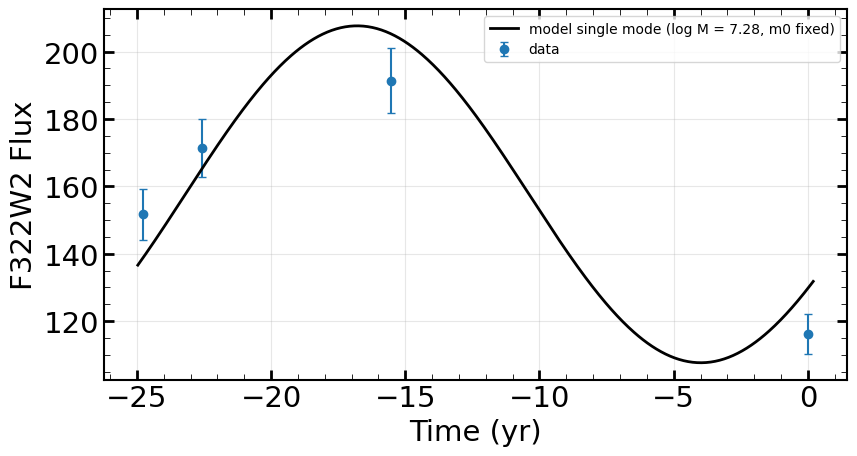

In [21]:
# -------------------------
# 模型定义（单模式，m0固定）
# -------------------------
def model_mag_single(params, t, fit_M, T = 5000):
    """
    单模式正弦模型 (m0固定为中位数)
      params = [A, phi, (log10M)]
    """
    A, phi = params[:2]
    m0 = np.mean(mag_obs)  # 固定为中位数

    if fit_M:
        log10M = params[2]
        M = 10.0**log10M
    else:
        M = M_fixed

    T = periods_from_M(M, np.array([f_vals[0]]), T=T)[0]
    return m0 + A * np.sin(two_pi * t / T + phi)

def get_model_mag_single(params, t, m0, fit_M, T = 5000):
    """
    单模式正弦模型 (m0固定为中位数)
      params = [A, phi, (log10M)]
    """
    A, phi = params[:2]

    if fit_M:
        log10M = params[2]
        M = 10.0**log10M
    else:
        M = M_fixed

    T = periods_from_M(M, np.array([f_vals[0]]), T=T)[0]
    # print(T)
    return m0 + A * np.sin(two_pi * t / T + phi)

def residuals_single(params, t, y, yerr, fit_M, T = 4000):
    return (y - model_mag_single(params, t, fit_M, T = 5000)) / yerr


# -------------------------
# 初始猜测与边界（m0固定）
# -------------------------
A_guess = 2.0
phi_guess = 0.0
log10M_guess = np.log10(M_guess)

band_name = 'F322W2'
fit_M = False          # 是否拟合 M
tie_phase = True      # ✅ 是否将三个相位绑在一起
n_components = 1     # ✅ 使用的正弦分量数（1, 2, 或 3）
M_fixed = 10**7.28
temperature = 5000
f_vals = np.array([0.3226, 0.27, 0.20])
two_pi = 2.0 * np.pi

A_max_guess = 1.0
phase_guess = 0.0
M_guess = 4e6


# 如果你已手动准备好 arrays，可直接赋值 t_obs_years, mag, mag_err
t_obs_years, mag_obs, mag_err = extract_band_from_table(sel_tab, band_name)
# 使用 -tdelay（与你绘图一致）
t_data = -t_obs_years/(1+4.3)
if fit_M:
    p0 = [A_guess, phi_guess, log10M_guess]
    lower = [0, -2*np.pi, 3.0]
    upper = [50, 2*np.pi, 9.0]
else:
    p0 = [A_guess, phi_guess]
    lower = [0, -2*np.pi]
    upper = [50, 2*np.pi]

# -------------------------
# 拟合
# -------------------------
mag_obs_ = mag_obs.copy()
res = least_squares(
    residuals_single, p0, args=(t_data, mag_obs_, mag_err, fit_M, temperature),
    bounds=(lower, upper), verbose=2
)
popt = res.x

dof = len(mag_obs_) - len(popt)
chi2 = np.sum(((mag_obs_ - model_mag_single(popt, t_data, fit_M, temperature)) / mag_err)**2)
chi2_red = chi2 / max(1, dof)


# -------------------------
# 打印结果
# -------------------------
param_names = ['A', 'phi'] + (['log10M'] if fit_M else [])
print("\nFit results (m0 fixed):")
for name, val in zip(param_names, popt):
    print(f" {name:7s} = {val:10.5f}")

m0_fixed = np.mean(mag_obs)
print(f" Fixed m0 = {m0_fixed:.5f}")

if fit_M:
    M_fit = 10**popt[2]
    print(f" Fitted M = {M_fit:.3e} M_sun")
else:
    M_fit = M_fixed

print(f"\nchi2_red = {chi2_red:.3f}")


# -------------------------
# 绘图
# -------------------------
t_plot = np.linspace(np.min(t_data)-0.2, np.max(t_data)+0.2, 600)
y_model = model_mag_single(popt, t_plot, fit_M, temperature)

plt.figure(figsize=(9,5))
plt.errorbar(t_data, mag_obs_, yerr=mag_err, fmt='o', capsize=3, label='data')
plt.plot(t_plot, y_model, 'k-', lw=2,
         label=f'model single mode (log M = {np.log10(M_fit):.2f}, m0 fixed)')
plt.xlabel("Time (yr)")
plt.ylabel(f"{band_name} Flux")
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


-------------------------------------------------
数据合并完成：原始 4 点, 新增 4 点。
总数据点数: 8
-------------------------------------------------

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.2132e+01                                    5.14e+01    
       1              2         8.5495e+01      6.64e+00       9.36e-01       1.46e+02    
       2              3         7.1572e+01      1.39e+01       3.48e+00       1.42e+02    
       3              5         6.5914e+01      5.66e+00       1.84e+00       1.28e+02    
       4              6         5.5605e+01      1.03e+01       3.73e+00       9.42e+01    
       5              8         5.2209e+01      3.40e+00       1.67e+00       8.89e+01    
       6              9         4.8245e+01      3.96e+00       1.61e+00       7.08e+01    
       7             10         4.5334e+01      2.91e+00       3.27e+00       1.26e+02    
       8             11         3.7201e+01     

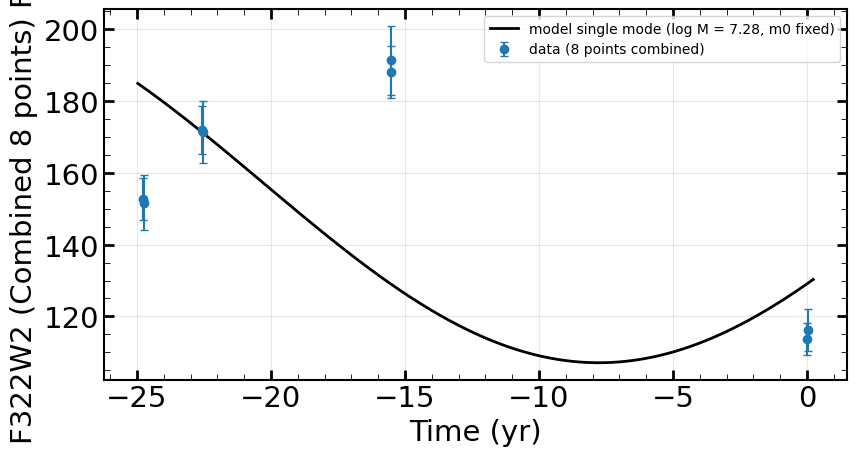

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares



# -------------------------------------------------
# 1. 数据提取与合并 (核心修改部分)
# -------------------------------------------------

# 提取原始F322W2数据 (4个点)
t_obs_1, mag_obs_1, mag_err_1 = extract_band_from_table(sel_tab, 'F322W2')

# 提取F277W数据 (另外4个点)
t_obs_2, mag_obs_2, mag_err_2 = extract_band_from_table(sel_tab, 'F277W')

# 提取F356W数据 (必须与F277W同时观测)
t_obs_3, mag_obs_3, mag_err_3 = extract_band_from_table(sel_tab, 'F356W')

t_obs_1 = t_obs_1 - 1/(5.3)
# 检查F277W和F356W的观测时间是否一致
if not np.array_equal(t_obs_2, t_obs_3):
    print("警告: F277W 和 F356W 的观测时间 (t_obs) 不匹配。")
    # 这里可以根据需要进行插值或报错，但根据您的描述，它们应该是同一批epoch
    # 暂且假设 t_obs_2 是正确的观测时间
    
# --- 核心计算 ---
# 1. 将F277W和F356W的通量相加，得到新的 F322W2 通量
mag_obs_new = (mag_obs_2 + mag_obs_3)/2

# 2. 
# 合并误差 (平方和开方)
# mag_err_new = np.sqrt(mag_err_2**2 + mag_err_3**2)
mag_err_new = 0.5 * np.sqrt(mag_err_2**2 + mag_err_3**2)

# 3. 合并所有数据
# 假设 F277W/F356W 的观测时间用 t_obs_2
t_obs_years = np.concatenate((t_obs_1, t_obs_2))
mag_obs = np.concatenate((mag_obs_1, mag_obs_new))
mag_err = np.concatenate((mag_err_1, mag_err_new))

print("\n-------------------------------------------------")
print(f"数据合并完成：原始 {len(t_obs_1)} 点, 新增 {len(t_obs_2)} 点。")
print(f"总数据点数: {len(t_obs_years)}")
print("-------------------------------------------------\n")


# -------------------------
# 2. 模型定义（单模式，m0固定）
# (这部分来自您的代码，但 m0 = np.mean(mag_obs) 现在将使用合并后的8点数据)
# -------------------------

# 定义拟合所需的全局常量
f_vals = np.array([0.3226, 0.27, 0.20])
two_pi = 2.0 * np.pi
M_fixed = 10**7.28 # 仅在 fit_M = False 时使用
Temperature = 4000
# -------------------------
# 3. 初始猜测与边界（m0固定）
# -------------------------
A_guess = 2.0
phi_guess = 0.0
M_guess = 4e6
log10M_guess = np.log10(M_guess)

band_name = 'F322W2 (Combined 8 points)' # 更新波段名称
fit_M = False      # 是否拟合 M
# M_fixed = 10**7.38 # 已在前面定义

# 您的代码中 tie_phase 和 n_components 在单模式拟合中未使用，故注释掉
# tie_phase = True   
# n_components = 1 

# A_max_guess = 1.0
# phase_guess = 0.0

# 使用 -tdelay（与你绘图一致）
# 注意：t_obs_years, mag_obs, mag_err 已经是合并后的8点数据
t_data = -t_obs_years/(1+4.3)

if fit_M:
    p0 = [A_guess, phi_guess, log10M_guess]
    lower = [0, -2*np.pi, 3.0]
    upper = [50, 2*np.pi, 9.0]
else:
    p0 = [A_guess, phi_guess]
    lower = [0, -2*np.pi]
    upper = [50, 2*np.pi]

# -------------------------
# 4. 拟合
# -------------------------
# mag_obs_ 是 mag_obs 的副本 (现在是8个点)
mag_obs_ = mag_obs.copy() 
res = least_squares(
    residuals_single, p0, args=(t_data, mag_obs_, mag_err, fit_M, Temperature),
    bounds=(lower, upper), verbose=2
)
popt = res.x

dof = len(mag_obs_) - len(popt)
chi2 = np.sum(((mag_obs_ - model_mag_single(popt, t_data, fit_M, Temperature)) / mag_err)**2)
chi2_red = chi2 / max(1, dof)


# -------------------------
# 5. 打印结果
# -------------------------
param_names = ['A', 'phi'] + (['log10M'] if fit_M else [])
print("\nFit results (m0 fixed):")
for name, val in zip(param_names, popt):
    print(f" {name:7s} = {val:10.5f}")

# 这里的 m0_fixed 会使用全局的8点 mag_obs 数组
m0_fixed = np.mean(mag_obs)
print(f" Fixed m0 = {m0_fixed:.5f} (mean of {len(mag_obs)} points)")

if fit_M:
    M_fit = 10**popt[2]
    print(f" Fitted M = {M_fit:.3e} M_sun")
else:
    M_fit = M_fixed
    print(f" Fixed M = {M_fit:.3e} M_sun")


print(f"\nchi2_red = {chi2_red:.3f} (dof = {dof})")


# -------------------------
# 6. 绘图
# -------------------------
t_plot = np.linspace(np.min(t_data)-0.2, np.max(t_data)+0.2, 600)
y_model = model_mag_single(popt, t_plot, fit_M, Temperature)

plt.figure(figsize=(9,5))

# 绘制合并后的8个点
plt.errorbar(t_data, mag_obs_, yerr=mag_err, fmt='o', capsize=3, label='data (8 points combined)')

# # (可选) 绘制原始数据点以作区分
# t_data_1 = -t_obs_1/(1+4.3)
# t_data_2 = -t_obs_2/(1+4.3)
# plt.errorbar(t_data_1, mag_obs_1, yerr=mag_err_1, fmt='o', capsize=3, label='F322W2 (original)')
# plt.errorbar(t_data_2, mag_obs_new, yerr=mag_err_new, fmt='s', capsize=3, label='F277W + F356W')


plt.plot(t_plot, y_model, 'k-', lw=2,
         label=f'model single mode (log M = {np.log10(M_fit):.2f}, m0 fixed)')
plt.xlabel("Time (yr)")
plt.ylabel(f"{band_name} Flux")
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.1274e+02                                    1.33e+03    
       1              2         1.9211e+02      5.21e+02       1.31e+02       5.31e+02    
       2              3         6.9094e+01      1.23e+02       5.99e+01       1.95e+03    
       3              4         2.5781e+01      4.33e+01       2.72e+01       1.28e+03    
       4              5         3.0336e+00      2.27e+01       2.18e+01       1.93e+02    
       5              6         2.4128e+00      6.21e-01       3.75e+00       1.12e+01    
       6              7         2.4115e+00      1.31e-03       2.85e-01       6.71e-03    
       7              8         2.4115e+00      1.13e-09       1.32e-04       1.31e-05    
`ftol` termination condition is satisfied.
Function evaluations 8, initial cost 7.1274e+02, final cost 2.4115e+00, first-order optimality 1.31e-05.
Fit parameters (order: A1, phi1, 

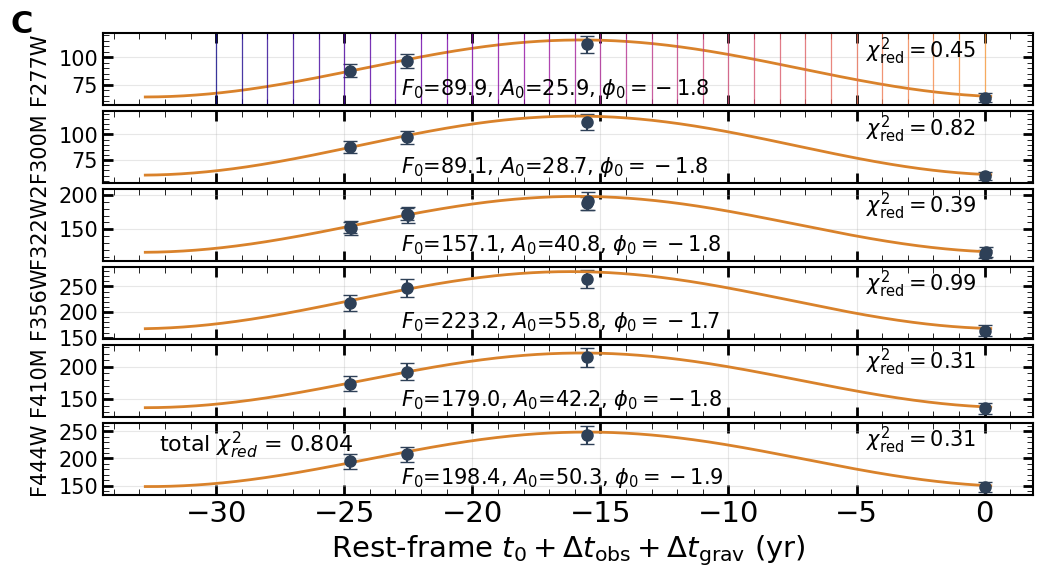

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ---------- 用户需要的设置 ----------  # 'F200W','F210M',  
bands = ['F277W','F300M','F322W2', 'F356W','F410M','F444W']  # 要联合拟合的 bands
# bands = ['F090W', 'F115W', 'F150W', 'F200W' , 'F210M', 'F277W','F300M','F322W2', 'F356W','F410M','F444W']  # 要联合拟合的 bands
fit_M = False          # 是否把 log10M 当作自由参数拟合
M_fixed = 10**6.28    
f_vals = np.array([0.3226, 0.27, 0.20])
two_pi = 2.0 * np.pi
Temperature = 3750
T_period = 30#periods_from_M(M_fixed, np.array([f_vals[0]]))[0]
t_grid = np.linspace(0, T_period, int(T_period) + 1) - T_period   # 40个时刻
# ---------- 从 sel_tab 构造每个 band 的 (t, flux, flux_err) ----------
import numpy as np

# 假设 getlensing_para 函数已经定义在别处
# def getlensing_para(9, img_idx):
#     ...
#     return mu, mu_err, td, td_err
colors = plt.cm.plasma(np.linspace(0, 1, 40))

def build_band_arrays(band_list, sel_tab):
    """
    修改后的函数：
    如果 band_list 中包含 'F322W2', 
    将自动提取 'F277W' 和 'F356W' 的数据,
    并按 (F277W + F356W) / 2 的规则合并，
    最终输出8个点的 'F322W2' 数据。
    """
    # 1. 确定我们需要抓取哪些波段的数据
    bands_to_extract = set(band_list)
    if 'F322W2' in bands_to_extract:
        bands_to_extract.add('F277W')
        bands_to_extract.add('F356W')

    # 临时存储所有抓取到的数据
    temp_storage = {}
    # 2. 遍历所有需要抓取的波段
    for band in bands_to_extract:
        flux_list = []
        err_list = []
        tdelay_list = []
        # 遍历 sel_tab 中的所有 epoch
        for i, col in enumerate(sel_tab):
            # 复用你原来的 image index 交换逻辑
            img_idx = int(col['ID_2'].split('.')[1])
            if(img_idx == 3):
                img_idx = 4
            elif(img_idx == 4):
                img_idx = 3

            mu, mu_err, td, td_err = getlensing_para(9, img_idx)
            # mu_err = np.max([0.1 * mu, mu_err])

            # --- [修改] 安全地提取流量数据 ---
            f_obs_str = 'f_' + band
            f_err_obs_str = 'e_' + band
            
            # 使用 .get() 避免 KeyError
            f_obs = col.get(f_obs_str)
            f_err_obs = col.get(f_err_obs_str)

            # 检查数据是否有效 (处理 None 或 "nan" 字符串)
            try:
                f_obs = float(f_obs)
                f_err_obs = float(f_err_obs)
            except (ValueError, TypeError):
                continue # 跳过这个 epoch, 因为没有这个 band 的数据
            
            # 检查是否为 NaN
            if np.isnan(f_obs) or np.isnan(f_err_obs):
                continue # 跳过这个 epoch, 因为数据是 NaN
            # --- [修改] 结束 ---
            f_err_obs = max(f_err_obs, 0.04 * f_obs)   # 保证下限 (遵照原代码注释掉)
            # flux 校正（原始 flux / |mu|）
            f_corr = f_obs / np.abs(mu)
            # flux uncertainty propagate: combine measurement 和 mu 不确定度
            f_corr_err = np.sqrt((f_err_obs / np.abs(mu))**2 +
                                 (f_obs / (np.abs(mu)**2) * mu_err)**2)
            
            flux_list.append(f_corr)
            err_list.append(f_corr_err)
            tdelay_list.append(td) # 记录这个 epoch 的 tdelay

        # 转换为 array
        flux_arr = np.array(flux_list, dtype=float)
        err_arr = np.array(err_list, dtype=float)
        # 转成年 (注意：这里我们假设 F322W2 的4个点和 F277/F356 的4个点有各自的 tdelay)
        t_arr = np.array(tdelay_list, dtype=float) / 365.0

        # 存入临时字典
        temp_storage[band] = dict(t=t_arr, flux=flux_arr, ferr=err_arr)

    # 3. 构建最终的 band_data, 处理 F322W2 合并
    band_data = {}
    for band in band_list:
        if band == 'F322W2':
            # --- [新增] F322W2 合并逻辑 ---
            # 提取原始的4个 F322W2 点
            t_1 = temp_storage['F322W2']['t']
            flux_1 = temp_storage['F322W2']['flux']
            ferr_1 = temp_storage['F322W2']['ferr']
            
            # 提取 F277W 的4个点
            t_2 = temp_storage['F277W']['t']
            flux_2 = temp_storage['F277W']['flux']
            ferr_2 = temp_storage['F277W']['ferr']
            
            # 提取 F356W 的4个点
            t_3 = temp_storage['F356W']['t']
            flux_3 = temp_storage['F356W']['flux']
            ferr_3 = temp_storage['F356W']['ferr']
            
            # 检查 F277W 和 F356W 的观测时间是否一致
            if not np.array_equal(t_2, t_3):
                print(f"警告: F277W 和 F356W 的观测时间 (t_arr) 不匹配。")
                # 假设 t_2 是我们要使用的时间戳
            
            # 1. 计算新的通量密度 (求平均)
            flux_new = (flux_2 + flux_3) / 2.0
            
            # 2. 计算新的误差
            # sigma_new = 0.5 * sqrt(sigma_2^2 + sigma_3^2)
            ferr_new = 0.5 * np.sqrt(ferr_2**2 + ferr_3**2)
            
            # 3. 合并所有数据 (t_1 + t_2, flux_1 + flux_new, ferr_1 + ferr_new)
            t_combined = np.concatenate((t_1 - 0.2, t_2))
            flux_combined = np.concatenate((flux_1, flux_new))
            ferr_combined = np.concatenate((ferr_1, ferr_new))
            
            # 存入最终的 band_data
            band_data['F322W2'] = {
                't': t_combined,
                'flux': flux_combined,
                'ferr': ferr_combined
            }
            # --- [新增] 逻辑结束 ---
        
        else:
            # 对于其他波段 (e.g., 'F277W', 'F444W'等)，直接从 temp_storage 复制
            if band in temp_storage:
                band_data[band] = temp_storage[band]
                
    return band_data

band_data = build_band_arrays(bands, sel_tab)

# ---------- 构造联合拟合的模型 ----------
# 参数向量 p 结构: [A1, phi1, A2, phi2, ..., (log10M if fit_M)]
def model_joint(p, t_all, band_idx_all, band_list, band_data, fit_M, Temp):
    """
    t_all: concatenated times for all points (yr), in the same order as band_idx_all
    band_idx_all: array of same length as t_all, gives the band index (0..Nb-1) for each point
    """
    Nb = len(band_list)
    # 解读参数
    A = p[0:2*Nb:2]      # A_i at positions 0,2,4,...
    phi = p[1:2*Nb:2]    # phi_i at positions 1,3,5,...
    if fit_M:
        log10M = p[-1]
        M = 10.0**log10M
    else:
        M = M_fixed

    # 由 M 计算周期 T（使用你原来的 periods_from_M）
    T = periods_from_M(M, np.array([f_vals[0]]), Temp)[0]
    # print(T)
    y_model = np.empty_like(t_all)
    for j, band in enumerate(band_list):
        # m0 固定为该 band 的均值（flux space）
        m0 = np.nanmean(band_data[band]['flux'])
        # 取出属于该 band 的样本索引
        sel = (band_idx_all == j)
        if np.any(sel):
            tsel = t_all[sel]
            y_model[sel] = m0 + A[j] * np.sin(two_pi * tsel / T + phi[j])
    return y_model

def residuals_joint(p, t_all, y_all, yerr_all, band_idx_all, band_list, band_data, fit_M, Temp):
    return (y_all - model_joint(p, t_all, band_idx_all, band_list, band_data, fit_M, Temp)) / yerr_all

# ---------- 准备拼接数据供拟合 ----------
t_concat = []
y_concat = []
yerr_concat = []
band_idx_concat = []

for ib, band in enumerate(bands):
    d = band_data[band]
    # 与绘图逻辑保持一致：使用 -tdelay/(1+z)
    t_points = - d['t'] / (1.0 + z)
    t_concat.append(t_points)
    y_concat.append(d['flux'])
    yerr_concat.append(d['ferr'])
    band_idx_concat.append(np.full_like(t_points, ib, dtype=int))

t_all = np.concatenate(t_concat)
y_all = np.concatenate(y_concat)
yerr_all = np.concatenate(yerr_concat)
band_idx_all = np.concatenate(band_idx_concat)

# ---------- 初始猜测与边界 ----------
Nb = len(bands)
p0 = []
lower = []
upper = []
# 给每个 band 的 A 和 phi 初始猜测
for band in bands:
    A_guess = 0.5 * np.nanmax(band_data[band]['flux'])  # 一个保守的初值（可调整）
    phi_guess = 0.0
    p0 += [A_guess, phi_guess]
    lower += [0.0, -2*np.pi]
    upper += [np.nanmax(band_data[band]['flux'])*10.0 + 1e-12, 2*np.pi]  # A 上界设得较大

if fit_M:
    log10M_guess = np.log10(M_fixed)
    p0 += [log10M_guess]
    lower += [3.0]
    upper += [9.0]

p0 = np.array(p0)
bounds = (np.array(lower), np.array(upper))

# ---------- 执行拟合 ----------
res = least_squares(
    residuals_joint, p0,
    args=(t_all, y_all, yerr_all, band_idx_all, bands, band_data, fit_M, Temperature),
    bounds=bounds, verbose=2
)
popt = res.x

# ---------- 计算各 band 的 chi2 和 总体 chi2 ----------
# 计算模型并按 band 划分残差
y_fit_all = model_joint(popt, t_all, band_idx_all, bands, band_data, fit_M, Temperature)
resid_all = (y_all - y_fit_all) / yerr_all
chi2_total = np.sum(resid_all**2)
dof_total = len(y_all) - len(popt) - len(bands) - 4  # F322W2 band的数据点不是独立的
chi2_red_total = chi2_total / max(1, dof_total)

# 每个 band 的 chi2
chi2_per_band = {}
for ib, band in enumerate(bands):
    sel = (band_idx_all == ib)
    if np.any(sel):
        r = resid_all[sel]
        chi2_b = np.sum(r**2)
        dof_b = np.sum(sel) - 3  # 每 band 拟合了 A 和 phi (m0 固定)
        chi2_per_band[band] = dict(chi2=chi2_b, dof=dof_b, chi2_red=chi2_b / max(1, dof_b))
    else:
        chi2_per_band[band] = dict(chi2=np.nan, dof=0, chi2_red=np.nan)

# ---------- 打印结果 ----------
print("Fit parameters (order: A1, phi1, A2, phi2, ...{}):".format(", log10M" if fit_M else ""))
for ib, band in enumerate(bands):
    A_val = popt[2*ib]
    phi_val = popt[2*ib+1]
    print(f" {band:6s}  A = {A_val:.5e} , phi = {phi_val:.5f}")
if fit_M:
    print(f" fitted M = 10**{popt[-1]:.5f} = {10**popt[-1]:.3e} M_sun")

print(f"\nTotal chi2 = {chi2_total:.3f}, dof = {dof_total}, chi2_red = {chi2_red_total:.3f}")
for band in bands:
    print(f" {band:6s}  chi2 = {chi2_per_band[band]['chi2']:.3f}, dof = {chi2_per_band[band]['dof']}, chi2_red = {chi2_per_band[band]['chi2_red']:.3f}")

# ---------- 绘图：每个 band 单独子图（数据 + 拟合曲线），并在顶部写总体 chi2 ----------
n_panels = len(bands)
fig, axes = plt.subplots(n_panels, 1, figsize=(12, 1. * n_panels), sharex=True)
plt.subplots_adjust(hspace=0.08)

if n_panels == 1:
    axes = [axes]

t_plot = np.linspace(np.min(t_all)-8, np.max(t_all)+0.2, 800)

for ib, band in enumerate(bands):
    ax = axes[ib]
    d = band_data[band]
    t_pts = - d['t'] / (1.0 + z)
    y_pts = d['flux']
    yerr_pts = d['ferr']

    # 绘制数据点（原始顺序）
    idx_sort = np.argsort(t_pts)
    ax.errorbar(t_pts[idx_sort], y_pts[idx_sort], yerr=yerr_pts[idx_sort], color = '#2E4057', fmt='o', markersize=8, capsize=5)

    # 模型曲线（m0 固定）
    # 为绘图取出该 band 在 p 中的参数
    f0 = np.nanmean(band_data[band]['flux'])
    A_fit = popt[2*ib]
    phi_fit = popt[2*ib+1]
    if fit_M:
        M_fit = 10.0**popt[-1]
    else:
        M_fit = M_fixed
    T_fit = periods_from_M(M_fit, np.array([f_vals[0]]), Temperature)[0]
    m0 = np.nanmean(d['flux'])
    y_model_plot = m0 + A_fit * np.sin(two_pi * t_plot / T_fit + phi_fit)
    ax.plot(t_plot, y_model_plot, '-', lw=2, color='#D9822B')

    # 标注该 band 的 chi2
    chi2b = chi2_per_band[band]['chi2']
    chi2rb = chi2_per_band[band]['chi2_red']
    ax.text(0.82, 0.66, r'$\chi^2_{\rm red} = %.2f$' % (chi2rb,), transform=ax.transAxes, fontsize=15)
    ax.text(0.32, 0.15, fr'$F_0$={m0:.1f}, ' + fr'$A_0$={A_fit:.1f}, ' +  rf'$\phi_0={phi_fit:.1f}$', transform=ax.transAxes, fontsize=15)

    ax.set_ylabel(f"{band}\n", labelpad=-10, fontsize = 15)
    ax.tick_params(axis='y', labelsize=15)
    ax.grid(alpha=0.3)
    # ax.legend(frameon=False, fontsize=15)
    if(ib == 0):
        for indtt, tt in enumerate(t_grid):
            ax.axvline(x = tt, color = colors[indtt], lw = 0.9, alpha = 0.8)
# axes[-1].set_xlabel("Time (yr)  [using -tdelay/(1+z)]")
# fig.suptitle(f"Joint fit for bands {bands} — total $\\chi^2_{{red}}$ = {chi2_red_total:.3f}", y=0.91, fontsize=12)
axes[-1].set_xlabel(r"Rest-frame $t_0 + \Delta t_{\rm obs} + \Delta t_{\rm grav}$" + " (yr)")
axes[-1].text(0.06, 0.6, f"total $\\chi^2_{{red}}$ = {chi2_red_total:.3f}" , transform=axes[-1].transAxes, fontsize=16)
axes[0].text(-0.1, 1.003, "C", transform=axes[0].transAxes, fontsize=22, fontweight='bold')
# plt.tight_layout(rect=[0,0,1,0.97])
# plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'lc_fitting.pdf', dpi=200, bbox_inches='tight',pad_inches=0.2)
plt.show()

`ftol` termination condition is satisfied.
Function evaluations 12, initial cost 9.5195e+01, final cost 3.8315e-01, first-order optimality 1.30e-06.
------------------------------------------------------------
FIT REPORT: fit_f0=True, Max A/f0 Ratio=50%
Common Phase = -1.8512 rad
Total chi2 = 0.77 | dof = 11 | chi2_red = 0.070
------------------------------------------------------------
Band     | f0 (nJy)   | A (nJy)    | A/f0 (%)
F277W    | 87.099     | 23.931     | 27.5    
F300M    | 86.251     | 26.741     | 31.0    
F322W2   | 152.753    | 38.711     | 25.3    
F356W    | 217.993    | 54.114     | 24.8    
F410M    | 174.327    | 39.630     | 22.7    
F444W    | 192.392    | 45.723     | 23.8    
------------------------------------------------------------


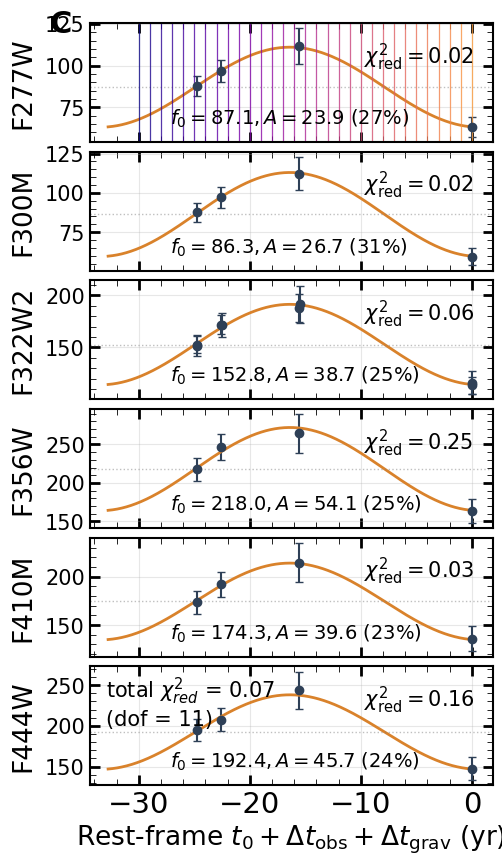

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ---------- 用户设置 ----------
bands = ['F277W','F300M','F322W2', 'F356W','F410M','F444W'] 

# bands = ['F090W', 'F115W', 'F150W', 'F200W', 'F210M', 'F277W','F300M','F322W2', 'F356W','F410M','F444W']  # 要联合拟合的 bands
tie_phi = True  # 【新增】True: 所有波段共享一个phi; False: 每个波段有独立的phi
max_phi_diff = 1.5       # 【阈值】允许的最大相位差（弧度），例如 0.5 rad
penalty_weight = 100.0   # 【强度】如果差值超过阈值，惩罚的权重。越大则限制越硬。
fit_M = False         # 是否拟合 Mass
fit_f0 = True          # 【开关】True: f0为自由参数; False: f0固定为观测均值
max_A_ratio = 0.5      # 【限制】振幅 A 最大为 f0 的多少倍 (0.5 即 50%)
M_fixed = 10**6.28    
# f_vals = np.array([0.37, 0.27, 0.20])
two_pi = 2.0 * np.pi
Temperature = 3750
# (假设 band_data 已经通过之前的 build_band_arrays 生成)

def build_band_arrays(band_list, sel_tab):
    """
    修改后的函数：
    如果 band_list 中包含 'F322W2', 
    将自动提取 'F277W' 和 'F356W' 的数据,
    并按 (F277W + F356W) / 2 的规则合并，
    最终输出8个点的 'F322W2' 数据。
    """
    # 1. 确定我们需要抓取哪些波段的数据
    bands_to_extract = set(band_list)
    if 'F322W2' in bands_to_extract:
        bands_to_extract.add('F277W')
        bands_to_extract.add('F356W')

    # 临时存储所有抓取到的数据
    temp_storage = {}
    # 2. 遍历所有需要抓取的波段
    for band in bands_to_extract:
        flux_list = []
        err_list = []
        tdelay_list = []
        # 遍历 sel_tab 中的所有 epoch
        for i, col in enumerate(sel_tab):
            # 复用你原来的 image index 交换逻辑
            img_idx = int(col['ID_2'].split('.')[1])
            if(img_idx == 3):
                img_idx = 4
            elif(img_idx == 4):
                img_idx = 3

            mu, mu_err, td, td_err = getlensing_para(9, img_idx)
            mu_err = np.max([0.08 * mu, mu_err])

            # --- [修改] 安全地提取流量数据 ---
            f_obs_str = 'f_' + band
            f_err_obs_str = 'e_' + band
            
            # 使用 .get() 避免 KeyError
            f_obs = col.get(f_obs_str)
            f_err_obs = col.get(f_err_obs_str)

            # 检查数据是否有效 (处理 None 或 "nan" 字符串)
            try:
                f_obs = float(f_obs)
                f_err_obs = float(f_err_obs)
            except (ValueError, TypeError):
                continue # 跳过这个 epoch, 因为没有这个 band 的数据
            
            # 检查是否为 NaN
            if np.isnan(f_obs) or np.isnan(f_err_obs):
                continue # 跳过这个 epoch, 因为数据是 NaN
            # --- [修改] 结束 ---
            f_err_obs = max(f_err_obs, 0.04 * f_obs)   # 保证下限 (遵照原代码注释掉)
            # flux 校正（原始 flux / |mu|）
            f_corr = f_obs / np.abs(mu)
            # flux uncertainty propagate: combine measurement 和 mu 不确定度
            f_corr_err = np.sqrt((f_err_obs / np.abs(mu))**2 +
                                 (f_obs / (np.abs(mu)**2) * mu_err)**2)
            
            flux_list.append(f_corr)
            err_list.append(f_corr_err)
            tdelay_list.append(td) # 记录这个 epoch 的 tdelay

        # 转换为 array
        flux_arr = np.array(flux_list, dtype=float)
        err_arr = np.array(err_list, dtype=float)
        # 转成年 (注意：这里我们假设 F322W2 的4个点和 F277/F356 的4个点有各自的 tdelay)
        t_arr = np.array(tdelay_list, dtype=float) / 365.0

        # 存入临时字典
        temp_storage[band] = dict(t=t_arr, flux=flux_arr, ferr=err_arr)

    # 3. 构建最终的 band_data, 处理 F322W2 合并
    band_data = {}
    for band in band_list:
        if band == 'F322W2':
            # --- [新增] F322W2 合并逻辑 ---
            # 提取原始的4个 F322W2 点
            t_1 = temp_storage['F322W2']['t']
            flux_1 = temp_storage['F322W2']['flux']
            ferr_1 = temp_storage['F322W2']['ferr']
            
            # 提取 F277W 的4个点
            t_2 = temp_storage['F277W']['t']
            flux_2 = temp_storage['F277W']['flux']
            ferr_2 = temp_storage['F277W']['ferr']
            
            # 提取 F356W 的4个点
            t_3 = temp_storage['F356W']['t']
            flux_3 = temp_storage['F356W']['flux']
            ferr_3 = temp_storage['F356W']['ferr']
            
            # 检查 F277W 和 F356W 的观测时间是否一致
            if not np.array_equal(t_2, t_3):
                print(f"警告: F277W 和 F356W 的观测时间 (t_arr) 不匹配。")
                # 假设 t_2 是我们要使用的时间戳
            
            # 1. 计算新的通量密度 (求平均)
            flux_new = (flux_2 + flux_3) / 2.0
            
            # 2. 计算新的误差
            # sigma_new = 0.5 * sqrt(sigma_2^2 + sigma_3^2)
            ferr_new = 0.5 * np.sqrt(ferr_2**2 + ferr_3**2)
            
            # 3. 合并所有数据 (t_1 + t_2, flux_1 + flux_new, ferr_1 + ferr_new)
            t_combined = np.concatenate((t_1 - 0.2, t_2))
            flux_combined = np.concatenate((flux_1, flux_new))
            ferr_combined = np.concatenate((ferr_1, ferr_new))
            
            # 存入最终的 band_data
            band_data['F322W2'] = {
                't': t_combined,
                'flux': flux_combined,
                'ferr': ferr_combined
            }
            # --- [新增] 逻辑结束 ---
        
        else:
            # 对于其他波段 (e.g., 'F277W', 'F444W'等)，直接从 temp_storage 复制
            if band in temp_storage:
                band_data[band] = temp_storage[band]
                
    return band_data
band_data = build_band_arrays(bands, sel_tab)


# ---------- 构造联合拟合的模型 ----------
def model_joint_constrained(p, t_all, band_idx_all, band_list, band_data, fit_M, fit_f0, max_A_ratio, Temp=4000, tie_phi=True):
    Nb = len(band_list)
    current_idx = 0
    
    # --- 1. 解析 f0 和 A (保持不变) ---
    if fit_f0:
        f0_list = p[current_idx : current_idx + Nb]
        current_idx += Nb
        A_rel_list = p[current_idx : current_idx + Nb]
        current_idx += Nb
        A_list = f0_list * A_rel_list
    else:
        f0_list = np.array([np.nanmean(band_data[b]['flux']) for b in band_list])
        A_list = p[current_idx : current_idx + Nb]
        current_idx += Nb

    # --- 2. 解析相位 phi (修改点) ---
    if tie_phi:
        phi_list = np.full(Nb, p[current_idx]) # 所有波段用同一个值
        current_idx += 1
    else:
        phi_list = p[current_idx : current_idx + Nb] # 每个波段从参数中取自己的值
        current_idx += Nb
    
    # --- 3. 解析 Mass (保持不变) ---
    if fit_M:
        M = 10.0**p[current_idx]
    else:
        M = M_fixed

    T = periods_from_M(M, np.array([f_vals[0]]), Temp)[0]
    
    y_model = np.empty_like(t_all)
    for j, band in enumerate(band_list):
        sel = (band_idx_all == j)
        if np.any(sel):
            tsel = t_all[sel]
            # 使用对应的 phi_list[j]
            y_model[sel] = f0_list[j] + A_list[j] * np.sin(two_pi * tsel / T + phi_list[j])
            
    return y_model
def residuals_joint(p, t_all, y_all, yerr_all, band_idx_all, band_list, band_data, fit_M, fit_f0, max_A_ratio, Temp=4000, tie_phi=False):
    # 1. 获取模型预测的残差 (Data Residuals)
    ym = model_joint_constrained(p, t_all, band_idx_all, band_list, band_data, fit_M, fit_f0, max_A_ratio, Temp, tie_phi)
    data_resid = (y_all - ym) / yerr_all
    
    # 2. 如果不 Tie Phase 且设置了限制，则计算相位惩罚项 (Penalty Residuals)
    if not tie_phi:
        Nb = len(band_list)
        # 准确定位 phi 在 p 中的位置
        phi_start_idx = (2*Nb if fit_f0 else Nb)
        phi_values = p[phi_start_idx : phi_start_idx + Nb]
        
        # 计算所有 band 相位相对于平均相位的偏差
        phi_mean = np.mean(phi_values)
        phi_diffs = phi_values - phi_mean
        
        # 构造惩罚项：如果 diff < max_phi_diff，则惩罚为 0；
        # 如果超过，则惩罚量随差值增加 (类似平滑的步进函数)
        # 这里使用 np.maximum(0, abs_diff - threshold)
        penalties = np.maximum(0, np.abs(phi_diffs) - max_phi_diff) * penalty_weight
        
        # 将数据残差和惩罚项合并为一个一维数组返回
        return np.concatenate([data_resid, penalties])
    
    return data_resid

# ---------- 准备数据 ----------
t_concat = []
y_concat = []
yerr_concat = []
band_idx_concat = []

for ib, band in enumerate(bands):
    d = band_data[band]
    t_points = - d['t'] / (1.0 + z)
    t_concat.append(t_points)
    y_concat.append(d['flux'])
    yerr_concat.append(d['ferr'])
    band_idx_concat.append(np.full_like(t_points, ib, dtype=int))

t_all = np.concatenate(t_concat)
y_all = np.concatenate(y_concat)
yerr_all = np.concatenate(yerr_concat)
band_idx_all = np.concatenate(band_idx_concat)

# ---------- 构造初始猜测 p0 和边界 bounds ----------
Nb = len(bands)
p0 = []
lower = []
upper = []

if fit_f0:
    # --- 构造参数: [f0_1...f0_n, Arel_1...Arel_n, phi, ...] ---
    
    # 1. f0 (Baseline)
    for band in bands:
        f_mean = np.nanmean(band_data[band]['flux'])
        p0.append(f_mean)
        lower.append(0.0)
        upper.append(np.inf) # f0 必须为正
        
    # 2. A_rel (Relative Amplitude: 0 ~ max_A_ratio)
    for band in bands:
        # 初始猜测振幅大概是均值的 10%
        p0.append(0.1) 
        lower.append(0.0)
        upper.append(max_A_ratio) # 【关键限制】这里锁死了比例上限
        
else:
    # --- 构造参数: [A_1...A_n, phi, ...] ---
    
    # 1. A (Absolute Amplitude)
    for band in bands:
        f_mean = np.nanmean(band_data[band]['flux'])
        p0.append(0.1 * f_mean)
        lower.append(0.0)
        # 【关键限制】即使 f0 固定，A 也不能超过固定 f0 的 max_ratio 倍
        upper.append(f_mean * max_A_ratio) 

# 3. Common Phase (phi)
# p0.append(0.0)
# lower.append(-np.inf)
# upper.append(np.inf)
if tie_phi:
    p0.append(0.0)
    lower.append(-np.inf)
    upper.append(np.inf)
else:
    for _ in range(Nb):
        p0.append(0.0)
        lower.append(-np.inf)
        upper.append(np.inf)

# 4. Mass (M)
if fit_M:
    p0.append(np.log10(M_fixed))
    lower.append(3.0)
    upper.append(9.0)

p0 = np.array(p0)
bounds = (np.array(lower), np.array(upper))

# ---------- 执行拟合 ----------
res = least_squares(
    residuals_joint, p0,
    args=(t_all, y_all, yerr_all, band_idx_all, bands, band_data, fit_M, fit_f0, max_A_ratio, Temperature, tie_phi),
    bounds=bounds, 
    verbose=1
)
popt = res.x

# ---------- 结果解析与统计 ----------
# 重新解析一遍参数，拿到物理意义的 f0 和 A
if fit_f0:
    f0_fit = popt[0:Nb]
    A_fit = f0_fit * popt[Nb:2*Nb]
    phi_start_idx = 2*Nb
else:
    f0_fit = np.array([np.nanmean(band_data[b]['flux']) for b in bands])
    A_fit = popt[0:Nb]
    phi_start_idx = Nb

if tie_phi:
    phi_fit_list = np.full(Nb, popt[phi_start_idx])
    mass_idx = phi_start_idx + 1
else:
    phi_fit_list = popt[phi_start_idx : phi_start_idx + Nb]
    mass_idx = phi_start_idx + Nb

if fit_M:
    M_fit = 10**popt[mass_idx]
else:
    M_fit = M_fixed

# 计算 Chi2
y_fit_all = model_joint_constrained(popt, t_all, band_idx_all, bands, band_data, fit_M, fit_f0, max_A_ratio, Temperature, tie_phi)
resid_phys = (y_all - y_fit_all) / yerr_all  # 纯物理残差
chi2_total = np.sum(resid_phys**2)

# 计算 DOF
# 自由参数数量 = len(popt)
# 约束数量：如果不拟合 f0，我们使用了数据均值，相当于引入了 len(bands) 个约束
constraint_correction = 0 if fit_f0 else len(bands)
# F322W2 非独立点扣除 4 个自由度
dof_total = len(y_all) - len(popt) - constraint_correction - 4
chi2_red_total = chi2_total / max(1, dof_total)

# 每个 band 的 chi2
chi2_per_band = {}
for ib, band in enumerate(bands):
    sel = (band_idx_all == ib)
    if np.any(sel):
        r = resid_phys[sel]
        chi2_b = np.sum(r**2)
        dof_b = np.sum(sel) - 3  # 每 band 拟合了 A 和 phi (m0 固定)
        chi2_per_band[band] = dict(chi2=chi2_b, dof=dof_b, chi2_red=chi2_b / max(1, dof_b))
    else:
        chi2_per_band[band] = dict(chi2=np.nan, dof=0, chi2_red=np.nan)
# ---------- 打印结果 ----------
print("-" * 60)
print(f"FIT REPORT: fit_f0={fit_f0}, Max A/f0 Ratio={max_A_ratio*100:.0f}%")
print(f"Common Phase = {phi_fit:.4f} rad")
print(f"Total chi2 = {chi2_total:.2f} | dof = {dof_total} | chi2_red = {chi2_red_total:.3f}")
print("-" * 60)
print(f"{'Band':<8} | {'f0 (nJy)':<10} | {'A (nJy)':<10} | {'A/f0 (%)':<8}")
for ib, band in enumerate(bands):
    ratio_pct = (A_fit[ib] / f0_fit[ib]) * 100
    print(f"{band:<8} | {f0_fit[ib]:<10.3f} | {A_fit[ib]:<10.3f} | {ratio_pct:<8.1f}")
print("-" * 60)

# ---------- 绘图 ----------
n_panels = len(bands)

fig, axes = plt.subplots(n_panels, 1, figsize=(5.2, 1.65 * n_panels), sharex=True)
plt.subplots_adjust(hspace=0.08)
if n_panels == 1: axes = [axes]

t_plot = np.linspace(np.min(t_all)-8, np.max(t_all)+0.2, 800)
T_fit = periods_from_M(M_fit, np.array([f_vals[0]]), Temperature)[0]

for ib, band in enumerate(bands):
    ax = axes[ib]
    d = band_data[band]
    t_pts = - d['t'] / (1.0 + z)
    
    # Data
    ax.errorbar(t_pts, d['flux'], yerr=d['ferr'], color='#2E4057', fmt='o', markersize=6, capsize=3)

    # Model
    # y_model_plot = f0_fit[ib] + A_fit[ib] * np.sin(two_pi * t_plot / T_fit + phi_fit)
    # Model
    y_model_plot = f0_fit[ib] + A_fit[ib] * np.sin(two_pi * t_plot / T_fit + phi_fit_list[ib])
    ax.plot(t_plot, y_model_plot, '-', lw=2, color='#D9822B')
    
    # 虚线标示 f0
    ax.axhline(f0_fit[ib], color='gray', ls=':', alpha=0.5, lw=1)

    # 标注
    ratio_val = A_fit[ib] / f0_fit[ib]
    # 如果达到边界，用红色显示
    param_color = 'red' if (ratio_val > max_A_ratio * 0.99) else 'black'
    
    label_str = fr'$f_0={f0_fit[ib]:.1f}, A={A_fit[ib]:.1f}$ ({ratio_val*100:.0f}%)'

    # 标注该 band 的 chi2
    chi2b = chi2_per_band[band]['chi2']
    chi2rb = chi2_per_band[band]['chi2_red']
    ax.text(0.68, 0.66, r'$\chi^2_{\rm red} = %.2f$' % (chi2rb,), transform=ax.transAxes, fontsize=15)
    ax.text(0.2, 0.15, label_str, transform=ax.transAxes, fontsize=14)

    ax.set_ylabel(f"{band}\n", labelpad=-15, fontsize = 19)
    ax.tick_params(axis='y', labelsize=15)
    ax.grid(alpha=0.3)
    # ax.legend(frameon=False, fontsize=15)
    if(ib == 0):
        for indtt, tt in enumerate(t_grid):
            ax.axvline(x = tt, color = colors[indtt], lw = 0.9, alpha = 0.8)

    ax.grid(alpha=0.3)
    
axes[-1].set_xlabel(r"Rest-frame $t_0 + \Delta t_{\rm obs} + \Delta t_{\rm grav}$" + " (yr)", fontsize=19)
axes[-1].text(0.04, 0.5, f"total $\\chi^2_{{red}}$ = {chi2_red_total:.2f}\n(dof = {dof_total})" , transform=axes[-1].transAxes, fontsize=15)
axes[0].text(-0.1, 0.92, "C", transform=axes[0].transAxes, fontsize=22, fontweight='bold')

save_path = '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/lc_fitting.pdf'
# plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()



In [25]:
periods_from_M(10**6.28, np.array([f_vals[0]]), 3750)[0]

34.14005131020494

In [26]:
f_vals[0]

0.3226

In [27]:
np.array([f_vals[0]]), Temperature

(array([0.3226]), 3750)

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from tqdm import tqdm
from joblib import Parallel, delayed
import warnings

# 忽略并行计算中可能出现的除零等无关紧要的警告
warnings.filterwarnings("ignore")

# ==========================================
# 1. 核心模型定义 (必须确保接受 Temperature)
# =====


def model_joint_parallel(p, t_all, band_idx_all, band_list, band_data, fit_M, fit_f0, max_A_ratio, M_fixed_val, Temperature):
    """
    专门为并行优化的 Model 函数
    """
    Nb = len(band_list)
    current_idx = 0
    
    # 1. 解析 f0 和 A
    if fit_f0:
        f0_list = p[current_idx : current_idx + Nb]
        current_idx += Nb
        A_rel_list = p[current_idx : current_idx + Nb]
        current_idx += Nb
        A_list = f0_list * A_rel_list
    else:
        f0_list = np.array([np.nanmean(band_data[b]['flux']) for b in band_list])
        A_list = p[current_idx : current_idx + Nb]
        current_idx += Nb

    # 2. 解析公共相位 phi
    phi_common = p[current_idx]
    current_idx += 1
    
    # 3. Mass
    if fit_M:
        M = 10.0**p[current_idx]
    else:
        M = M_fixed_val # 使用从 args 传入的 M

    # 计算周期 (调用你外部定义的函数)
    T_period = periods_from_M(M, np.array([f_vals[0]]), Temperature)[0]
    
    y_model = np.empty_like(t_all)
    for j, band in enumerate(band_list):
        sel = (band_idx_all == j)
        if np.any(sel):
            tsel = t_all[sel]
            y_model[sel] = f0_list[j] + A_list[j] * np.sin(two_pi * tsel / T_period + phi_common)
            
    return y_model

def residuals_joint_parallel(p, t_all, y_all, yerr_all, band_idx_all, band_list, band_data, fit_M, fit_f0, max_A_ratio, M_fixed_val, Temperature):
    """
    更新后的 Residuals: 显式接受 M_fixed_val 和 Temperature
    """
    ym = model_joint_parallel(p, t_all, band_idx_all, band_list, band_data, fit_M, fit_f0, max_A_ratio, M_fixed_val, Temperature)
    return (y_all - ym) / yerr_all


# ==========================================
# 2. 设置与准备
# ==========================================

# Mlist = np.linspace(4, 9, 200)
# Tlist = np.linspace(3000, 6000, 200)
# 为了测试跑通，先用小一点的网格，正式跑请改回 200
if 1:
    Mlist = np.linspace(4, 9, 500)
    Tlist = np.linspace(3000, 6000, 500)

    fit_M = False          
    fit_f0 = True          
    max_A_ratio = 0.7      
    two_pi = 2.0 * np.pi

    # ==========================================
    # 3. 定义并行 Worker 函数
    # ==========================================

    def solve_one_pixel(args):
        """
        单个像素点的计算逻辑
        args: (i, j, M_log_val, T_val)
        """
        i, j, M_log, T_val = args

        # 计算当前网格点的物理参数
        M_fixed = 10**M_log
        Temperature = T_val

        # ---------- 构造初始猜测 p0 和边界 bounds ----------
        Nb = len(bands)
        p0 = []
        lower = []
        upper = []

        if fit_f0:
            # [f0_1...f0_n, Arel_1...Arel_n, phi]
            # 1. f0
            for band in bands:
                f_mean = np.nanmean(band_data[band]['flux'])
                p0.append(f_mean)
                lower.append(0.0)
                upper.append(np.inf)
            # 2. A_rel
            for band in bands:
                p0.append(0.1) 
                lower.append(0.0)
                upper.append(max_A_ratio) 
        else:
            # [A_1...A_n, phi]
            for band in bands:
                f_mean = np.nanmean(band_data[band]['flux'])
                p0.append(0.1 * f_mean)
                lower.append(0.0)
                upper.append(f_mean * max_A_ratio)

        # 3. Common Phase
        p0.append(0.0)
        lower.append(-np.inf)
        upper.append(np.inf)

        # 4. Mass (如果 fit_M=True, 这里会添加 parameters，但 Grid Search通常 fit_M=False)
        if fit_M:
            p0.append(M_log)
            lower.append(3.0)
            upper.append(9.0)

        p0 = np.array(p0)
        bounds = (np.array(lower), np.array(upper))

        # ---------- 执行拟合 ----------
        # 注意：我们将 M_fixed 显式传递给 residual
        try:
            res = least_squares(
                residuals_joint_parallel, p0,
                args=(t_all, y_all, yerr_all, band_idx_all, bands, band_data, fit_M, fit_f0, max_A_ratio, M_fixed, Temperature),
                bounds=bounds, 
                verbose=0,       # 关闭输出以防刷屏
                ftol=1e-4,       # 可选：适当放宽精度以加速 Grid Search
                xtol=1e-4
            )
            popt = res.x

            # ---------- 计算 Chi2 ----------
            y_fit_all = model_joint_parallel(popt, t_all, band_idx_all, bands, band_data, fit_M, fit_f0, max_A_ratio, M_fixed, Temperature)
            resid_all = (y_all - y_fit_all) / yerr_all
            chi2_total = np.sum(resid_all**2)

            constraint_correction = 0 if fit_f0 else len(bands)
            dof_total = len(y_all) - len(popt) - constraint_correction - 4
            chi2_red_total = chi2_total / max(1, dof_total)

        except Exception as e:
            # 如果拟合失败，返回 NaN
            chi2_red_total = np.nan

        return i, j, chi2_red_total

    # ==========================================
    # 4. 执行并行计算
    # ==========================================

    print(f"Start Grid Search: {len(Mlist)}x{len(Tlist)} = {len(Mlist)*len(Tlist)} pixels")
    print(f"Parallel Backend: joblib (n_jobs=-1)")

    # 1. 构造任务列表 (Flatten the loop)
    tasks = []
    for i, M in enumerate(Mlist):
        for j, T in enumerate(Tlist):
            tasks.append((i, j, M, T))

    # 2. 并行执行
    # n_jobs=-1 使用所有可用核心
    results = Parallel(n_jobs=-1)(
        delayed(solve_one_pixel)(task) for task in tqdm(tasks, desc="Grid Chi2")
    )

    # 3. 结果重组
    chi2_grid = np.zeros((len(Mlist), len(Tlist)))
    for i, j, val in results:
        chi2_grid[i, j] = val

    print("\nGrid Search Completed.")

    # ==========================================
    # 5. (可选) 简单可视化结果检查
    # ==========================================
    # plt.figure(figsize=(8, 6))
    # plt.imshow(np.log10(chi2_grid.T), origin='lower', aspect='auto', 
    #            extent=[Mlist[0], Mlist[-1], Tlist[0], Tlist[-1]], cmap='viridis')
    # plt.colorbar(label='log10(Chi2_red)')
    # plt.xlabel('log10(M)')
    # plt.ylabel('Temperature')
    # plt.title('Chi2 Grid')
    # plt.show()

np.savez('chi2_grid_data.npz',
         Mlist=Mlist,
         Tlist=Tlist,
         chi2_grid=chi2_grid)

Start Grid Search: 500x500 = 250000 pixels
Parallel Backend: joblib (n_jobs=-1)


Grid Chi2:   1%|          | 3096/250000 [00:02<01:20, 3085.30it/s]

KeyboardInterrupt: 

In [63]:
Temperature

3750

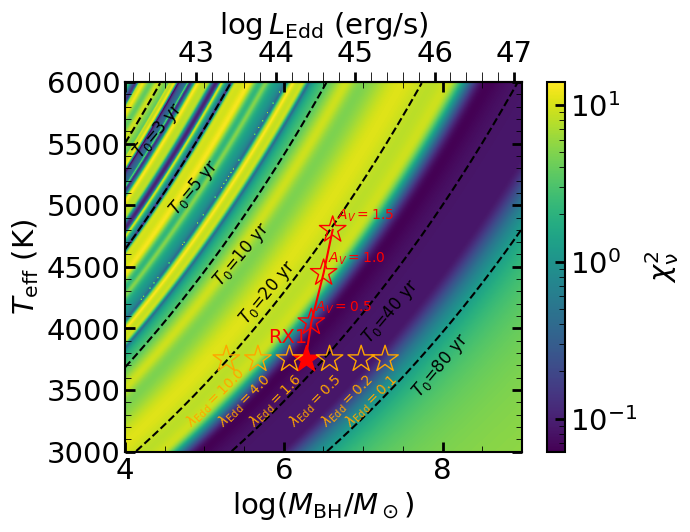

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 计算 Eddington luminosity
def Ledd(Mbh):
    return 1.26e38 * Mbh  # erg/s

# 公式前因子 (λ_Edd & f0 可改)
f0 = 0.333
lambda_Edd = 1.0
A = 35.24066052789288 * lambda_Edd**0.75 * (f0/0.333)

plt.figure()
img = plt.imshow(
    chi2_grid.T,
    origin='lower',
    aspect='auto',
    extent=[Mlist[0], Mlist[-1], Tlist[0], Tlist[-1]],
    norm=LogNorm()
)

Mbh = 10**Mlist

# 画 T0 虚线（单位 yr），并限制 Teff 在 y 轴范围内
T0_values = [3, 5, 10, 20, 40, 80]
for T0 in T0_values:
    Teff_line = Temperature * (A * (Mbh/10**6.28)**0.25 / T0) ** (1/3)
    valid = (Teff_line >= 3000) & (Teff_line <= 6000)
    if valid.sum() > 1:
        plt.plot(Mlist[valid], Teff_line[valid], linestyle='--', zorder=5, color = 'k')
        # 在 valid 区域的中间位置标注 T0
        mid = np.where(valid)[0][len(np.where(valid)[0])//2]
        if (T0 !=20):
            plt.text(Mlist[mid] + 0.2, Teff_line[mid] - 400, fr"$T_0$={T0} yr", fontsize=12, va='bottom', ha='center', rotation = 50)
        else:
            plt.text(Mlist[mid] - 0.15, Teff_line[mid] - 250, fr"$T_0$={T0} yr", fontsize=12, va='bottom', ha='center', rotation = 50)
# 你原来的点标注
# plt.scatter(6.28, 4000, marker='*', s=400, color='red', zorder=10)

Av = np.array([0, 0.5, 1, 1.5])
logMBH = np.array([6.27565864, 6.34678749, 6.50168945, 6.6156328])
Teff = np.array([3750, 4050, 4450, 4800])

# 先画连线
plt.plot(logMBH, Teff, color='red', zorder=5)

# 分别画点（控制是否空心）
for x, y, av in zip(logMBH, Teff, Av):
    if av == 0:
        plt.scatter(x, y, marker='*', s=400, color='red', zorder=10)
    else:
        plt.scatter(x, y, marker='*', s=400,
                    facecolors='none', edgecolors='red', zorder=10)

    # 标注 Av
        plt.text(x+0.05, y+50, fr'$A_V = ${av}', fontsize=10,color = 'red',
             ha='left', va='bottom', zorder = 10)
Eddratiolist = np.array([0.1,  0.2, 0.5, 1.6, 4, 10])
for Eddratio in Eddratiolist:
    x = 6.27565864 - np.log10(Eddratio)
    y = 3750
    plt.scatter(x, y, marker='*', s=400,
                    facecolors='none', edgecolors='orange', zorder=10)
    # plt.text(x- 0.55, y- 480, fr'$\lambda_{\rm Edd} = ${Eddratio}', fontsize=10,color = 'orange', rotation = 45,
            #  ha='left', va='bottom', zorder = 10)
    plt.text(x - 0.55, y - 580,fr'$\lambda_{{\rm Edd}} = {Eddratio}$',fontsize=10,color='orange',rotation=45,ha='left', va='bottom', zorder = 10)
# plt.plot(6.27565864 - np.log10(Eddratiolist), np.ones(len(Eddratiolist)) * 3750, color='red', zorder=5)
plt.text(5.8, 3850, "RX1", color='red', fontsize=14, va='bottom', ha='left', zorder=10)

plt.colorbar(img, label=r'$\chi_{\rm \nu}^2$')
plt.xlabel(r'$\log (M_{\rm BH}/M_\odot)$')
plt.ylabel(r'$T_{\rm eff}$ (K)')

# 上方 x 轴 = log Ledd
ax = plt.gca()
ax_top = ax.secondary_xaxis('top')
ticks_M = np.array([np.log10(1e42/1.26e38),np.log10(1e43/1.26e38),np.log10(1e44/1.26e38), np.log10(1e45/1.26e38), np.log10(1e46/1.26e38), np.log10(1e47/1.26e38)])

ticks_Ledd = np.log10(Ledd(10**ticks_M))
ax_top.set_xticks(ticks_M)
ax_top.set_xticklabels([f"{v:.0f}" for v in ticks_Ledd])
ax_top.set_xlabel(r"$\log L_{\rm Edd}$ (erg/s)")
# 设置上轴刻度线只显示上方，不跟下方连
ax_top.tick_params(axis='x', which='both', length=7, direction='out', top=True, bottom=False)
# 可选：让上轴只显示 label，不画刻度线
# ax_top.tick_params(axis='x', which='both', length=0)  # 不画刻度线

plt.ylim(3000, 6000)
plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'param_space_lcfit.pdf', dpi=200, bbox_inches='tight')
# plt.show()

In [37]:
Ledd_per_Msun = 1.26e38 * u.erg/u.s
MBH = np.log10((Lbol / 0.1 / Ledd_per_Msun)) * u.Msun
MBH

<Quantity [7.27565864, 7.34678749, 7.50168945, 7.6156328 ] solMass>

In [ ]:
np.log10((Lbol / Ledd_per_Msun)) - np.log10(0.1)

<Quantity [7.27565864, 7.34678749, 7.50168945, 7.6156328 ]>

Duplicate key in file '/Users/zijianzhang/Astro_Data/paper.mplstyle', line 23 ('axes.linewidth : 1.5')


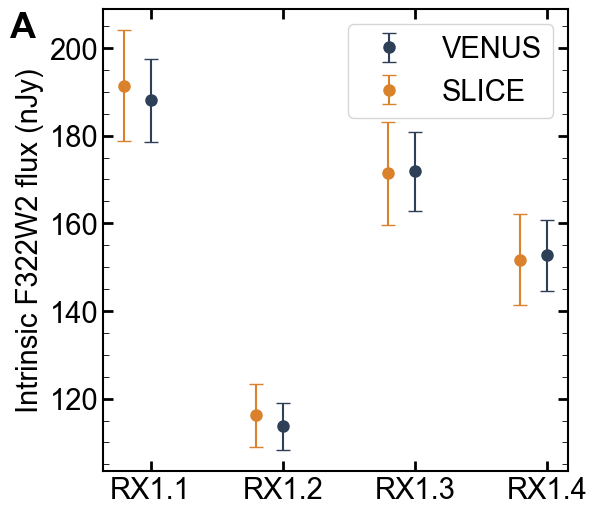

In [150]:
plt.style.use('/Users/zijianzhang/Astro_Data/paper.mplstyle')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']  # 你也可以改成 'Helvetica', 'DejaVu Sans', 'Inter' 等

t = np.array([ 0.8,  2-0.2       , 3.8, 2.8, 1,    2.        , 4, 3])
flux = np.array([191.37739367, 116.18408434, 151.70076029, 171.38242884, 188.02548935, 113.64384701, 152.65516807, 171.87862874])
ferr = np.array([12.68062505,  7.14978335, 10.42438737, 11.67836019,  9.50720163, 5.40551211,  8.0590356 ,  9.0413374 ])

mask = np.array([i%1 == 0  for i in t])
fig = plt.figure(figsize = (6,6))
plt.errorbar(t[mask], flux[mask], yerr = ferr[mask], color = '#2E4057', fmt='o', markersize=8, capsize=5, label = 'VENUS')
plt.errorbar(t[~mask], flux[~mask], yerr = ferr[~mask], color = '#D9822B', fmt='o', markersize=8, capsize=5, label = 'SLICE')
plt.ylabel('Intrinsic F322W2 flux (nJy)')
x_ticks = [ 1, 2, 3, 4]
plt.gca().set_xticks(x_ticks)
plt.gca().set_xticklabels(['RX1.' + str(int(tick)) if tick < 10 else f"{int(tick)}" for tick in x_ticks])
plt.gca().xaxis.set_minor_locator(plt.NullLocator())  # 关闭X轴minor
plt.legend()
plt.text(-0.2, 0.94, "A", transform=plt.gca().transAxes, fontsize=26, fontweight='bold')
# plt.savefig()
plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'venus_slice_RX1.pdf', dpi=200, bbox_inches='tight')


In [143]:
import numpy as np

t = np.array([0.8, 2-0.2, 3.8, 2.8, 1, 2., 4, 3])
flux = np.array([191.37739367, 116.18408434, 151.70076029, 171.38242884,
                 188.02548935, 113.64384701, 152.65516807, 171.87862874])
ferr = np.array([12.68062505, 7.14978335, 10.42438737, 11.67836019,
                 9.50720163, 5.40551211, 8.0590356, 9.0413374])

mask_venus = (t % 1 == 0)
mask_slice = ~mask_venus

t_venus = t[mask_venus]
f_venus = flux[mask_venus]
e_venus = ferr[mask_venus]

t_slice = t[mask_slice]
f_slice = flux[mask_slice]
e_slice = ferr[mask_slice]

# 把 SLICE 按最近整数 epoch 分组
delta_mag_list = []
delta_mag_err_list = []
epoch_list = []

for i, tv in enumerate(t_venus):
    # 找到对应的 SLICE（四舍五入到最近整数）
    idx = np.where(np.round(t_slice) == tv)[0]
    
    for j in idx:
        fs = f_slice[j]
        es = e_slice[j]
        
        fv = f_venus[i]
        ev = e_venus[i]
        
        # delta mag
        dmag = -2.5 * np.log10(fv / fs)
        
        # 误差传播
        dmag_err = (2.5 / np.log(10)) * np.sqrt((ev/fv)**2 + (es/fs)**2)
        
        delta_mag_list.append(dmag)
        delta_mag_err_list.append(dmag_err)
        epoch_list.append(tv)

# 输出
for ep, dm, de in zip(epoch_list, delta_mag_list, delta_mag_err_list):
    print(f"Epoch {ep:.0f}: Δmag = {dm:.3f} ± {de:.3f}")

Epoch 1: Δmag = 0.019 ± 0.090
Epoch 2: Δmag = 0.024 ± 0.084
Epoch 4: Δmag = -0.007 ± 0.094
Epoch 3: Δmag = -0.003 ± 0.093


In [144]:
delta_mag_err_list

[0.09049474913598643,
 0.08444655071787435,
 0.09408413235765634,
 0.09346433391255397]

In [29]:
# # 这里是跑前前个block后的，而不是前一个，否则会出错


# fit_params_per_band  = {}
# for ib, band in enumerate(bands):
#     A_val = popt[2*ib]
#     phi_val = popt[2*ib+1]
#     fit_params_per_band[band] = {'A': A_val, 'phi': phi_val, 'm0': np.nanmean(band_data[band]['flux']), 'ferr':  np.nanmedian(band_data[band]['ferr']/band_data[band]['flux'])}
#     print(f" {band:6s}  A = {A_val:.5f} , phi = {phi_val:.5f}")

fit_params_per_band  ={'F090W': {'A': 1.3164918955672265,
  'phi': 0.40095683802109616,
  'm0': 7.440623210004312,
  'ferr': 0.7644913248150168},
 'F115W': {'A': 0.7625423267736422,
  'phi': -0.31317955635882383,
  'm0': 10.735684085573064,
  'ferr': 0.2860907547196779},
 'F150W': {'A': 2.9061745389571954,
  'phi': -1.6679589660678147,
  'm0': 14.387584687810989,
  'ferr': 0.2889629989490814},
 'F200W': {'A': 1.778065339428472,
  'phi': -1.7249304556134701,
  'm0': 21.387018992191074,
  'ferr': 0.16430529752203094},
 'F210M': {'A': 2.536022474557189,
  'phi': -1.052852706615332,
  'm0': 25.945206388879196,
  'ferr': 0.1291314675357244},
 'F277W': {'A': 25.73212352603984,
  'phi': -1.7811928650565214,
  'm0': 89.90172426310684,
  'ferr': 0.06871677733995356},
 'F300M': {'A': 28.583355145630446,
  'phi': -1.7504990153420397,
  'm0': 89.14374683443522,
  'ferr': 0.06871677733995354},
 'F322W2': {'A': 40.65302865563809,
  'phi': -1.7564260475849336,
  'm0': 157.10597503878975,
  'ferr': 0.06871677733995354},
 'F356W': {'A': 55.65827158485084,
  'phi': -1.7080861630624358,
  'm0': 223.19984232100927,
  'ferr': 0.06871677733995356},
 'F410M': {'A': 41.99561753551677,
  'phi': -1.785641143071555,
  'm0': 178.96745017919622,
  'ferr': 0.06871677733995356},
 'F444W': {'A': 50.008915575346016,
  'phi': -1.817864533324702,
  'm0': 198.386799338621,
  'ferr': 0.06871677733995356}}

# ---------- 适配新版联合拟合结果的参数提取 (支持 Tie/Untie Phase) ----------
# fit_params_per_band = {}
# Nb = len(bands)

# # 1. 准确定位参数起始索引
# if fit_f0:
#     f0_fit_vals = popt[0:Nb]
#     A_rel_fit_vals = popt[Nb:2*Nb]
#     A_fit_vals = f0_fit_vals * A_rel_fit_vals
#     phi_start_idx = 2 * Nb
# else:
#     # 如果不拟合 f0，则从数据中获取均值
#     f0_fit_vals = np.array([np.nanmean(band_data[b]['flux']) for b in bands])
#     A_fit_vals = popt[0:Nb]
#     phi_start_idx = Nb

# # 2. 解析相位 phi_fit_list
# if tie_phi:
#     # 所有波段共用一个相位
#     phi_val_common = popt[phi_start_idx]
#     phi_fit_list = np.full(Nb, phi_val_common)
#     mass_start_idx = phi_start_idx + 1
# else:
#     # 每个波段有独立相位
#     phi_fit_list = popt[phi_start_idx : phi_start_idx + Nb]
#     mass_start_idx = phi_start_idx + Nb

# # 3. 填充字典结构
# print("-" * 60)
# print(f"{'Band':<8} | {'f0':<10} | {'A':<10} | {'A/f0 (%)':<8} | {'Phase (rad)':<10}")
# print("-" * 60)

# for ib, band in enumerate(bands):
#     A_val = A_fit_vals[ib]
#     f0_val = f0_fit_vals[ib]
#     phi_val = phi_fit_list[ib]
    
#     # 计算中值相对误差作为参考
#     flux_pts = band_data[band]['flux']
#     ferr_pts = band_data[band]['ferr']
#     median_rel_err = np.nanmedian(ferr_pts / flux_pts) if np.nanmean(flux_pts) != 0 else 0
    
#     fit_params_per_band[band] = {
#         'A': A_val, 
#         'phi': phi_val, 
#         'm0': f0_val, 
#         'ferr': median_rel_err
#     }
    
#     # 打印每个波段的物理参数
#     ratio_pct = (A_val / f0_val) * 100 if f0_val != 0 else 0
#     print(f"{band:<8} | {f0_val:10.3f} | {A_val:10.3f} | {ratio_pct:8.1f}% | {phi_val:10.5f}")

# # 4. 解析质量 Mass
# if fit_M:
#     logM_fit = popt[mass_start_idx] # Mass 永远在最后
#     print("-" * 60)
#     print(f"Fit Result: Common Log10M = {logM_fit:.5f}")
# elif 'M_fixed' in globals():
#     print("-" * 60)
#     print(f"Fixed Param: Log10M = {np.log10(M_fixed):.5f}")

In [30]:

# ================================================
# 固定的 Power-law 参数（来自你之前的拟合结果）
# ================================================8.568

# ================================================
# 输入：每个band的模型光变参数
# 这些是你之前联合光变拟合的输出
# ================================================

M_fixed = 10**6.28  # 你的固定质量
f_vals = np.array([0.3226, 0.27, 0.20])  # 频率定义
two_pi = 2.0 * np.pi

# ================================================
# Step 1. 生成 40 个相位/时间点
# ================================================
T_period = 30#periods_from_M(10**6.28, np.array([f_vals[0]]), 3750)[0]  #periods_from_M(M_fixed, np.array([f_vals[0]]))[0]
t_grid = np.linspace(0, T_period, int(T_period) + 1) - T_period   # 40个时刻
bands_use = ['F090W', 'F115W', 'F150W', 'F200W','F210M', 'F300M',  'F410M', 'F444W'] #list(fit_params_per_band.keys())

# 对应波长（假设每个band取中央波长）
band_wavelengths = {
    'F090W': 0.9,
    'F115W': 1.15,
    'F150W': 1.50,
    'F200W': 2.0,
    'F210M': 2.10,
    'F277W': 2.77,
    'F300M': 3.00,
    'F356W': 3.56,
    'F410M': 4.10,
    'F444W': 4.44,
}

# ================================================
# Step 2. 生成每个时刻的 SED（flux）
# ================================================

# t_plot = np.linspace(np.min(t_data)-0.2, np.max(t_data)+0.2, 600)
# y_model = model_mag_single(popt, t_plot, fit_M)
# 保存每个时刻的SED
SEDs = []
for t_now in t_grid:
    flux_now = []
    wl_now = []
    flux_err_now = []
    for band in bands_use:
        wl = band_wavelengths[band]
        A = fit_params_per_band[band]['A']
        phi = fit_params_per_band[band]['phi']
        m0 = fit_params_per_band[band]['m0']
        # print(band, A, phi, m0)
        # flux 归一化后可乘以任意常数
        # f = model_mag_singleband(A, phi, t_now)
        f = get_model_mag_single([A, phi],t_now, m0, fit_M, T = 3800)
        flux_now.append(f)
        flux_err_now.append(f * fit_params_per_band[band]['ferr'])
        wl_now.append(wl)
    SEDs.append({'time': t_now, 'wave': np.array(wl_now), 'flux': np.array(flux_now), 'ferr': np.array(flux_err_now)})



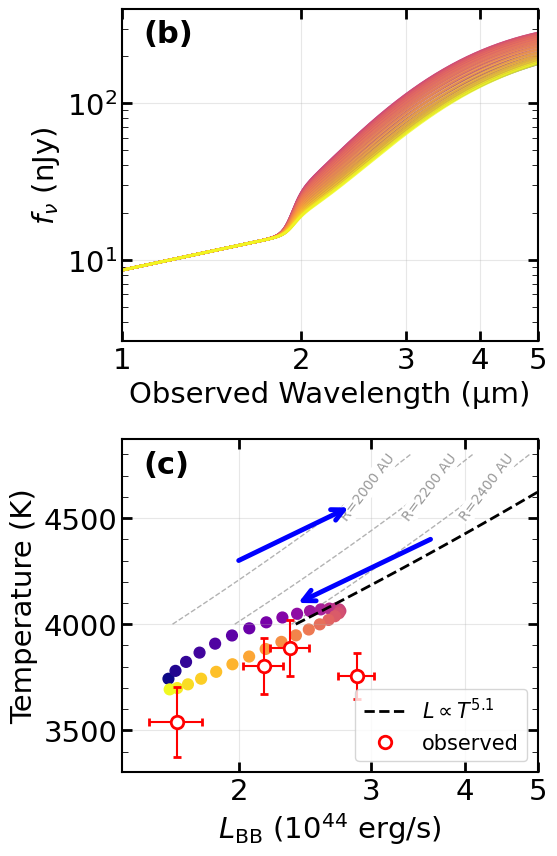

In [31]:
# ================================================
# Step 3. 对每个时刻的SED做黑体+powerlaw拟合
# ================================================

A_PL_fixed = 8.568
alpha_fixed = 0.804
A_V_fixed = 0.0
redshift = 4.3
blue_cut = 1.0  # µm

def SED_model(wl, T, norm):
    """固定 A_PL, alpha, A_V"""
    wl_AA = wl * 1e4
    A_lambda = extinction.calzetti00(wl_AA / (1 + redshift), A_V_fixed, r_v=4.05)
    flux_bb = blackbody_Fnu(wl, T, norm, z=redshift)
    flux_pl = A_PL_fixed * (wl / blue_cut) ** alpha_fixed
    flux_int = flux_bb * 10 ** (-0.4 * A_lambda) + flux_pl
    return flux_int

fit_results_time = []

for SED in SEDs:
    wl = SED['wave']
    flux = SED['flux']
    ferr = SED['flux'] * 0.1#SED['ferr']
    p0 = [4700, 44.0]
    lower = [3000, 42]
    upper = [8000, 50]
    popt, pcov = curve_fit(SED_model, wl, flux, p0=p0,  bounds=(lower, upper))
    T_fit, norm_fit = popt
    T_err, norm_err = np.sqrt(np.diag(pcov))
    fit_results_time.append({
        't': SED['time'],
        'T': T_fit, 'T_err': T_err,
        'norm': norm_fit, 'norm_err': norm_err
    })
   

# ================================================
# Step 4. 绘图：演化的 (a) SED 拟合 + (b) L–T 图
# ================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))
fit_wave = np.linspace(0.3, 5.0, 300)
colors = plt.cm.plasma(np.linspace(0, 1, len(fit_results_time)))

for i, res in enumerate(fit_results_time):
    T = res['T']
    norm = res['norm']
    t_now = res['t']
    flux_fit = SED_model(fit_wave, T, norm)
    color = colors[i]
    ax1.plot(fit_wave, flux_fit, color=color, lw=2, alpha=0.8)

ax1.set_xlabel("Observed Wavelength (µm)")
ax1.set_ylabel(r"$f_{\nu}$ (nJy)")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(1, 5)
ax1.set_ylim(3, 4e2)
ax1.grid(True, alpha=0.3)
x_ticks = [ 1, 2, 3, 4,5]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(int(tick)) if tick < 10 else f"{int(tick)}" for tick in x_ticks])
ax1.set_ylabel(r"$f_{\nu}$ (nJy)")
ax1.grid(alpha=0.3)
ax1.text(0.05, 0.9, "(b)", transform=ax1.transAxes, fontsize=22, fontweight='bold')

# --- L–T 图 ---
temps_time = np.array([r['T'] for r in fit_results_time])
logs_Lbol_time = np.array([r['norm'] for r in fit_results_time])
tds = np.array([r['t'] for r in fit_results_time])

# colors = plt.cm.plasma(np.linspace(0, 1, 40))
ax2.scatter(10 ** logs_Lbol_time / 1e44, temps_time, c=tds, cmap='plasma', s=60)
ax2.set_xscale('log')
ax2.set_xlabel(r"$L_{\rm BB}~ (10^{44}$ erg/s)")
ax2.set_ylabel("Temperature (K)")
ax2.set_xlim(1.4,5)
ax2.grid(True, alpha=0.3)
x_ticks = [ 2,3,4,5]#,6,7
ax2.set_xticks(x_ticks)
ax2.set_xticklabels([str(t) for t in x_ticks])
ax2.legend(fontsize=12, loc=0)
ax2.set_xlabel(r"$L_{\rm BB}~ (10^{44}$ erg/s)")
ax2.set_ylabel("Temperature (K)")
ax2.grid(alpha=0.3)

# # 连线 + 拟合
slope, intercept, r_value, _, _ = linregress(np.log10(temps_time), logs_Lbol_time)
t_fit = np.linspace(4000, 4800, 100)
L_fit = 10 ** intercept * t_fit ** slope
ax2.plot(L_fit / 1e44, t_fit, 'k--', lw=2, label=r"$L \propto T^{%.1f}$" % slope)

ax2.text(0.05, 0.9, "(c)", transform=ax2.transAxes, fontsize=22, fontweight='bold')

# 转换为线性 L 及误差
L = 10**logs_Lbol
L_err = np.log(10) * L * logs_Lbol_errs

for i, (Lval, Lerr, T, Terr, td, name) in enumerate(zip(L, L_err, temps, temp_errs, tds, names)):
    color = colors[i]
    if i!=3:
        sign = r'$-$' 
    else:
        sign = ''
    ax2.errorbar(Lval/1e44, T, 
                 xerr=Lerr/1e44, yerr=Terr,
                 fmt='o', color='red', mfc='white', 
                 ms=9, mew=2, capsize=3,
                 label=f'')
ax2.errorbar([], [], 
                 fmt='o', color='red', mfc='white', 
                 ms=9, mew=2, capsize=3,
                 label=f'observed')
sigma = const.sigma_sb.cgs.value
for R_AU in [ 2000, 2200, 2400]:
    R_cm = (R_AU * u.AU).to(u.cm).value
    L_theory = 4 * np.pi * sigma * R_cm**2 * t_fit**4  # erg/s
    ax2.plot(L_theory/1e44, t_fit, '--', color='gray', lw=1.0, alpha=0.6, zorder=0)

    # 获取线的中间位置
    mid = len(t_fit) // 5 * 4
    x_mid = L_theory[mid]
    y_mid = t_fit[mid]

    # 沿着线的斜率旋转文字
    dx = np.log10(L_theory[mid+1]) - np.log10(L_theory[mid-1])
    dy = t_fit[mid+1] - t_fit[mid-1]
    angle = 53#np.degrees(np.arctan2(dy, dx * np.log(10)))
    
    ax2.text(
    x_mid/1e44, y_mid, f"R={R_AU} AU",
    color='gray', fontsize=10, alpha=0.8,
    rotation=angle, rotation_mode='anchor',
    ha='center', va='center',
    bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=1.5)
)
ax2.legend(fontsize=15, loc = 'lower right')

# 示例：在 ax2 上画两个粗箭头
# 第一个箭头：从 (2.2, 4300) 指向 (3, 4550)
ax2.annotate(
    '', xy=(2.8, 4550), xytext=(2.0, 4300),
    arrowprops=dict(
        arrowstyle='->',
        lw=3.5,                # 线宽
        color='blue',
        shrinkA=0, shrinkB=0,
        mutation_scale=21      # 控制箭头大小
    ),
    zorder=5
)

# 第二个箭头：反方向，y轴低200
ax2.annotate(
    '', xy=(2.4, 4100), xytext=(3.6, 4400),
    arrowprops=dict(
        arrowstyle='->',
        lw=3.5,
        color='blue',
        shrinkA=0, shrinkB=0,
        mutation_scale=21
    ),
    zorder=5
)
plt.tight_layout()
# plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'simulate_circle.pdf', dpi=200, bbox_inches='tight',pad_inches=0.2)
plt.show()

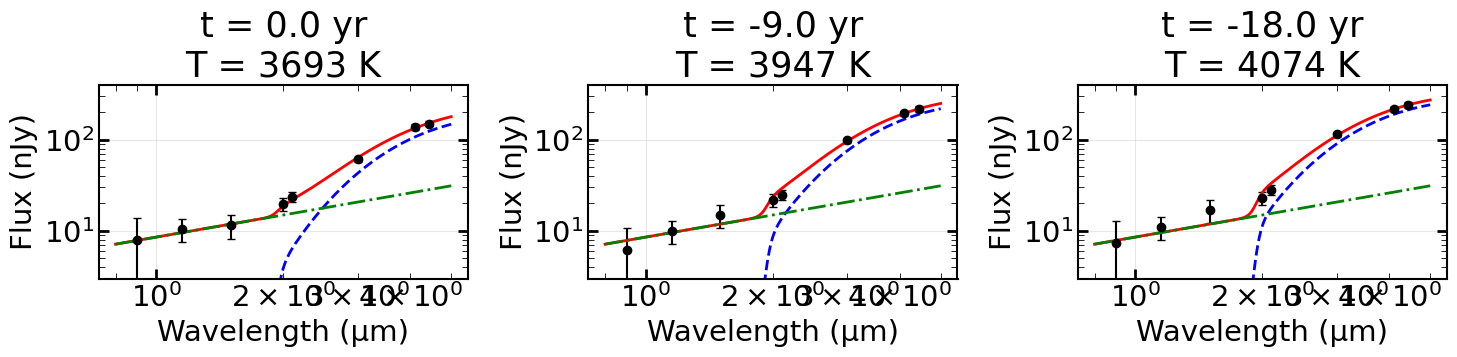

In [32]:
# 按温度排序
idx_sorted = np.argsort(temps_time)

idx_lowT  = idx_sorted[0]
idx_midT  = idx_sorted[len(idx_sorted)//2]
idx_highT = idx_sorted[-1]

selected_idx = [idx_lowT, idx_midT, idx_highT]

fig, axes = plt.subplots(1, len(selected_idx), figsize=(5*len(selected_idx), 4))

if len(selected_idx) == 1:
    axes = [axes]

for ax, idx in zip(axes, selected_idx):

    SED = SEDs[idx]
    wl = SED['wave']
    flux = SED['flux']
    ferr = SED['ferr']

    T = fit_results_time[idx]['T']
    norm = fit_results_time[idx]['norm']
    t_now = fit_results_time[idx]['t']

    # ---- 细网格 ----
    wl_plot = np.linspace(0.8, 5.0, 300)

    # ---- 各个成分 ----
    flux_bb = blackbody_Fnu(wl_plot, T, norm, z=redshift)
    flux_pl = A_PL_fixed * (wl_plot / blue_cut) ** alpha_fixed
    flux_tot = flux_bb + flux_pl

    # ---- 数据点 ----
    ax.errorbar(wl, flux, yerr=ferr, fmt='o', color='k', capsize=3)

    # ---- 曲线 ----
    ax.plot(wl_plot, flux_tot, 'r-', lw=2, label='Total')
    ax.plot(wl_plot, flux_bb, 'b--', lw=2, label='Blackbody')
    ax.plot(wl_plot, flux_pl, 'g-.', lw=2, label='Power-law')

    # ---- 标注 ----
    ax.set_title(f"t = {t_now:.1f} yr\nT = {T:.0f} K")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Wavelength (µm)")
    ax.set_ylabel("Flux (nJy)")
    ax.grid(alpha=0.3)
    ax.set_ylim(3, 4e2)

# axes[0].legend()
plt.tight_layout()
plt.show()

1.1: T=3756 ± 110 K, norm=44.46
1.2: T=3541 ± 164 K, norm=44.22
1.3: T=3888 ± 132 K, norm=44.37
1.4: T=3805 ± 132 K, norm=44.33
共用 power-law 振幅: A_PL = 8.632, 指数 alpha = 0.801, A_V = 0.00


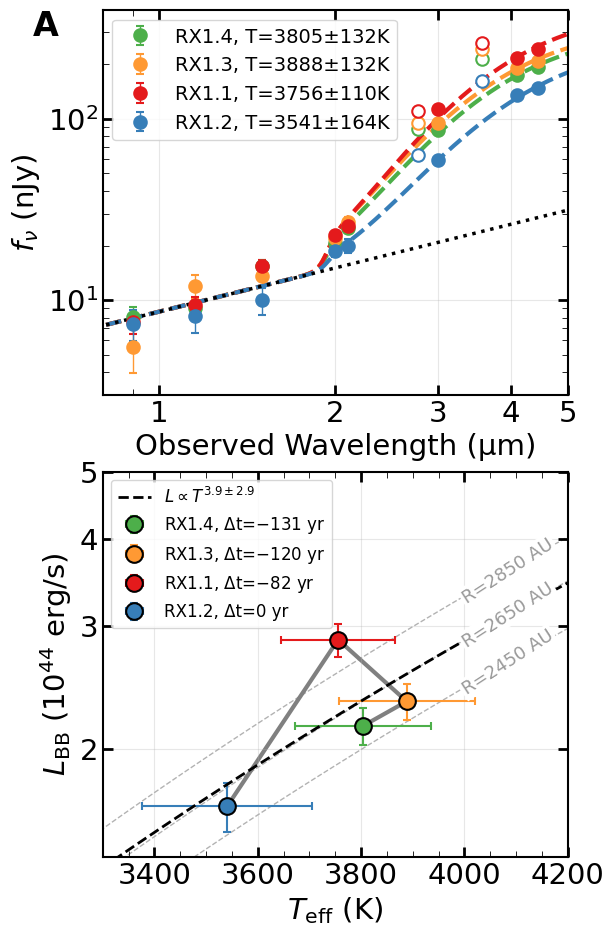

In [49]:
import extinction

# colors = ['green','orange', 'red','blue'  ]
colors = ['#4DAF4A',   # 柔和自然绿
          '#FF9933',   # 明亮但不刺眼的橙
          '#E41A1C',   # Nature 常用红
          '#377EB8']   # 常用冷色蓝
blue_cut = 1.0     # µm，仅用于标记蓝端
redshift = 4.3
AV_adopted = 0.
# ===== 联合模型函数 =====
def joint_model_allbands(wavelengths_all, *params):
    """
    wavelengths_all: list of 4 arrays, 每个像的波长
    params: [T1,norm1, T2,norm2, T3,norm3, T4,norm4, A_PL, alpha, A_V]
    返回拼接后的 flux (已考虑统一的尘埃吸收)
    """
    flux_model_all = []
    # A_PL = params[-3]   # 共用 power-law 振幅
    # alpha = params[-2]  # 共用 power-law 指数
    # A_V = params[-1]    # 统一的消光参数
    A_PL = params[-2]   # 共用 power-law 振幅
    alpha = params[-1]  # 共用 power-law 指数
    A_V = AV_adopted

    for i, wl in enumerate(wavelengths_all):
        # wl 单位 µm → 转为 Å 供 extinction 使用
        wl_AA = wl * 1e4

        T = params[2*i]
        norm = params[2*i+1]

        # 本征黑体 + 功率律
        flux_bb = blackbody_Fnu(wl, T, norm, z=redshift)
        A_lambda = extinction.calzetti00(wl_AA/(1+redshift), A_V, r_v=4.05)
        flux_pl = A_PL * (wl/blue_cut)**alpha
        flux_int = flux_bb * 10**(-0.4 * A_lambda) + flux_pl

        # Calzetti extinction (A_lambda in mag)
        
        flux_obs = flux_int
        flux_model_all.append(flux_obs)

    return np.concatenate(flux_model_all)
# ===== 准备数据 =====
#1.3 与 1.4是相反的！
wavelengths_all = [wave_jwst[2:].value for _ in range(4)]
fluxes_all = np.concatenate([jwstflux_list[i][2:].value for i in range(4)])
fluxerrs_all = np.concatenate([jwstfluxerr_list[i][2:].value for i in range(4)])

# ===== 初始猜测和边界 =====
params0 = []
for _ in range(4):
    params0 += [4700, 44.5]  # T, norm
params0 += [0.5, -0.5]  # A_PL, alpha, A_V

lower_bounds = [3500, 44]*4 + [0.0, -3.0]
upper_bounds = [6000, 50]*4 + [100.0, 1.0]  # A_V 上限可根据需要调整

# ===== 联合拟合 =====
popt, pcov = curve_fit(joint_model_allbands, wavelengths_all, fluxes_all,
                       p0=params0, sigma=fluxerrs_all,
                       bounds=(lower_bounds, upper_bounds))

# ===== 提取结果 =====
fit_results = {}
# A_PL, alpha = popt[-2], popt[-1]
# print(f"共用 power-law 振幅: A_PL = {A_PL:.3f}, 指数 alpha = {alpha:.3f}")
for i in range(4):
    T = popt[2*i]
    norm = popt[2*i+1]
    T_err = np.sqrt(pcov[2*i, 2*i])
    norm_err = np.sqrt(pcov[2*i+1, 2*i+1])
    td = lens_dict[f'9.{i+1}']["dt"][0]
    fit_results[f'1.{i+1}'] = {'temperature': T, 'temperature_err': T_err, 'norm': norm, 'norm_err': norm_err, 'td': td}
    print(f'1.{i+1}: T={T:.0f} ± {T_err:.0f} K, norm={norm:.2f}')
# A_PL, alpha, A_V = popt[-3], popt[-2], popt[-1]
A_PL, alpha, A_V = popt[-2], popt[-1], AV_adopted
print(f"共用 power-law 振幅: A_PL = {A_PL:.3f}, 指数 alpha = {alpha:.3f}, A_V = {A_V:.2f}")

# ===== 绘图 =====
# fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12.5,5))
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 11))

fit_wave = np.linspace(0.3,5.0,300)
# --- 左图: SED + 拟合 + power-law ---
cori = 0

for i in np.array([4,3,1,2]) - 1:
    wl = wave_jwst.value
    flux = jwstflux_list[i].value
    fluxerr = jwstfluxerr_list[i].value
    T = fit_results[f'1.{i+1}']['temperature']
    T_err = fit_results[f'1.{i+1}']['temperature_err']
    norm = fit_results[f'1.{i+1}']['norm']
    norm_err = fit_results[f'1.{i+1}']['norm_err']
    color = colors[cori]
    cori +=1

    # flux_bb = blackbody_Fnu(fit_wave, T, norm, z = redshift)
    # flux_pl = A_PL * (fit_wave/blue_cut)**alpha
    # fit_flux = flux_bb + flux_pl
    A_lambda = extinction.calzetti00(fit_wave/(1+redshift) * 1e4, A_V, r_v=4.05)
    flux_bb = blackbody_Fnu(fit_wave, T, norm, z=redshift)
    flux_pl = A_PL * (fit_wave/blue_cut)**alpha
    flux_int = flux_bb * 10**(-0.4 * A_lambda) + flux_pl
    # flux_int = flux_bb + flux_pl

    # 加入消光（Calzetti曲线）
   
    fit_flux = flux_int 

    cutoff = -8
    ax1.errorbar(wl[:cutoff], flux[:cutoff], yerr=fluxerr[:cutoff],
                 fmt='o', ms=9, color=color, mfc='white', mew=1.5,
                 elinewidth=1, capsize=3)
    ax1.errorbar(wl[cutoff:], flux[cutoff:], yerr=fluxerr[cutoff:],
                 fmt='o', ms=9, color=color, mew=1.5,
                 elinewidth=1, capsize=3,
                 label=f'RX1.{i+1}, T={T:.0f}±{T_err:.0f}K')

    # 总SED曲线（黑体+powerlaw）
    ax1.plot(fit_wave, fit_flux, '--', color=color, alpha=1.0, lw=3)
    # power-law单独虚线（可选）

ax1.plot(fit_wave, flux_pl, ':', color='k', alpha=1, lw=2.5)

# 左图设置
ax1.set_xlabel("Observed Wavelength (µm)")
ax1.set_ylabel(r"$f_{\nu}$ (nJy)")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(0.8, 5)
ax1.set_ylim(3, 4e2)
ax1.grid(True, alpha=0.3)
x_ticks = [ 1, 2, 3, 4,5]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(int(tick)) if tick < 10 else f"{int(tick)}" for tick in x_ticks])
ax1.legend(fontsize=14)

# --- 右图: T vs Lbol ---
sorted_items = sorted(fit_results.items(), key=lambda x: -x[1]['td'])
names = [k for k,_ in sorted_items]
temps = np.array([v['temperature'] for _,v in sorted_items])
temp_errs = np.array([v['temperature_err'] for _,v in sorted_items])
logs_Lbol = np.array([v['norm'] for _,v in sorted_items])
logs_Lbol_errs = np.array([v['norm_err'] for _,v in sorted_items])
tds = np.array([v['td'] for _,v in sorted_items])

# 转换为线性 L 及误差
L = 10**logs_Lbol
L_err = np.log(10) * L * logs_Lbol_errs

for i, (Lval, Lerr, T, Terr, td, name) in enumerate(zip(L, L_err, temps, temp_errs, tds, names)):
    color = colors[i]
    if i!=3:
        sign = r'$-$' 
    else:
        sign = ''
    ax2.errorbar( T, Lval/1e44,
                 xerr=Terr, yerr=Lerr/1e44,
                 fmt='o', color=color, markeredgecolor='black', # 黑色边框
                 ms=12, mew=1.5, capsize=3,
                 label=f'RX{name}, Δt=' + sign + f'{td/365:.0f} yr')
# 指定连线顺序
order = [3, 2, 1, 0]  # Python索引，从0开始
L_ordered = np.array(10**logs_Lbol)[order] / 1e44
T_ordered = np.array(temps)[order]

# 连线
ax2.plot( T_ordered, L_ordered, '-', color='gray', lw=3, zorder=-1)  # zorder=-1 放在点的下方
# log-log 拟合
slope, intercept, r_value, p_value, stderr = linregress(np.log10(temps), logs_Lbol)
t_fit = np.linspace(3000,4550,100) - 200
L_fit = 10**intercept * t_fit**slope
ax2.plot( t_fit, L_fit/1e44, 'k--', lw=2, label=r'$L \propto T^{%.1f \pm %.1f}$' % (slope, stderr))

# 理论半径

sigma = const.sigma_sb.cgs.value
for R_AU in np.array([ 2050, 2250, 2450])+400:
    R_cm = (R_AU * u.AU).to(u.cm).value
    L_theory = 4 * np.pi * sigma * R_cm**2 * t_fit**4  # erg/s
    ax2.plot( t_fit, L_theory/1e44, '--', color='gray', lw=1.0, alpha=0.6, zorder=0)

    # 获取线的中间位置
    mid = len(t_fit) // 5 * 4 + 2
    x_mid = L_theory[mid]
    y_mid = t_fit[mid]

    # 沿着线的斜率旋转文字
    dx = np.log10(L_theory[mid+1]) - np.log10(L_theory[mid-1])
    dy = t_fit[mid+1] - t_fit[mid-1]
    angle = 33#np.degrees(np.arctan2(dy, dx * np.log(10)))
    
    ax2.text(
    y_mid, x_mid/1e44,  f"R={R_AU} AU",
    color='gray', fontsize=13, alpha=0.8,
    rotation=angle, rotation_mode='anchor',
    ha='center', va='center',
    bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=1.5)
)


# --- L–T 图 ---
# temps_time = np.array([r['T'] for r in fit_results_time]) - 180
# tds = np.array([r['t'] for r in fit_results_time])
# logs_Lbol_time = np.array([r['norm'] for r in fit_results_time]) 
# ax2.scatter(temps_time, 10 ** logs_Lbol_time / 1e44 + 0.1, c=tds, cmap='plasma', s=60, alpha = 0.7, zorder=-2)

# # # 连线 + 拟合
# slope, intercept, r_value, _, _ = linregress(np.log10(temps_time), logs_Lbol_time)
# t_fit = np.linspace(4000, 4800, 100)
# L_fit = 10 ** intercept * t_fit ** slope
# ax2.plot(L_fit / 1e44, t_fit, 'k--', lw=2, label=r"$L \propto T^{%.1f}$" % slope)

# 转换为线性 L 及误差
L = 10**logs_Lbol
L_err = np.log(10) * L * logs_Lbol_errs

sigma = const.sigma_sb.cgs.value

deltax = 0.5
deltay = 400
# ax2.annotate(
#     '', xy=( 4250- deltay, 2.4 - deltax), xytext=(4050- deltay, 2.0- deltax),
#     arrowprops=dict(
#         arrowstyle='->',
#         lw=3.5,                # 线宽
#         color='#D95F02',
#         shrinkA=0, shrinkB=0,
#         mutation_scale=21      # 控制箭头大小
#     ),
#     zorder=5
# )

# # 第二个箭头：反方向，y轴低200
# ax2.annotate(
#     '', xy=(3850- deltay, 2.6- deltax), xytext=(4080- deltay, 3.2- deltax),
#     arrowprops=dict(
#         arrowstyle='->',
#         lw=3.5,
#         color='#D95F02',
#         shrinkA=0, shrinkB=0,
#         mutation_scale=21
#     ),
#     zorder=5
# )

ax2.set_yscale('log')
ax2.set_ylabel(r"$L_{\rm BB}~ (10^{44}$ erg/s)")
ax2.set_xlabel(r"$T_{\rm eff}$ (K)")
ax2.set_ylim(1.4,4.5)
ax2.set_xlim(3300,4200)
ax2.grid(True, alpha=0.3)
x_ticks = [2,3,4,5]#,6,7
ax2.set_yticks(x_ticks)
ax2.set_yticklabels([str(t) for t in x_ticks])
ax2.legend(fontsize=12., loc='upper left', ncols =1)

import matplotlib.colors as colors
cephieds_L, cephieds_T = np.loadtxt('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/Cepheids_L_T/L_T_CEP-4313.txt').T
cephieds_L = cephieds_L * 2.
cephieds_T = cephieds_T  / 1.46
tcephieds_ = np.linspace(-40, 3, len(cephieds_T))
cutindex = 16
tcephieds = np.concatenate([tcephieds_[cutindex:], tcephieds_[:cutindex]])
tcephieds = np.array(tcephieds)
points = np.array([cephieds_T, cephieds_L]).T
segments = np.stack([points[:-1], points[1:]], axis=1)
# colormap 映射
# norm = colors.Normalize(vmin=tcephieds.min(), vmax=tcephieds.max())
# lc = LineCollection(segments, cmap='plasma', norm=norm)
# # 为每个 segment 指定颜色
# lc.set_array(tcephieds[:-1])
# lc.set_linewidth(3.0)
# ax2.add_collection(lc)
# ax2.text( 0.6,0.11, f'A Cepheid (scaled)', color='k', fontsize=14, transform=ax2.transAxes, ha='left', va='top')
# # 指向曲线的线段 (使用 annotate)
# ax2.annotate(
#     '', 
#     xy=(cephieds_T[0] + 0.05, cephieds_L[0] - 0.05),        # ← 曲线上的目标点（可改）
#     xytext=( 0.85, 0.1),                        # ← 文字右侧一点
#     textcoords=ax2.transAxes,
#     arrowprops=dict(arrowstyle='->', lw=1, color='k')
# )

ax1.text(-0.15, 1., f'A', color='k', fontsize=24, transform=ax1.transAxes, ha='left', va='top', weight='bold')
# ax2.text(-0.15, 1., f'B', color='k', fontsize=24, transform=ax2.transAxes, ha='left', va='top', weight='bold')
from matplotlib.ticker import FuncFormatter
def k_formatter(x, pos):
    return f"{x/1000:.1f}"
# ax2.yaxis.set_major_formatter(FuncFormatter(k_formatter))

# plt.subplots_adjust(
#     top=0.95,    # 上边距（默认 0.88）
#     bottom=0.12, # 下边距（默认 0.11）
# )
# plt.tight_layout()

plt.subplots_adjust(wspace=0.21)   # 越小越近，常用范围 0.05–0.20
# plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'RX1_BBfit1.pdf', dpi=200, bbox_inches='tight')
# plt.show()

In [400]:
Lval/1e44

1.7553973431191445

In [86]:
# --- Bootstrap ---
n_boot = 100000
rng = np.random.default_rng()

# 对每个数据点按其误差进行随机采样（假设误差为高斯分布）
L_samples = rng.normal(loc=L, scale=L_err, size=(n_boot, len(L)))

# 计算每次采样的 median
medians = np.median(L_samples, axis=1)

# 取最终 median 和 1σ 置信区间（非对称）
median_L = np.median(medians)
low1, high1 = np.percentile(medians, [16, 84])

err_low = median_L - low1
err_high = high1 - median_L

print(f"Median L = {median_L:.3e}")
print(f"Median error = -{err_low:.3e}  +{err_high:.3e}")

Median L = 2.240e+44
Median error = -9.039e+42  +9.093e+42


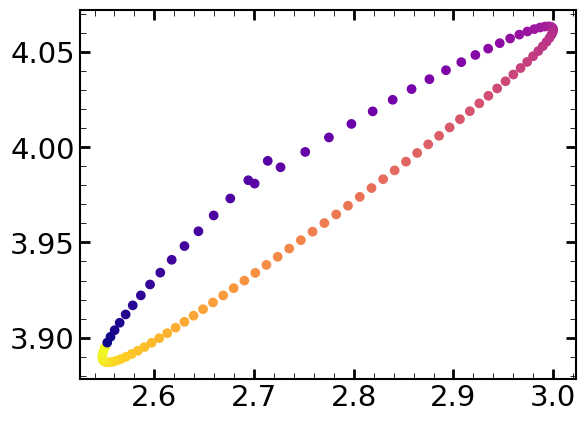

In [42]:
cephieds_L, cephieds_T = np.loadtxt('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/Cepheids_L_T/L_T_CEP-4313.txt').T
cephieds_L = cephieds_L * 3
cephieds_T = cephieds_T / 1000 / 1.5
tcephieds_ = np.linspace(-40, 3, len(cephieds_T))
cutindex = 16
tcephieds = np.concatenate([tcephieds_[cutindex:], tcephieds_[:cutindex]])
plt.scatter(cephieds_L, cephieds_T, c=tcephieds, cmap='plasma')
# plt.scatter(10 ** logs_Lbol_time / 1e44, temps_time, c=tds, cmap='plasma', s=60, alpha = 0.7, zorder=-2)

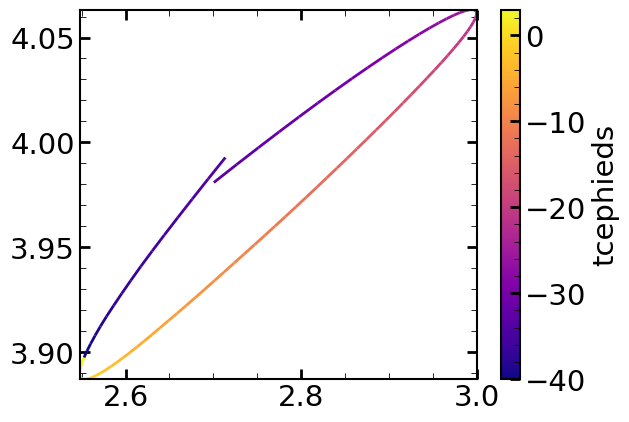

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
import matplotlib.colors as colors

# 假设 cephieds_L, cephieds_T, tcephieds 已经准备好

# 构造线段：(N-1) 段，每段由两个点构成
points = np.array([cephieds_L, cephieds_T]).T
segments = np.stack([points[:-1], points[1:]], axis=1)

# colormap 映射
norm = colors.Normalize(vmin=tcephieds.min(), vmax=tcephieds.max())
lc = LineCollection(segments, cmap='plasma', norm=norm)

# 为每个 segment 指定颜色
lc.set_array(tcephieds[:-1])
lc.set_linewidth(2.0)

fig, ax = plt.subplots()
ax.add_collection(lc)

# 调整坐标范围
ax.set_xlim(cephieds_L.min(), cephieds_L.max())
ax.set_ylim(cephieds_T.min(), cephieds_T.max())

cbar = plt.colorbar(lc, ax=ax)
cbar.set_label('tcephieds')

plt.show()

In [110]:
tcephieds_[:10]

array([-40.        , -39.56565657, -39.13131313, -38.6969697 ,
       -38.26262626, -37.82828283, -37.39393939, -36.95959596,
       -36.52525253, -36.09090909])

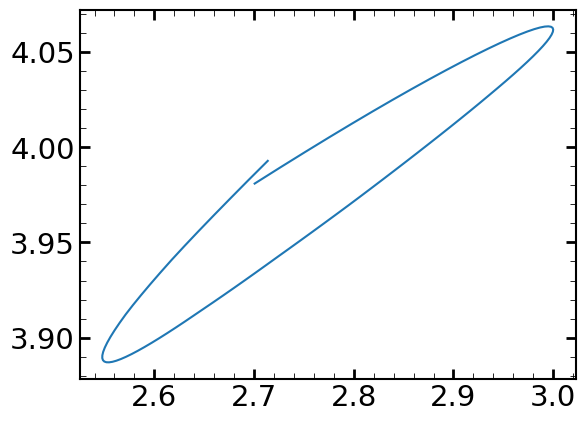

In [105]:
cephieds_L, cephieds_T = np.loadtxt('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/Cepheids_L_T/L_T_CEP-4313.txt').T
cephieds_L = cephieds_L * 3
cephieds_T = cephieds_T / 1000 / 1.5
plt.plot(cephieds_L, cephieds_T)

In [106]:
L_fit / 1e44, t_fit

(array([0.65565299, 0.67076656, 0.68614181, 0.70178178, 0.71768953,
        0.73386815, 0.75032073, 0.76705039, 0.78406028, 0.80135354,
        0.81893336, 0.83680293, 0.85496545, 0.87342416, 0.89218231,
        0.91124316, 0.93061   , 0.95028613, 0.97027488, 0.99057958,
        1.01120359, 1.0321503 , 1.05342309, 1.07502539, 1.09696062,
        1.11923224, 1.14184372, 1.16479855, 1.18810024, 1.2117523 ,
        1.23575829, 1.26012177, 1.28484632, 1.30993554, 1.33539305,
        1.36122249, 1.38742751, 1.4140118 , 1.44097903, 1.46833293,
        1.49607723, 1.52421567, 1.55275203, 1.58169009, 1.61103365,
        1.64078655, 1.67095262, 1.70153572, 1.73253974, 1.76396858,
        1.79582614, 1.82811638, 1.86084324, 1.8940107 , 1.92762275,
        1.96168341, 1.9961967 , 2.03116667, 2.06659739, 2.10249295,
        2.13885746, 2.17569503, 2.21300981, 2.25080597, 2.28908767,
        2.32785913, 2.36712457, 2.40688821, 2.44715432, 2.48792717,
        2.52921105, 2.57101028, 2.61332918, 2.65

In [2]:
fit_results_time

NameError: name 'fit_results_time' is not defined